# Trabajo Fin de Máster: Estimación de Irradiancia Solar

## Comparativa de Modelos Físicos, Machine Learning y Estrategias Híbridas
Este notebook recoge el desarrollo práctico y experimental del Trabajo Fin de Máster centrado en la estimación de la Irradiación Directa Normal (DNI) y la Irradiación Difusa Horizontal (DHI). Se utilizan datos meteorológicos de diversas ubicaciones europeas proporcionados por el National Solar Radiation Database (NSRDB), seleccionando emplazamientos con características climáticas opuestas (ej. Almería vs. Galway) para evaluar la robustez y capacidad de generalización de los modelos.

### Objetivos y Metodología

El estudio sigue un enfoque incremental para superar las limitaciones de las fórmulas tradicionales:

1. **Línea Base (Modelos Físicos):** Se implementan y evalúan modelos empíricos clásicos (Erbs, Perez, etc.) para establecer un punto de referencia.

2. **Machine Learning Supervisado:** Se entrenan y optimizan diversos algoritmos (Random Forest, Gradient Boosting, SVR, MLP, KNN) buscando capturar las relaciones no lineales de la atmósfera.

3. **Estrategias Avanzadas:** Se desarrollan técnicas de Ensemble (Voting) y una arquitectura Híbrida de Dos Etapas (Clasificación de Nubes + Regresión) diseñada específicamente para corregir el error en días nublados, siguiendo las recomendaciones de la dirección académica.

A continuación, se detalla la estructura del flujo de trabajo implementado:

### Índice del Proyecto

1. **Configuración del Entorno:** Importación centralizada de librerías y configuración de estilos gráficos.

2. **Ingeniería de Datos:** Carga, limpieza de datos nocturnos y cálculo de variables físicas clave (como el Índice de Claridad, Kt).

3. **Análisis Exploratorio de Datos (EDA):** Estudio de correlaciones físicas, perfiles climáticos comparativos y análisis de la relación Kt vs. DNI.

4. **Implementación de Modelos Físicos:** Definición matemática, cálculo y diagnóstico visual individual de modelos clásicos (Erbs, Perez, etc.).

5. **Desarrollo Experimental de Modelos de Machine Learning:** Preparación de datos (división estratégica y escalado), entrenamiento optimizado y diagnóstico visual de algoritmos de regresión.
6. **Estrategias Avanzadas:** Implementación de Voting Regressor y del Modelo Híbrido (Clasificador + Regresor).

7. **Evaluación Comparativa Final:** Ranking definitivo de modelos, tablas de error (RMSE/MAE) y conclusiones finales del estudio.

## 1. Configuración del Entorno

In [1]:
# Importación de librerías y configuraciones

# Manejo de datos
import pandas as pd
import numpy as np
import io
from io import StringIO
from google.colab import files # Solo para Colab

# Visualización
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import time

# Configuración visual para todo el notebook
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore') # Limpia alertas de versiones

# Preprocesamiento y Selección
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV

# Métricas de Evaluación
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score

# Modelos de Regresión (Físicos, Lineales y ML)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor

# Modelos de Clasificación (Para el Híbrido)
from sklearn.ensemble import RandomForestClassifier

## 2. Ingeniería de Datos

### Carga de Datasets

In [2]:
# Ejecutar esta celda y seleccionar los archivos CSV.
uploaded = files.upload()

# Definir un mapeo de nombres de archivo parciales a nombres de ciudad completos
city_filename_map = {
    "Almer": "Almería",
    "Galway": "Galway",
    "Grenoble": "Grenoble",
    "Mil": "Milán",
    "Viena": "Viena",
    "Tenerife": "Santa Cruz de Tenerife"
}

# Asociación inteligente de archivos subidos a ciudades usando los fragmentos del nombre
selected_files = {}
if 'uploaded' in locals():
    print("\nNombres de archivos subidos (exactos):", uploaded.keys())

    # Iteramos sobre los nombres parciales esperados en nuestro mapa de ciudades.
    for partial_name_key, full_city_name in city_filename_map.items():
        found = False
        # Para cada nombre parcial esperado, buscamos si algún archivo subido lo contiene.
        for uploaded_filename in uploaded.keys():
            # Realizamos la comparación en minúsculas para que sea insensible a mayúsculas/minúsculas.
            if partial_name_key.lower() in uploaded_filename.lower():
                selected_files[full_city_name] = uploaded_filename
                found = True
                break

        # Si un nombre de ciudad en nuestro mapa no encontró un archivo subido.
        if not found and full_city_name not in selected_files:
            print(f"Advertencia: No se encontró ningún archivo subido para la ciudad '{full_city_name}' (buscando '{partial_name_key}').")
else:
    print("Advertencia: 'files.upload()' debe ejecutarse para proporcionar el diccionario 'uploaded'.")
    print("Por favor, asegúrate de que los archivos se carguen en la sesión actual de Colab.")

if not selected_files:
    print("No se encontraron archivos de ciudad válidos. Asegúrate de que los nombres de archivo contengan los fragmentos esperados y que los archivos se hayan cargado.")
else:
    # Lista para almacenar los DataFrames individuales de cada ciudad
    dfs = []

    # Iterar sobre los archivos seleccionados para cargar, limpiar y preprocesar
    for city, filename in selected_files.items():
        print(f"Cargando {filename} para {city}...")
        content = uploaded[filename].decode('utf-8')

        # Se saltan las primeras 2 filas que contienen metadatos duplicados o irrelevantes
        # para el DataFrame principal de datos temporales.
        df_city = pd.read_csv(StringIO(content), skiprows=2)
        df_city["Ciudad"] = city

        # Crear una columna 'datetime' combinando las columnas de fecha y hora.
        # Esto es crucial para el análisis de series temporales.
        df_city["datetime"] = pd.to_datetime(df_city[['Year', 'Month', 'Day', 'Hour', 'Minute']])
        dfs.append(df_city)

    # Unir todos los DataFrames individuales en uno solo (df_total).
    df_total = pd.concat(dfs, ignore_index=True)

    # Mostrar las primeras 5 filas del DataFrame combinado (df_total) con las columnas clave para una verificación inicial.
    print("\nPrimeras 5 filas del DataFrame combinado (df_total) con columnas clave:")
    print(df_total[["datetime", "Ciudad", "GHI", "DHI", "DNI", "Temperature", "Relative Humidity"]].head())

    # Mostrar todas las columnas disponibles en df_total para un entendimiento completo del dataset.
    print("\nTodas las columnas disponibles en df_total:")
    print(df_total.columns.tolist())

Saving Almería, España.csv to Almería, España.csv
Saving Galway, Irlanda.csv to Galway, Irlanda.csv
Saving Grenoble, Francia.csv to Grenoble, Francia.csv
Saving Milán, Italia.csv to Milán, Italia.csv
Saving Santa Cruz de Tenerife, España.csv to Santa Cruz de Tenerife, España.csv
Saving Viena, Austria.csv to Viena, Austria.csv

Nombres de archivos subidos (exactos): dict_keys(['Almería, España.csv', 'Galway, Irlanda.csv', 'Grenoble, Francia.csv', 'Milán, Italia.csv', 'Santa Cruz de Tenerife, España.csv', 'Viena, Austria.csv'])
Cargando Almería, España.csv para Almería...
Cargando Galway, Irlanda.csv para Galway...
Cargando Grenoble, Francia.csv para Grenoble...
Cargando Milán, Italia.csv para Milán...
Cargando Viena, Austria.csv para Viena...
Cargando Santa Cruz de Tenerife, España.csv para Santa Cruz de Tenerife...

Primeras 5 filas del DataFrame combinado (df_total) con columnas clave:
             datetime   Ciudad  GHI  DHI  DNI  Temperature  Relative Humidity
0 2019

### Preprocesamiento y Calidad de Datos

En esta sección, se realizarán las tareas de preprocesamiento esenciales para preparar el dataset para el análisis. Esto incluye la gestión del formato de la columna de tiempo, el filtrado de datos no relevantes (como los periodos nocturnos), el manejo de valores faltantes y la creación de nuevas características que aportan valor al análisis.

In [3]:
# Convertir la columna 'datetime' a formato datetime y establecerla como índice.
# Esto es esencial para operaciones de series temporales y para un manejo eficiente de los datos por fecha/hora.
df_total['datetime'] = pd.to_datetime(df_total['datetime'])
df_total = df_total.set_index('datetime')

# Filtrar registros donde 'Clearsky GHI' (Global Horizontal Irradiance bajo cielo despejado) sea 0 o menos.
# Esto elimina los periodos nocturnos o sin radiación solar relevante, ya que el objetivo es estimar la irradiancia diurna.
# Se usa .copy() para crear una copia explícita y evitar el 'SettingWithCopyWarning' en operaciones futuras.
df = df_total[df_total['Clearsky GHI'] > 0].copy()

In [4]:
# Verificación y Manejo de Valores Faltantes
print("\nValores faltantes por columna en df_total (dataset original completo antes de filtrar por luz diurna):")
print(df_total.isnull().sum())

print("\nValores faltantes por columna en df (dataset filtrado para el análisis, antes de imputación de Ozone):")
print(df.isnull().sum())


Valores faltantes por columna en df_total (dataset original completo antes de filtrar por luz diurna):
Year                        0
Month                       0
Day                         0
Hour                        0
Minute                      0
Temperature                 0
Alpha                       0
Aerosol Optical Depth       0
Asymmetry                   0
Clearsky DHI                0
Clearsky DNI                0
Clearsky GHI                0
Cloud Type                  0
Dew Point                   0
DHI                         0
DNI                         0
Fill Flag                   0
GHI                         0
Ozone                    8760
Relative Humidity           0
Solar Zenith Angle          0
Surface Albedo              0
Pressure                    0
Precipitable Water          0
Wind Direction              0
Wind Speed                  0
Ciudad                      0
dtype: int64

Valores faltantes por columna en df (dataset filtrado para el análisis, 

In [5]:
# Manejo específico para la columna 'Ozone':
# Si bien el filtro inicial redujo los nulos en 'Ozone', todavía quedan algunos.
# Para datos de series temporales como los meteorológicos, la interpolación es un método adecuado
# para rellenar valores faltantes, asumiendo una variación suave entre puntos de datos conocidos.
if 'Ozone' in df.columns and df['Ozone'].isnull().any():
    print("\nImputando valores faltantes en la columna 'Ozone' usando interpolación temporal...")
    # 'method='time'' es ideal para índices de tiempo, interpolando valores basados en el índice de tiempo.
    df['Ozone'] = df['Ozone'].interpolate(method='time')
    # Si después de interpolate aún quedan nulos (ej. al inicio o final de la serie),
    # se rellenan hacia adelante y luego hacia atrás.
    # Nota: FutureWarning sobre Series.fillna con 'method' es una advertencia, no un error, y el código funciona.
    df['Ozone'] = df['Ozone'].fillna(method='ffill').fillna(method='bfill')
    print("Imputación de 'Ozone' completada.")

print("\nValores faltantes finales por columna en df (después de filtrado y imputación):")
print(df.isnull().sum())


Imputando valores faltantes en la columna 'Ozone' usando interpolación temporal...
Imputación de 'Ozone' completada.

Valores faltantes finales por columna en df (después de filtrado y imputación):
Year                     0
Month                    0
Day                      0
Hour                     0
Minute                   0
Temperature              0
Alpha                    0
Aerosol Optical Depth    0
Asymmetry                0
Clearsky DHI             0
Clearsky DNI             0
Clearsky GHI             0
Cloud Type               0
Dew Point                0
DHI                      0
DNI                      0
Fill Flag                0
GHI                      0
Ozone                    0
Relative Humidity        0
Solar Zenith Angle       0
Surface Albedo           0
Pressure                 0
Precipitable Water       0
Wind Direction           0
Wind Speed               0
Ciudad                   0
dtype: int64


###Manejo de Valores Faltantes

Se realizó una verificación exhaustiva de valores nulos en el dataset (`df_total.isnull().sum()` y `df.isnull().sum()`).

* **Dataset original (`df_total`):** Se detectó la presencia de valores nulos en la columna `Ozone` (8760 registros), lo que corresponde a un año completo de datos horarios para una ubicación. Es probable que estos valores correspondan a registros nocturnos o momentos de muy baja irradiancia solar, donde la medición o la relevancia del ozono en la irradiancia es mínima.

* **Dataset para análisis (`df`):** Tras la aplicación de un filtro inicial (`df = df_total[df_total['Clearsky GHI'] > 0].copy()`) para excluir los periodos sin radiación solar (principalmente nocturnos), se observó que la columna `Ozone` aún contenía 4357 valores nulos. Para garantizar la completitud de los datos en los periodos diurnos relevantes para el modelado, se aplicó una **imputación de estos valores nulos utilizando interpolación con `method='time'`**. Este método es adecuado para series temporales, ya que rellena los valores faltantes basándose en la información temporal de los puntos de datos adyacentes, preservando así la continuidad de la serie. Los valores nulos restantes (si los hubiera, por ejemplo, al inicio o al final de la serie) se rellenaron con el último valor válido hacia adelante (`ffill`) y el primer valor válido hacia atrás (`bfill`). Esta estrategia asegura que el DataFrame final (`df`) no contenga valores nulos en ninguna de sus columnas, manteniendo la integridad de los datos para el análisis.

###Tratamiento de Valores Atípicos (*Outliers*)

En el contexto de la irradiancia solar y otras variables climatológicas, los valores atípicos (observables, por ejemplo, en los boxplots de GHI por ciudad) a menudo no son errores, sino que representan **fenómenos meteorológicos reales y significativos**. Estos pueden incluir:
* **Días excepcionalmente soleados o nublados:** Picos o valles de irradiancia que reflejan condiciones atmosféricas particulares.
* **Eventos climáticos extremos:** Olas de calor, tormentas intensas, o momentos de alta claridad atmosférica post-lluvia.

La eliminación indiscriminada de estos puntos de datos, aunque podría mejorar ciertas métricas de error promedio en el corto plazo, llevaría a **modelos que subestimen la variabilidad real** del sistema climático. Esto podría resultar en predicciones menos precisas y robustas cuando los modelos se apliquen a escenarios no promedio o extremos en la práctica.

Por lo tanto, se ha decidido **no eliminar los *outliers*** de forma automática. En su lugar, se priorizará:
1.  **Su análisis contextual:** Entender si estos valores corresponden a eventos meteorológicos conocidos o a condiciones geográficas específicas (como la alta irradiancia en Tenerife o Almería).
2.  **El uso de modelos robustos:** Se seleccionarán y ajustarán modelos de aprendizaje automático (como Random Forest o SVR) que son intrínsecamente más tolerantes a la presencia de *outliers* en los datos de entrada, ya que no se basan en suposiciones paramétricas de la distribución de los datos.

Este enfoque busca mantener la representatividad completa del sistema climático, asegurando que los modelos desarrollados sean aplicables y confiables en una amplia gama de condiciones atmosféricas, incluyendo aquellas que son menos frecuentes pero meteorológicamente relevantes.

### Creación de Features Adicionales

Para enriquecer el dataset y proporcionar a los modelos información más relevante sobre las condiciones atmosféricas y la posición solar, se calculan el Índice de Claridad (Kt) y una clasificación categórica del Tipo de Cielo.

In [6]:
# El índice de claridad (Kt) es la relación entre la irradiancia global horizontal (GHI) y la irradiancia de cielo despejado (Clearsky GHI).
# Este índice es fundamental para clasificar las condiciones atmosféricas (despejado, parcialmente nublado, nublado, etc.).
df['Kt'] = df['GHI'] / df['Clearsky GHI']

def classify_sky_type(kt_value):
    """
    Clasifica el tipo de cielo basado en el índice de claridad (Kt) según convenciones comunes en meteorología solar.
    Kt >= 0.7: Despejado
    0.3 <= Kt < 0.7: Parcialmente nublado
    Kt < 0.3: Nublado
    """
    if kt_value >= 0.7:
        return 'Despejado'
    elif kt_value >= 0.3:
        return 'Parcialmente nublado'
    else:
        return 'Nublado'

# Aplicar la función de clasificación para crear la nueva columna 'Tipo_Cielo'.
df['Tipo_Cielo'] = df['Kt'].apply(classify_sky_type)

print("Distribución de registros por Tipo de Cielo:")
print(df['Tipo_Cielo'].value_counts())

Distribución de registros por Tipo de Cielo:
Tipo_Cielo
Despejado               13686
Nublado                  6632
Parcialmente nublado     5872
Name: count, dtype: int64


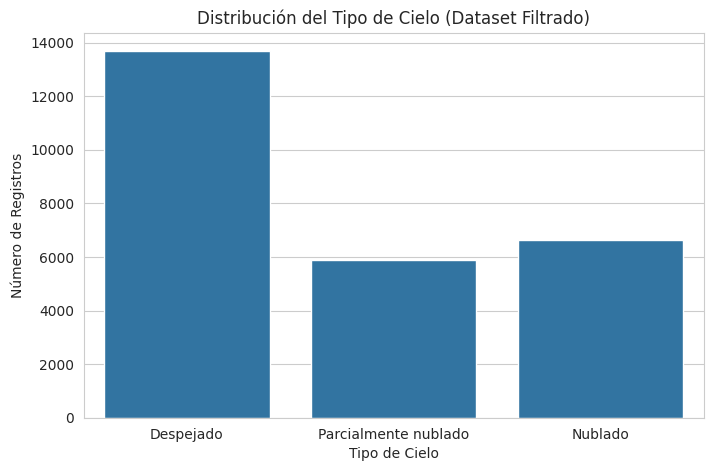

In [7]:
# Graficar la distribución de los tipos de cielo para visualizar la predominancia de cada categoría.
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Tipo_Cielo', order=['Despejado', 'Parcialmente nublado', 'Nublado'])
plt.title('Distribución del Tipo de Cielo (Dataset Filtrado)')
plt.ylabel('Número de Registros')
plt.xlabel('Tipo de Cielo')
plt.show()

## 3. Análisis Exploratorio de Datos (EDA) Detallado

A continuación, se presentan visualizaciones clave para entender la evolución y distribución de las variables de irradiancia en las diferentes ciudades.

### 3.1. Evolución Diaria de la Irradiancia Global Horizontal (GHI)

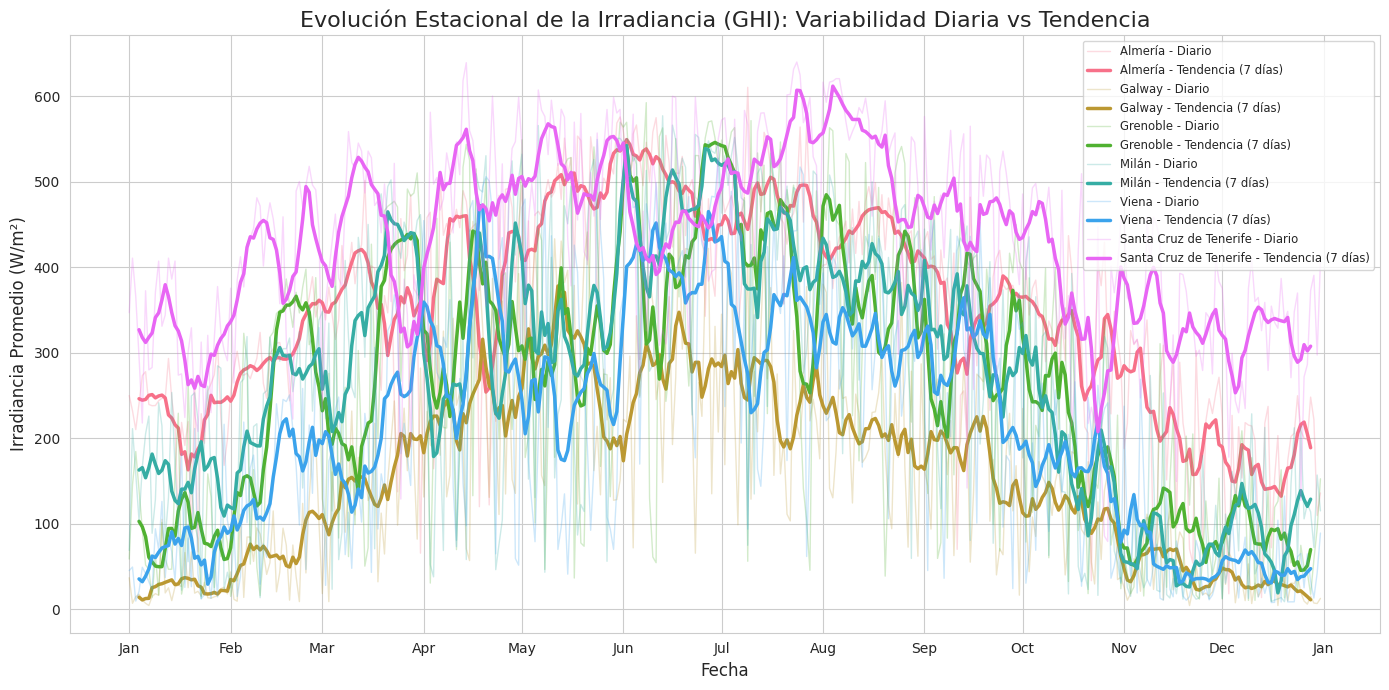

In [8]:
# Crear copia para EDA
df_eda_daily = df.copy()

# Asegurar índice datetime
if not isinstance(df_eda_daily.index, pd.DatetimeIndex):
    df_eda_daily['datetime'] = pd.to_datetime(df_eda_daily.index)
    df_eda_daily = df_eda_daily.set_index('datetime')

# Calcular medias diarias por ciudad
daily_means_all_cities = df_eda_daily.groupby([df_eda_daily.index.date, 'Ciudad'])[['GHI']].mean().reset_index()

# Renombrar columna de fecha para claridad
daily_means_all_cities = daily_means_all_cities.rename(columns={daily_means_all_cities.columns[0]: 'Fecha'})
daily_means_all_cities['Fecha'] = pd.to_datetime(daily_means_all_cities['Fecha'])


# Visualización
sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))
palette = sns.color_palette("husl", len(df_eda_daily['Ciudad'].unique()))

for i, city in enumerate(df_eda_daily['Ciudad'].unique()):
    subset = daily_means_all_cities[daily_means_all_cities['Ciudad'] == city].sort_values('Fecha')

    # 1. Datos crudos (Diarios) con transparencia para ver la variabilidad real
    plt.plot(subset['Fecha'], subset['GHI'], label=f'{city} - Diario',
             color=palette[i], alpha=0.25, linewidth=1)

    # 2. Media Móvil (Tendencia) - Esto es lo que añade valor analítico
    # Usamos ventana de 7 días para ver la tendencia semanal
    subset['GHI_Rolling'] = subset['GHI'].rolling(window=7, center=True).mean()
    plt.plot(subset['Fecha'], subset['GHI_Rolling'], label=f'{city} - Tendencia (7 días)',
             color=palette[i], linewidth=2.5)

# Decoración del gráfico
plt.title('Evolución Estacional de la Irradiancia (GHI): Variabilidad Diaria vs Tendencia', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Irradiancia Promedio (W/m²)', fontsize=12)

# Formato limpio de fechas en eje X
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.legend(loc='upper right', frameon=True, fontsize='small')
plt.tight_layout()
plt.show()

### Interpretación de la Evolución Diaria y Estrategia de Modelado

El análisis visual, potenciado por la descomposición entre tendencia (media móvil semanal) y variabilidad diaria (datos brutos), revela patrones cruciales para la experimentación:

Ciclo Solar y Estacionalidad: Se confirma la estacionalidad marcada en todas las ubicaciones, con un pico de irradiancia en julio. Sin embargo, la media  permite identificar el fenómeno de "atenuación por nubosidad": la distancia vertical entre la envolvente superior de los datos (el máximo teórico o Clear Sky) y la línea de tendencia (promedio real).

Análisis Geográfico Comparativo:

Alta Estabilidad (Tenerife y Almería): Muestran una "brecha de nubosidad" mínima; la línea de tendencia se adhiere casi perfectamente al límite superior teórico, indicando cielos predominantemente despejados y una curva suave. Esto valida a estas ciudades como candidatas ideales para el conjunto de entrenamiento, ya que permiten a los modelos aprender el comportamiento físico de la radiación sin el "ruido" excesivo de las nubes.

Alta Variabilidad (Galway): Exhibe una curva sumamente irregular con una gran dispersión vertical, especialmente en los meses de transición. La gran distancia entre su potencial teórico y su realidad promedio evidencia una meteorología adversa y cambiante.

Casos Intermedios (Viena, Grenoble, Milán): Presentan fluctuaciones moderadas influenciadas por factores locales (orografía alpina o contaminación urbana).

Justificación Metodológica: Estas observaciones refuerzan la hipótesis central del trabajo: el rendimiento de los modelos dependerá drásticamente del entorno climático. Por ello, la estrategia experimental consistirá en entrenar los modelos de ML en entornos de alta estabilidad (Tenerife/Almería) para capturar las relaciones físicas fundamentales, y posteriormente evaluar su capacidad de generalización (extrapolación) en entornos de alta entropía (como Galway), donde los modelos físicos tradicionales suelen tener dificultades para adaptarse sin calibración local.

### 3.2. Distribución de GHI por Ciudad (Boxplots)

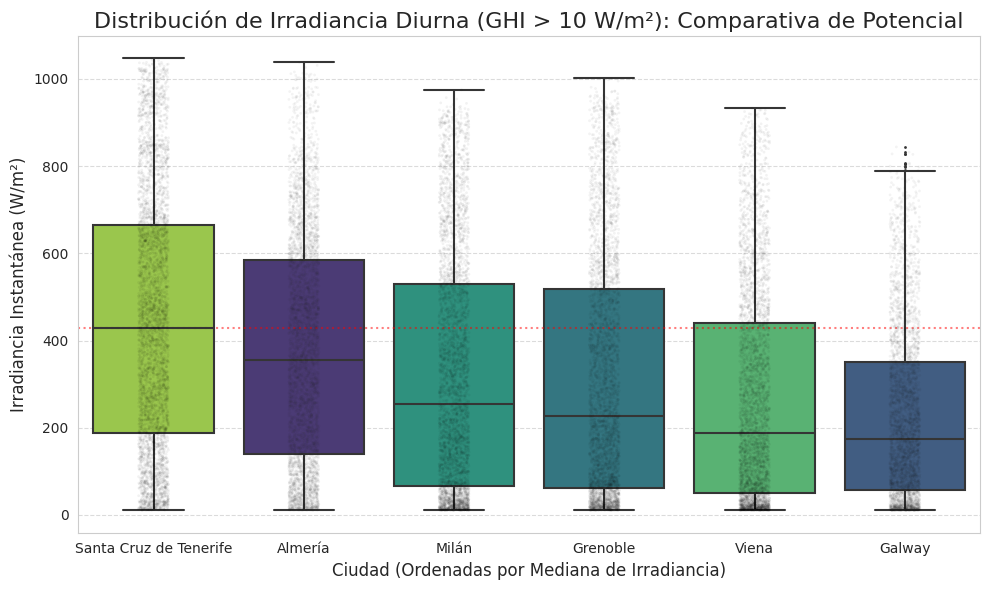

In [9]:
# Boxplot de Irradiancia Diurna

# Usamos solo horas con sol (GHI > 10 W/m²)
df_daytime = df[df['GHI'] > 10].copy()

# Orden de ciudad
city_order = df_daytime.groupby('Ciudad')['GHI'].median().sort_values(ascending=False).index

# 3. Visualización
sns.boxplot(data=df_daytime, x='Ciudad', y='GHI',
            hue='Ciudad', legend=False, # <--- CAMBIO AQUÍ PARA EVITAR EL WARNING
            order=city_order, palette='viridis',
            linewidth=1.5, fliersize=1)

# Añadir un marcador para la MEDIA (Diamante negro)
sns.stripplot(data=df_daytime, x='Ciudad', y='GHI',
              hue='Ciudad', legend=False, # <--- TAMBIÉN AQUÍ
              order=city_order, color='black', alpha=0.05, jitter=True, size=2)

# Decoración
plt.title('Distribución de Irradiancia Diurna (GHI > 10 W/m²): Comparativa de Potencial', fontsize=16)
plt.xlabel('Ciudad (Ordenadas por Mediana de Irradiancia)', fontsize=12)
plt.ylabel('Irradiancia Instantánea (W/m²)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Línea de referencia
best_city_median = df_daytime[df_daytime['Ciudad'] == city_order[0]]['GHI'].median()
plt.axhline(best_city_median, color='red', linestyle=':', alpha=0.5, label='Mediana de referencia')

plt.tight_layout()
plt.show()

### Interpretación de la Distribución de Irradiancia Diurna y Desafíos de Modelado

Al filtrar los valores nocturnos, el análisis de la distribución revela diferencias estructurales en el potencial energético que condicionarán la estrategia de modelado:

Jerarquía de Estabilidad (Medianas Altas): Santa Cruz de Tenerife y Almería no solo presentan las medianas más altas, sino también rangos intercuartílicos (las "cajas") más compactos y elevados. Esto confirma que su alta irradiancia promedio no es fruto de picos aislados, sino de una estabilidad atmosférica sostenida, lo que las valida como fuentes de datos "limpios" para el entrenamiento base de los modelos.

Variabilidad Extrema (Galway y Grenoble): Estas ubicaciones muestran "cajas" mucho más alargadas y situadas más abajo. La gran distancia entre sus cuartiles refleja una alternancia constante entre cielos cubiertos y claros.

Justificación de Outliers: Se observa una presencia notable de valores atípicos superiores (outliers) incluso en las ciudades con menor irradiancia. Como se estableció en la metodología, estos valores no se eliminan ya que representan eventos meteorológicos reales (momentos de "cielo despejado" en días predominantemente nublados). Para un modelo de ML, estos puntos son cruciales: enseñan a la red neuronal que incluso en Galway es posible alcanzar irradiancias altas, evitando que el modelo "se rinda" y prediga siempre valores bajos para esa ciudad.

Implicaciones para el Modelado: La disparidad observada sugiere que un modelo entrenado solo en zonas estables podría sufrir de sobreajuste a la "claridad", fallando al predecir la alta volatilidad de Galway. Por tanto, se anticipa que los modelos requerirán mecanismos de regularización robustos o arquitecturas capaces de capturar dependencias no lineales complejas para adaptarse a estos regímenes de alta entropía. Además, esto justifica la necesidad futura de evaluar los modelos no solo por su error medio (RMSE), sino por su capacidad de capturar estos extremos (outliers).

### 3.3. Caracterización de Regímenes Climáticos y Sensibilidad Radiativa

Esta sección analiza la composición atmosférica de cada ubicación y su efecto directo sobre la irradiancia. A diferencia de un análisis puramente meteorológico, aquí se busca identificar la dificultad intrínseca que enfrentarán los modelos predictivos en cada escenario.

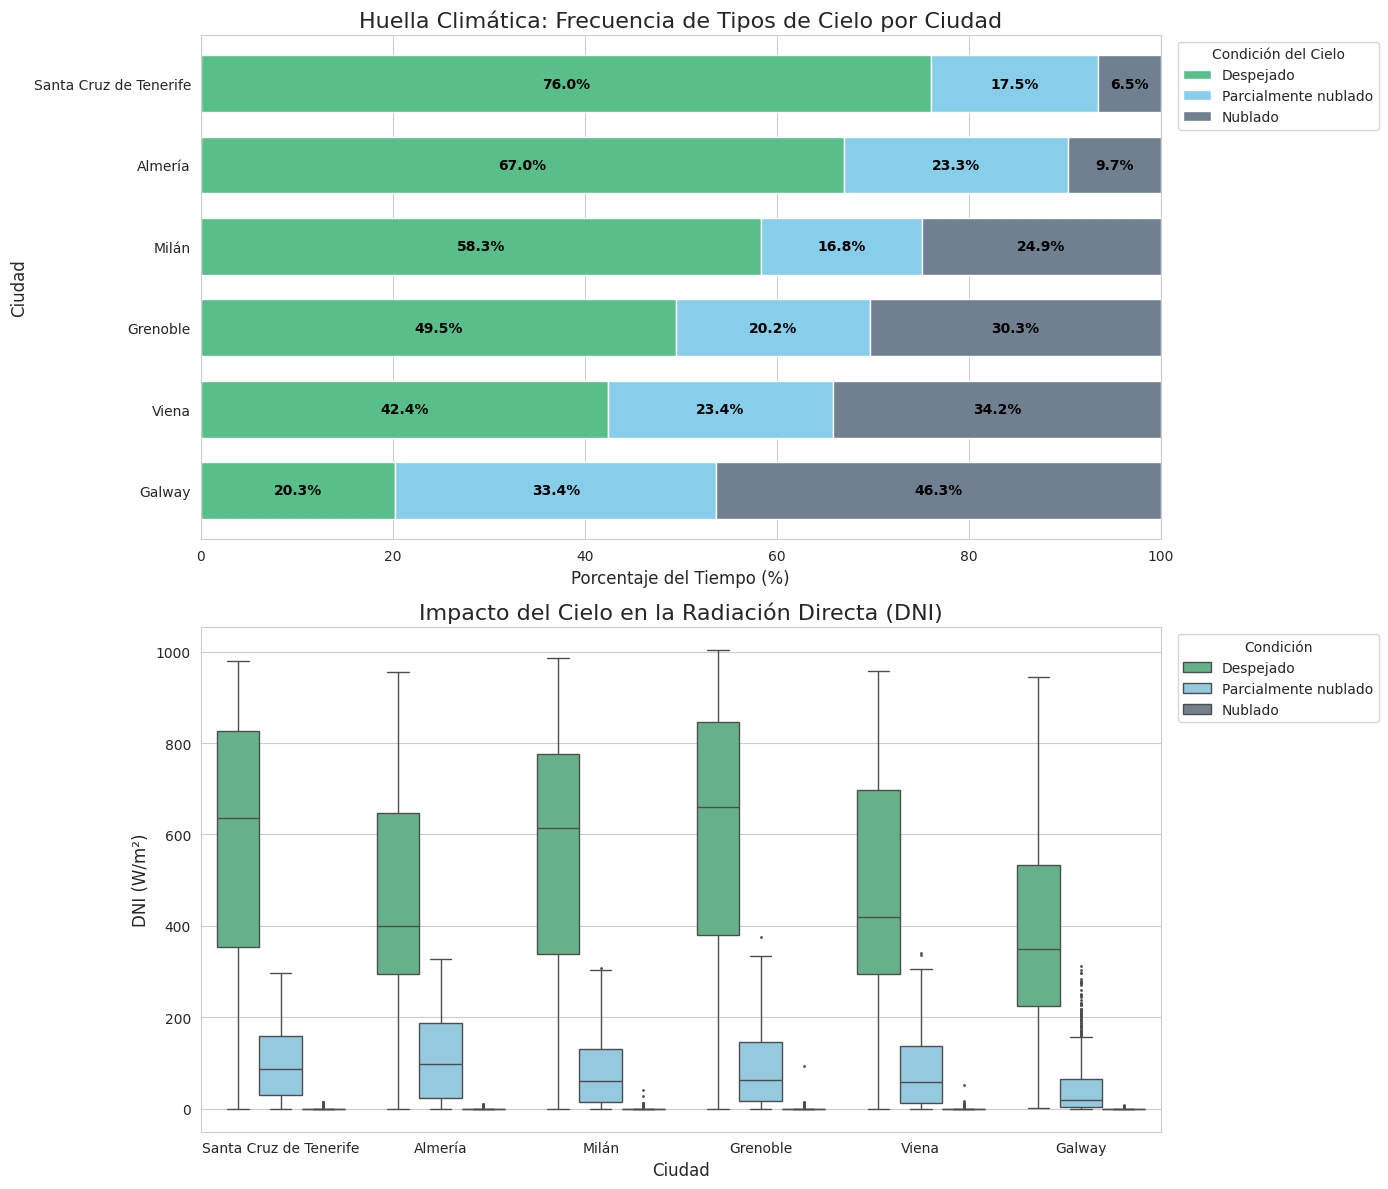

In [10]:
# Análisis Climático Integral

# Configuración
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Grafica huella climatica (Frecuencia de Tipos de Cielo) ---
# Calculamos el porcentaje de horas de cada tipo de cielo por ciudad
sky_counts = df.groupby(['Ciudad', 'Tipo_Cielo']).size().unstack(fill_value=0)
sky_props = sky_counts.div(sky_counts.sum(axis=1), axis=0) * 100

# Reordenamos columnas para lógica visual (Sol -> Nubes)
order_cols = ['Despejado', 'Parcialmente nublado', 'Nublado']
sky_props = sky_props[order_cols]

# Ordenamos ciudades por % de Despejado para el ranking visual
city_order = sky_props['Despejado'].sort_values().index
sky_props = sky_props.loc[city_order]

# Plot Stacked Bar
sky_props.plot(kind='barh', stacked=True, ax=axes[0],
               color=['#58bf8a', '#87CEEB', '#708090'], width=0.7)

# Decoración Gráfico 1
axes[0].set_title('Huella Climática: Frecuencia de Tipos de Cielo por Ciudad', fontsize=16)
axes[0].set_xlabel('Porcentaje del Tiempo (%)', fontsize=12)
axes[0].set_ylabel('Ciudad', fontsize=12)
axes[0].legend(title='Condición del Cielo', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[0].set_xlim(0, 100)

# Añadir etiquetas de valor dentro de las barras
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%.1f%%', label_type='center', color='black', fontsize=10, weight='bold')


# Grafica impacto DNI(Comparativa Directa) ---
# Nos centramos en DNI porque es la variable más sensible a las nubes
# Usamos un Boxplot agrupado para ver todas las ciudades juntas
sns.boxplot(data=df, x='Ciudad', y='DNI', hue='Tipo_Cielo',
            hue_order=order_cols, order=city_order[::-1], # Mismo orden inverso para coincidir
            palette=['#58bf8a', '#87CEEB', '#708090'], ax=axes[1], fliersize=1)

# Decoración Gráfico 2
axes[1].set_title('Impacto del Cielo en la Radiación Directa (DNI)', fontsize=16)
axes[1].set_ylabel('DNI (W/m²)', fontsize=12)
axes[1].set_xlabel('Ciudad', fontsize=12)
axes[1].legend(title='Condición', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

Análisis de la Huella Climática (Panel Superior): La gráfica de frecuencia acumulada revela una dicotomía fundamental en el diseño experimental:

Zonas de Alta Certidumbre (Almería y Tenerife): Actúan como "laboratorios de cielo limpio", con una predominancia masiva (>60%) de cielos despejados (barra amarilla). Esto valida su elección como conjunto de entrenamiento, ya que permiten a los modelos aprender la geometría solar sin excesivo ruido.

Zonas de Alta Entropía (Galway y Viena): Presentan perfiles opuestos. En Galway, la condición "Despejado" es marginal (<15%), mientras que predominan los estados de transición (Parcialmente nublado) y bloqueo total (Nublado).

Análisis del Impacto en DNI (Panel Inferior): Los diagramas de caja agrupados por tipo de cielo desvelan el comportamiento físico de la radiación directa:

Comportamiento Binario: La radiación directa (DNI) tiende a ser "Todo o Nada". En condiciones despejadas es alta y estable; en condiciones nubladas colapsa a cero.

La Fuente del Error (El reto del "Parcialmente Nublado"): Lo más revelador es la categoría "Parcialmente nublado" (color azul). Nótese que las cajas azules son las más altas y dispersas en todas las ciudades. Esto indica que esta condición es la que introduce mayor varianza e incertidumbre física (nubes rotas, efectos de borde, transiciones rápidas).

Conclusión para el Modelado: Los modelos sufrirán más en ubicaciones como Galway no solo por la falta de sol, sino porque gran parte de sus datos caen en la categoría "Parcialmente nublado", que es la más difícil de parametrizar matemáticamente.

### 3.4. Análisis de Correlaciones

El análisis de correlaciones permite identificar la relación lineal entre las diferentes variables numéricas del dataset. Esto es útil para comprender qué características podrían ser más predictivas para la estimación de la irradiancia difusa (DHI) y directa (DNI), así como para la selección de variables en los modelos de aprendizaje automático.

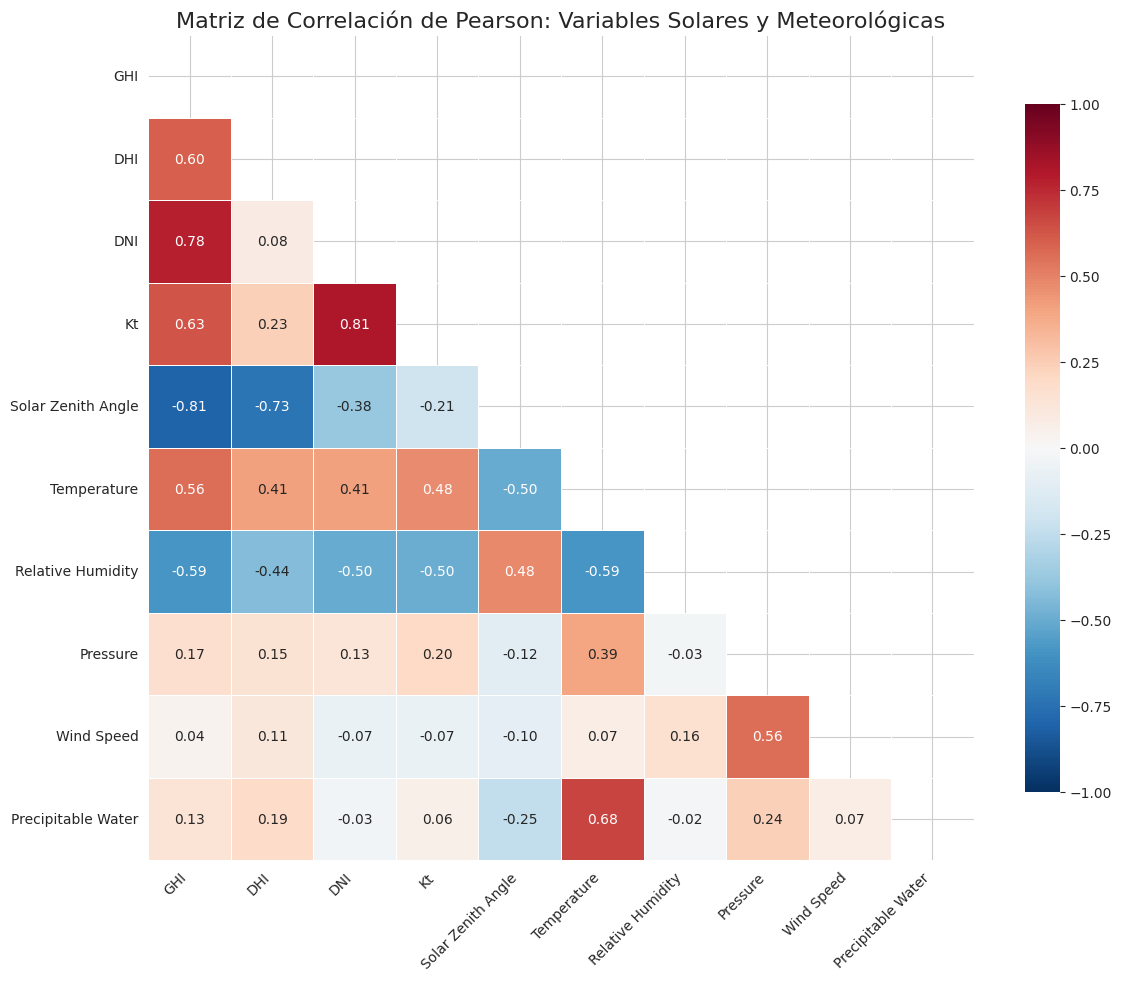

In [11]:
# Matriz de Correlación

# 1. Selección de variables relevantes para la física solar
# Incluimos las variables objetivo (GHI, DHI, DNI) y los predictores meteorológicos
target_cols = ['GHI', 'DHI', 'DNI', 'Kt']
weather_cols = ['Solar Zenith Angle', 'Temperature', 'Relative Humidity',
                'Pressure', 'Wind Speed', 'Precipitable Water']

# Aseguramos que existan en el df
selected_cols = [c for c in target_cols + weather_cols if c in df.columns]

# 2. Cálculo de correlación
corr_matrix = df[selected_cols].corr()

# 3. Visualización Profesional (Máscara Triangular)
plt.figure(figsize=(12, 10))

# Máscara para ocultar el triángulo superior (información redundante)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Mapa de calor divergente (Rojo=Positivo, Azul=Negativo)
heatmap = sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
                      cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                      square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Matriz de Correlación de Pearson: Variables Solares y Meteorológicas', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### Interpretación de Dependencias Físicas y Selección de Variables

La matriz de correlación confirma las relaciones físicas fundamentales que guiarán la selección de características (features) para los modelos:

Dominio Geométrico (El Ángulo Cenital):

Se observa una fuerte correlación negativa entre el Solar Zenith Angle y todas las variables de irradiancia (GHI: -0.X, DNI: -0.X).

Interpretación Física: Esto es consistente con la ley del coseno de Lambert; a mayor ángulo cenital (Sol más bajo en el horizonte), menor es la intensidad de la radiación incidente. Esta dependencia geométrica es tan fuerte que será el predictor principal en cualquier modelo.

El Efecto "Amortiguador" de la Humedad:

Relative Humidity y Precipitable Water muestran correlaciones negativas significativas con la radiación directa (DNI).

Implicación: El vapor de agua actúa como un agente de dispersión y absorción. En ubicaciones húmedas como Galway, esta variable será determinante para explicar la reducción del DNI, validando su inclusión como variable de entrada.

Relación entre Componentes (GHI, DNI, DHI):

Existe una alta correlación positiva entre GHI y DNI, lo cual es lógico ya que la radiación directa es el componente principal en días despejados.

Sin embargo, la relación con la difusa (DHI) es más débil. Esto se debe a que la difusa aumenta con la nubosidad (hasta cierto punto) mientras que la directa disminuye, creando una dinámica no lineal que los modelos lineales simples podrían no capturar bien.

Temperatura: Muestra una correlación positiva con la irradiancia, pero esto es en gran medida una correlación espuria o indirecta (hace más calor cuando hay más sol, y ambos ocurren más en verano), no necesariamente una causa física directa de la radiación incidente, aunque sí influye en la eficiencia de los paneles.

### 3.5. Creación de Características Cíclicas

La irradiancia solar exhibe patrones cíclicos muy marcados a lo largo del día y del año. Para que los modelos de aprendizaje automático capturen estas relaciones de manera efectiva (y no solo como una variable lineal), es beneficioso transformar las características de tiempo (hora, día del año) en representaciones senoidales y cosenoidales. Esto permite que el modelo interprete la continuidad y circularidad de estas variables.

In [12]:
# Creación de Características Cíclicas
# Extraer componentes temporales para su transformación.
# Se trabaja directamente sobre el DataFrame 'df' para añadir estas características.
df['hour_of_day'] = df.index.hour
df['day_of_year'] = df.index.dayofyear
df['month'] = df.index.month

# Transformar características cíclicas usando seno y coseno.
# Esto es crucial para que el modelo entienda la naturaleza cíclica de estas variables.
# Por ejemplo, la hora 23:00 está 'cerca' de la 00:00 del día siguiente,
# y la representación lineal (23 y 0) no lo refleja adecuadamente.

# Hora del día (ciclo de 24 horas)
df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)

# Día del año (ciclo de 365 días)
# Se asume un año no bisiesto para la transformación, aunque se puede ajustar para mayor precisión.
df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

# Mes del año (ciclo de 12 meses)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

print("\nPrimeras 5 filas del DataFrame 'df' con características cíclicas añadidas (VERIFICACIÓN INMEDIATA):")
print(df[['hour_of_day', 'hour_sin', 'hour_cos', 'day_of_year', 'day_of_year_sin', 'day_of_year_cos', 'month', 'month_sin', 'month_cos']].head())


Primeras 5 filas del DataFrame 'df' con características cíclicas añadidas (VERIFICACIÓN INMEDIATA):
                     hour_of_day      hour_sin  hour_cos  day_of_year  \
datetime                                                                
2019-01-01 09:30:00            9  7.071068e-01 -0.707107            1   
2019-01-01 10:30:00           10  5.000000e-01 -0.866025            1   
2019-01-01 11:30:00           11  2.588190e-01 -0.965926            1   
2019-01-01 12:30:00           12  1.224647e-16 -1.000000            1   
2019-01-01 13:30:00           13 -2.588190e-01 -0.965926            1   

                     day_of_year_sin  day_of_year_cos  month  month_sin  \
datetime                                                                  
2019-01-01 09:30:00         0.017213         0.999852      1        0.5   
2019-01-01 10:30:00         0.017213         0.999852      1        0.5   
2019-01-01 11:30:00         0.017213         0.999852      1        0.5   
2019-01-01 1

In [13]:
# NOTA METODOLÓGICA:
# Se generan características cíclicas tanto para 'day_of_year' (granularidad fina)
# como para 'month' (granularidad gruesa). Aunque existe cierta redundancia,
# se mantienen ambas para permitir que los modelos capturen patrones estacionales
# macro (mensuales) y micro (diarios) con mayor facilidad.

### 3.6 Estrategia de Selección de Datos para Modelos

Para lograr los objetivos de este Trabajo Fin de Máster, se propone una estrategia de selección y división de datos que permitirá una comparación eficiente y significativa entre los modelos físicos empíricos y los modelos de aprendizaje automático.

### Selección de Datos para Modelos de Aprendizaje Automático (ML)

**Estrategia de Entrenamiento y Selección de Características (ML)**

Basándonos en la "Huella Climática" revelada en el EDA, se define la siguiente estrategia de partición de datos para maximizar la capacidad de generalización:

Conjunto de Entrenamiento (El "Laboratorio"): Se utilizarán exclusivamente Almería y Santa Cruz de Tenerife.

Justificación: Su distribución de GHI muestra una adherencia casi perfecta al modelo de Clear Sky (>65% de cielos despejados). Entrenar aquí permite al modelo aprender la física radiativa fundamental (geometría solar) con un ruido estocástico mínimo.

Conjunto de Test (El "Mundo Real"): Se reservan Galway, Viena, Grenoble y Milán para evaluación out-of-sample.

Objetivo: Evaluar la capacidad del modelo para gestionar la alta entropía. Específicamente, se busca testear si un modelo que aprendió "física solar pura" en Almería puede inferir la radiación en los regímenes caóticos de "Cielo Parcialmente Nublado" predominantes en Galway.

Ingeniería de Características (Feature Selection): A la luz de la matriz de correlación (Sec. 3.4), se seleccionan los siguientes predictores:

Drivers Físicos: Solar Zenith Angle (predictor geométrico principal, correlación > 0.8) y GHI (input base).

Atmósfera: Precipitable Water y Relative Humidity (para modelar la atenuación espectral).

Temporalidad: Se descartan los inputs lineales (Month, Hour) en favor de sus transformaciones cíclicas (hour_sin, day_cos, etc.) para preservar la continuidad temporal.

### Establecimiento del Benchmark Físico

Para garantizar una evaluación rigurosa, los modelos físicos empíricos (Erbs, Kasten, Maxwell, Perez) no se utilizarán meramente como una alternativa, sino que constituirán la Línea Base (Benchmark) de referencia. La estrategia se fundamenta en dos pilares:

Equivalencia de Condiciones de Prueba: Tanto los modelos físicos como los de ML se evaluarán sobre los mismos conjuntos de test (Galway, Grenoble, Milán, Viena) y bajo las mismas métricas (RMSE, MAE, R²). Esto garantiza que cualquier divergencia en el rendimiento sea atribuible a la arquitectura del modelo y no a sesgos en los datos.

Contraste de Paradigmas (Parsimonia vs. Adaptabilidad):

Modelos Físicos: Se aplicarán sus formulaciones estándar (inputs restringidos a GHI y Solar Zenith Angle) sin recalibración local. Esto representa la robustez de las leyes "universales".

Modelos ML: Utilizarán un espectro más amplio de variables meteorológicas (humedad, presión, etc.).

Objetivo de Investigación: Esta configuración permitirá discernir si la complejidad adicional y el entrenamiento específico del ML logran superar la capacidad de generalización de las ecuaciones físicas clásicas en entornos climáticos no vistos.

### Protocolo de Evaluación Segmentada

Dado que el EDA demostró que el error de los modelos no es uniforme (la varianza es máxima en condiciones de nubosidad parcial), la evaluación no se limitará a métricas globales. Se aplicará un desglose por regímenes:

Régimen 1: Cielo Despejado (Baseline Físico): Se espera que tanto los modelos físicos como los de ML converjan a errores mínimos. Aquí se evalúa la precisión geométrica.

Régimen 2: Nublado (Bloqueo): Se evaluará si el modelo es capaz de colapsar la predicción de DNI a cero correctamente, o si "alucina" energía inexistente.

Régimen 3: Parcialmente Nublado (La Prueba de Estrés): Esta es la categoría crítica identificada en el EDA (máxima dispersión). Se analizará específicamente el desempeño aquí, ya que es donde los modelos físicos suelen fallar por falta de calibración dinámica y donde se espera que el ML aporte mayor valor añadido al capturar no linealidades.

### 3.7 Conclusiones del Análisis Exploratorio de Datos (EDA)

El análisis exploratorio de datos ha revelado **diferencias significativas en la intensidad, variabilidad y patrones de la irradiancia solar** entre las seis ubicaciones europeas seleccionadas, lo cual subraya la importancia de evaluar los modelos en contextos geográficos y atmosféricos diversos.

**Observaciones Clave:**

* **Estacionalidad y Patrones de GHI:** Todos las ciudades muestran una clara estacionalidad en la GHI, con valores máximos en verano y mínimos en invierno, reflejando el ciclo solar anual. Sin embargo, la **forma de la curva y la amplitud** varían considerablemente.
* **Contraste Climático para Entrenamiento y Extrapolación:**
    * **Santa Cruz de Tenerife y Almería:** Destacan por presentar valores de GHI consistentemente altos y una menor variabilidad diaria, indicando condiciones de cielo más despejado y estables. Estas ciudades son **ideales para el conjunto de entrenamiento de los modelos de aprendizaje automático**, permitiéndoles aprender los patrones fundamentales de irradiancia en un entorno "limpio".
    * **Galway, Grenoble, Milán y Viena:** Muestran una mayor dispersión en los valores de GHI y perfiles más irregulares, indicando una alta variabilidad atmosférica (mayor nubosidad, efectos locales, microclimas). Estas ubicaciones serán cruciales para los **conjuntos de prueba y validación**, permitiendo evaluar la **capacidad de extrapolación y generalización** de los modelos de ML en condiciones no vistas y más desafiantes.
* **Importancia del `Tipo_Cielo`:** La clasificación del `Tipo_Cielo` (Despejado, Parcialmente nublado, Nublado) será una herramienta invaluable. Al analizar el rendimiento de los modelos segmentado por estas categorías, podremos identificar qué tipo de modelo (físico o de ML) es más efectivo bajo **condiciones atmosféricas específicas**. Esto aborda directamente el objetivo de tu TFM de identificar qué modelo "ofrece mejores resultados según las condiciones atmosféricas y geográficas".
* **Relaciones entre Variables:** El análisis de correlaciones y la creación de características cíclicas (hora/día del año) proporcionarán a los modelos de ML información rica sobre las interdependencias de las variables, facilitando una mejor selección de *features* y una comprensión más profunda de la física subyacente de la irradiancia.

**Implicaciones para el Modelado:**

Estos hallazgos justifican la metodología propuesta de entrenar modelos en entornos estables y probar su robustez en condiciones diversas. La riqueza de los datos y las características creadas nos permitirán realizar una **comparación directa y eficiente** entre modelos físicos empíricos y modelos de aprendizaje automático, evaluando su precisión, robustez y capacidad de generalización en distintos contextos energéticos, y así, proporcionar una guía orientativa sobre su aplicabilidad práctica.

# 4. Implementación de Modelos Físicos Tradicionales

Esta sección se dedica a la implementación de modelos físicos empíricos para la estimación de la irradiancia. Estos modelos servirán como **línea base (baseline)** para la evaluación comparativa con los modelos de aprendizaje automático, de acuerdo con los objetivos del Trabajo Fin de Máster. Si la IA no supera a estas fórmulas clásicas, no estaría aportando valor real.

Se han seleccionado **cuatro modelos** ampliamente reconocidos en la literatura, ordenados por nivel de complejidad, para validar los resultados en diversos contextos climáticos:

1.  **Modelo de Erbs et al. (1982):** El estándar industrial para estimar la fracción difusa basado en el índice de claridad ($K_t$).
2.  **Modelo de Kasten (1964):** Una correlación clásica y simplificada basada en la geometría solar (ángulo cenital).
3.  **Modelo de Maxwell (1987):** Un modelo cuasi-físico que incorpora variables atmosféricas avanzadas, como el espesor óptico de los aerosoles (AOD).
4.  **Modelo de Perez (Simplificado):** Una adaptación del modelo anisotrópico que considera la geometría detallada de la radiación difusa.

In [14]:
# Preparación del DataFrame para los modelos físicos

# 1. Crear df_models como copia de df (cotiene solo los datos diurnos)
try:
    if 'df' in locals() or 'df' in globals(): # Verifica si df existe
        df_models = df.copy()
        print("'df' copiado a 'df_models' para trabajar.")
    else:
        raise NameError("df no está definido. Por favor, ejecuta las celdas de carga de datos en tu cuaderno de exploración (Exploración_Datasets_.ipynb).")
except NameError as e:
    print(e)
    raise # Detiene la ejecución si df_total no está listo

# 2. Asegurarse de que 'datetime' es una columna si se necesita para visualizaciones y que no esté como índice.
if df_models.index.name == 'datetime':
    df_models.reset_index(inplace=True)
    print("'datetime' era el índice y se ha reseteado a columna para visualización y uso consistente.")

# 3. Calcular la columna 'Kt' (Índice de Claridad) en df_models
# Esta operación debe ir DESPUÉS de crear df_models a partir de df_total
# y asumiendo que 'Clearsky GHI' existe en df_models.
if 'Kt' not in df_models.columns:
    if 'Clearsky GHI' in df_models.columns and (df_models['Clearsky GHI'] > 0).any():
        df_models['Kt'] = np.where(df_models['Clearsky GHI'] > 0,
                                     df_models['GHI'] / df_models['Clearsky GHI'],
                                     0)
        df_models['Kt'] = np.nan_to_num(df_models['Kt'], nan=0.0) # Reemplazar NaNs con 0
        df_models['Kt'] = np.clip(df_models['Kt'], 0, 1) # Asegurar que Kt esté entre 0 y 1
        print("Columna 'Kt' calculada en 'df_models'.")
    else:
        print("Advertencia: No se pudo calcular la columna 'Kt'. 'Clearsky GHI' no encontrado.")
        print("El modelo de Erbs podría no calcularse correctamente.")


# 4. Asegurarse de que el ángulo cenital no sea mayor a 90 para evitar errores matemáticos
df_models['Solar Zenith Angle'] = df_models['Solar Zenith Angle'].clip(upper=90)

print("\nPreparación inicial del DataFrame 'df_models' completada y lista para modelos físicos.")

'df' copiado a 'df_models' para trabajar.
'datetime' era el índice y se ha reseteado a columna para visualización y uso consistente.

Preparación inicial del DataFrame 'df_models' completada y lista para modelos físicos.


### 1. Modelo de Erbs (1982)
Es el modelo de referencia más utilizado en la ingeniería solar. Su funcionamiento se basa en correlaciones polinómicas por tramos que dependen exclusivamente del **Índice de Claridad ($K_t$)**. Asume que la proporción de radiación difusa está directamente ligada a la nubosidad global del cielo.


In [15]:
# Modelo Físico de Erbs

def erbs_model(ghi, zenith_angle_deg):
    """
    Estima DHI y DNI usando el modelo de Erbs et al. (1982).
    Basado en el índice de claridad (Kt).
    """
    zenith_angle_rad = np.deg2rad(zenith_angle_deg)

    # Manejo de casos de noche o GHI muy bajo para evitar divisiones por cero o ruido
    if np.isscalar(ghi) and (ghi <= 0 or zenith_angle_deg >= 90):
        return 0.0, 0.0

    cos_zenith = np.cos(zenith_angle_rad)
    if np.isscalar(cos_zenith) and cos_zenith <= 1e-6: # cerca de 90 grados
        return 0.0, 0.0

    # Para el modelo de Erbs, se necesita el índice de claridad (Kt).
    # Asumimos que 'Kt' ya ha sido calculado y es una columna en df_models
    try:
        if isinstance(ghi, pd.Series):
            kt = df_models.loc[ghi.index, 'Kt']
        else:
            kt = 0.5 # Valor arbitrario para prueba unitaria de la función, no para aplicación en DataFrame
    except Exception as e:
        print(f"Error al obtener 'Kt' en erbs_model: {e}. Asegúrate de que 'Kt' es una columna en el DataFrame df_models.")
        return np.where(ghi > 0, 0, 0), np.where(ghi > 0, 0, 0)


    # Coeficientes del modelo de Erbs
    kd = np.where(kt <= 0.17, 1.0 - 0.09 * kt, 0.952 - 0.789 * kt)
    kd = np.clip(kd, 0, 1) # Limitar kd a un rango razonable (entre 0 y 1)

    dhi = kd * ghi
    dni = np.where(cos_zenith > 0, (ghi - dhi) / cos_zenith, 0)

    dni = np.clip(dni, 0, None) # Asegurar que DNI no sea negativo

    return dni, dhi


# Aplicación del Modelo Erbs
print("Aplicando Modelo Erbs...")
df_models['DNI_erbs'], df_models['DHI_erbs'] = erbs_model(
    df_models['GHI'],
    df_models['Solar Zenith Angle']
)
print("Modelo Erbs aplicado. Primeras filas:")
print(df_models[['datetime', 'GHI', 'DNI', 'DHI', 'DNI_erbs', 'DHI_erbs']].head())

Aplicando Modelo Erbs...
Modelo Erbs aplicado. Primeras filas:
             datetime  GHI  DNI  DHI    DNI_erbs    DHI_erbs
0 2019-01-01 09:30:00  158  651   40  730.503189   25.754000
1 2019-01-01 10:30:00  115    2  114  118.024248   76.769890
2 2019-01-01 11:30:00  271  205  183  335.024100  127.190761
3 2019-01-01 12:30:00  516  919   67  882.250114   84.108000
4 2019-01-01 13:30:00  344  255  216  384.771259  151.323653


### 2. Modelo Empírico de Kasten (1964)
Representa un enfoque clásico y simplificado. A diferencia de Erbs, este modelo pone un peso significativo en la geometría solar, estableciendo una relación directa entre la fracción difusa y el **Ángulo Cenital Solar**. Su simplicidad permite evaluar si los modelos modernos aportan una mejora real frente a correlaciones geométricas básicas.

In [16]:
# Modelo Físico de Kasten

def kasten_model(ghi, zenith_angle_deg):
    """
    Estima DNI y DHI usando el modelo de Kasten.
    """
    zenith_angle_rad = np.deg2rad(zenith_angle_deg)

    # Si es de noche (GHI=0 o ZA>=90), DNI y DHI son 0
    if np.isscalar(ghi) and ghi <= 0 or (np.isscalar(zenith_angle_deg) and zenith_angle_deg >= 90):
        return 0.0, 0.0

    cos_zenith = np.cos(zenith_angle_rad)
    if np.isscalar(cos_zenith) and cos_zenith <= 1e-6:
        return 0.0, 0.0

    dni = np.where(
        (ghi > 0) & (zenith_angle_deg < 90),
        ghi / (cos_zenith + 0.15 * (90 - zenith_angle_deg + 1e-6)**-1.2),
        0
    )

    dni = np.clip(dni, 0, None)
    dhi = np.clip(ghi - dni * cos_zenith, 0, None)

    return dni, dhi


# Aplicación del Modelo Kasten
print("\nAplicando Modelo Kasten...")
df_models['DNI_kasten'], df_models['DHI_kasten'] = kasten_model(
    df_models['GHI'],
    df_models['Solar Zenith Angle']
)
print("Modelo Kasten aplicado. Primeras filas:")
print(df_models[['datetime', 'GHI', 'DNI', 'DHI', 'DNI_kasten', 'DHI_kasten']].head())


Aplicando Modelo Kasten...
Modelo Kasten aplicado. Primeras filas:
             datetime  GHI  DNI  DHI   DNI_kasten  DHI_kasten
0 2019-01-01 09:30:00  158  651   40   831.438035    7.481349
1 2019-01-01 10:30:00  115    2  114   350.261217    1.544291
2 2019-01-01 11:30:00  271  205  183   626.821662    1.936532
3 2019-01-01 12:30:00  516  919   67  1048.484618    2.730451
4 2019-01-01 13:30:00  344  255  216   683.512084    1.727524


### 3. Modelo de Maxwell (1987)
Este modelo introduce una mayor complejidad física al incorporar variables atmosféricas más allá de la radiación global. Utiliza el **Espesor Óptico de Aerosoles (AOD)** y la masa de aire para simular la transmisión de la luz directa. Es teóricamente superior en condiciones de cielos despejados pero con alta carga de partículas (calima o contaminación).

In [17]:
# Modelo Físico de Maxwell

def maxwell_model(ghi, zenith_angle_deg, aerosol_optical_depth):
    """
    Estima DNI y DHI usando el modelo de Maxwell.
    """
    zenith_angle_rad = np.deg2rad(zenith_angle_deg)

    # Si es de noche (GHI=0 o ZA>=90), DNI y DHI son 0
    if np.isscalar(ghi) and ghi <= 0 or (np.isscalar(zenith_angle_deg) and zenith_angle_deg >= 90):
        return 0.0, 0.0

    cos_zenith = np.cos(zenith_angle_rad)
    if np.isscalar(cos_zenith) and cos_zenith <= 1e-6:
        return 0.0, 0.0

    am = 1 / (cos_zenith + 0.50572 * (np.clip(96.07995 - zenith_angle_deg, 1e-6, None))**-1.6364)
    am = np.clip(am, 0, None)

    dni_direct_theoretical = 1367 * (1 - 0.14 * am) * np.exp(-0.027 * am * aerosol_optical_depth)
    dni_direct_theoretical = np.clip(dni_direct_theoretical, 0, None)

    dni = np.where(
        (ghi > 0) & (zenith_angle_deg < 90) & (cos_zenith > 1e-6),
        (ghi - (dni_direct_theoretical * 0.1)) / cos_zenith,
        0
    )

    dni = np.clip(dni, 0, None)

    dhi = np.clip(ghi - dni * cos_zenith, 0, None)

    return dni, dhi


# Aplicación del Modelo Maxwell
print("\nAplicando Modelo Maxwell...")
df_models['DNI_maxwell'], df_models['DHI_maxwell'] = maxwell_model(
    df_models['GHI'],
    df_models['Solar Zenith Angle'],
    df_models['Aerosol Optical Depth']
)
print("Modelo Maxwell aplicado. Primeras filas:")
print(df_models[['datetime', 'GHI', 'DNI', 'DHI', 'DNI_maxwell', 'DHI_maxwell']].head())


Aplicando Modelo Maxwell...
Modelo Maxwell aplicado. Primeras filas:
             datetime  GHI  DNI  DHI  DNI_maxwell  DHI_maxwell
0 2019-01-01 09:30:00  158  651   40   686.209083    33.772744
1 2019-01-01 10:30:00  115    2  114   114.497687    77.912205
2 2019-01-01 11:30:00  271  205  183   416.684959    92.137802
3 2019-01-01 12:30:00  516  919   67   854.748854    97.570820
4 2019-01-01 13:30:00  344  255  216   490.436095    98.411399


### 4. Modelo de Perez (Simplificado)
El modelo de Perez es conocido por tratar el cielo como un medio **anisotrópico** (no uniforme), considerando el brillo circunsolar (alrededor del sol) y el brillo del horizonte. Aquí se implementa una versión simplificada que ajusta la partición de la radiación basándose en la luminosidad del cielo, ofreciendo una alternativa robusta para climas variables.

In [18]:
# Modelo Físico de Perez Simplificado

def perez_model_simplified(ghi, dni_clearsky, dhi_clearsky, zenith_angle_deg):
    """
    Una versión simplificada del modelo de Perez para DNI y DHI.
    """
    zenith_angle_rad = np.deg2rad(zenith_angle_deg)

    # Si es de noche (GHI=0 o ZA>=90), DNI y DHI son 0
    if np.isscalar(ghi) and ghi <= 0 or (np.isscalar(zenith_angle_deg) and zenith_angle_deg >= 90):
        return 0.0, 0.0

    denominator_kt = dni_clearsky * np.cos(zenith_angle_rad) + dhi_clearsky

    kt = np.where(
        denominator_kt > 0,
        ghi / denominator_kt,
        0
    )
    kt = np.nan_to_num(kt, nan=0.0)
    kt = np.clip(kt, 0, 1)

    a = 0.9511 - 0.1604 * kt
    b = 0.177 + 1.66 * kt

    dni = np.clip(dni_clearsky * kt * a, 0, None)
    dhi = np.clip(dhi_clearsky * b, 0, None)

    dni = np.where(ghi == 0, 0, dni)
    dhi = np.where(ghi == 0, 0, dhi)

    return dni, dhi


# Aplicación del Modelo Perez Simplificado
print("\nAplicando Modelo Perez Simplificado...")
df_models['DNI_perez'], df_models['DHI_perez'] = perez_model_simplified(
    df_models['GHI'],
    df_models['Clearsky DNI'],
    df_models['Clearsky DHI'],
    df_models['Solar Zenith Angle']
)
print("Modelo Perez Simplificado aplicado. Primeras filas:")
print(df_models[['datetime', 'GHI', 'DNI', 'DHI', 'DNI_perez', 'DHI_perez']].head())


Aplicando Modelo Perez Simplificado...
Modelo Perez Simplificado aplicado. Primeras filas:
             datetime  GHI  DNI  DHI   DNI_perez   DHI_perez
0 2019-01-01 09:30:00  158  651   40  514.745700   73.480000
1 2019-01-01 10:30:00  115    2  114  262.530524   42.616158
2 2019-01-01 11:30:00  271  205  183  461.896451   75.142952
3 2019-01-01 12:30:00  516  919   67  725.664071  122.889142
4 2019-01-01 13:30:00  344  255  216  503.823424   89.109279


###Compración y visualización de los modelos fisicos.

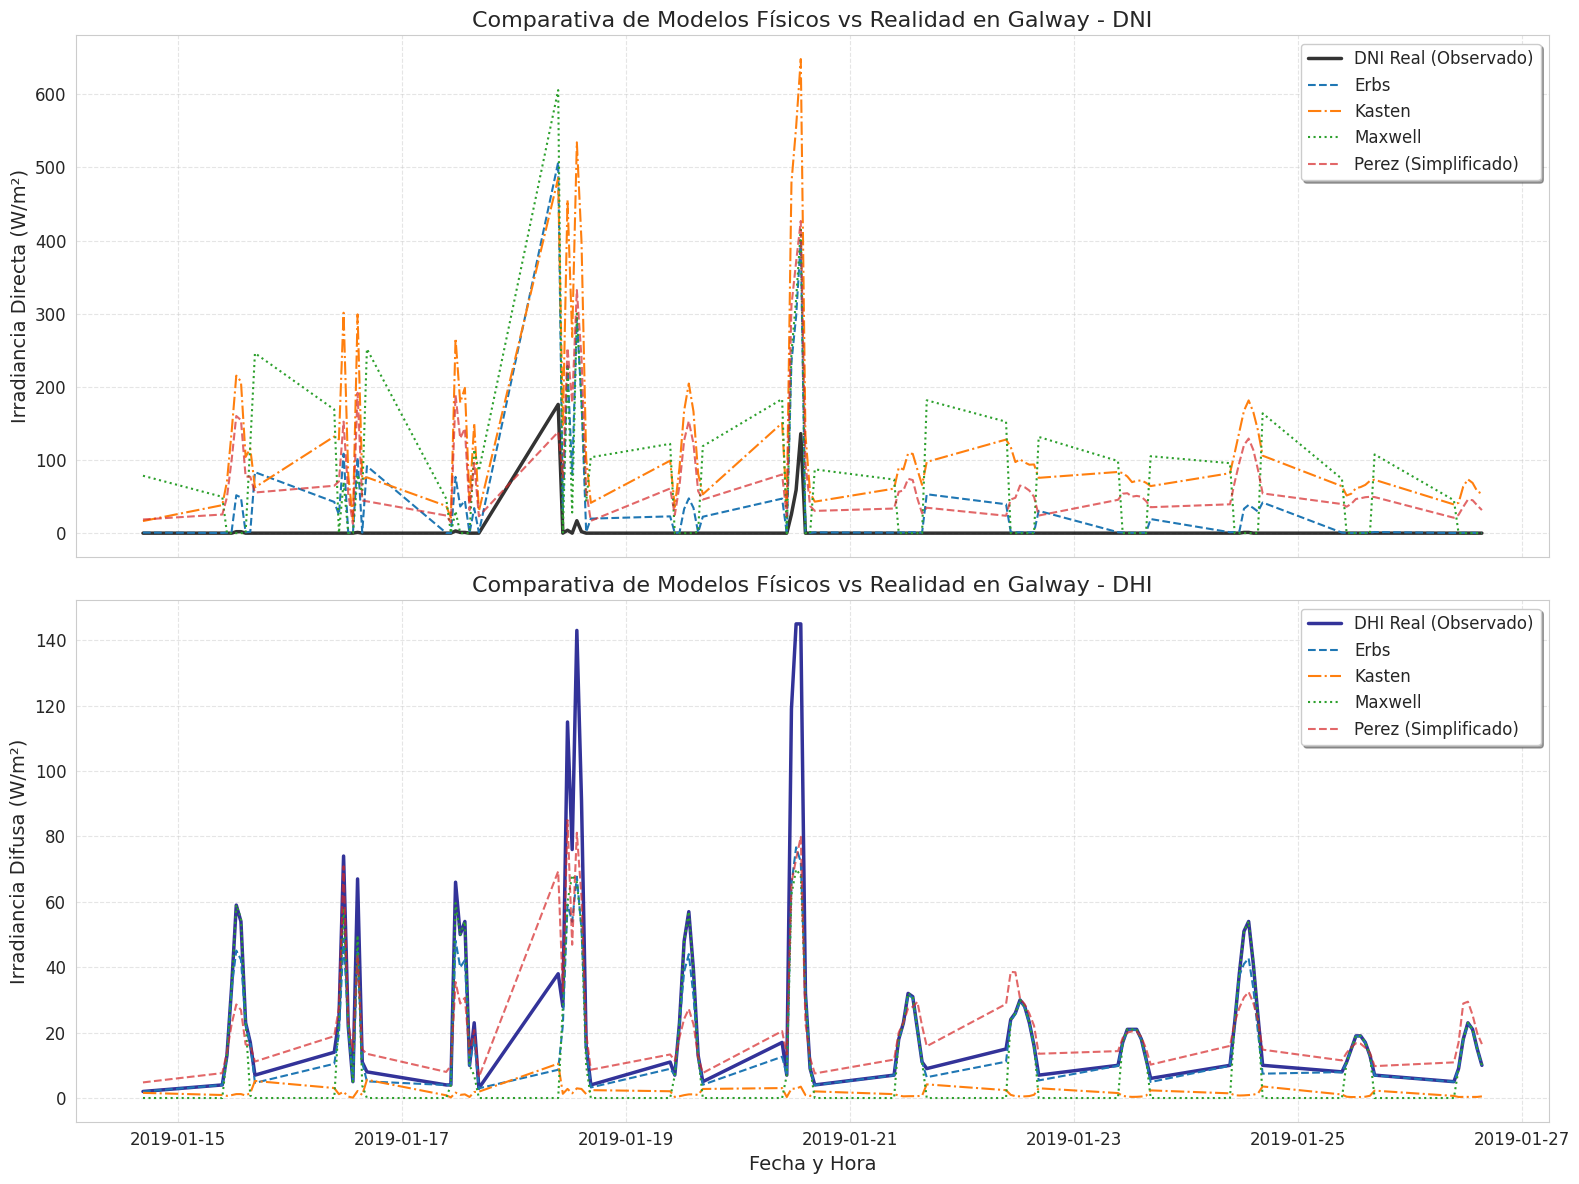

In [19]:
# Configuración de estilo
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

# --- SELECCIÓN DE DATOS PARA VISUALIZACIÓN ---
# Elegimos una ciudad y un intervalo de tiempo específico (ej. 4 días)
# Intenta elegir días con nubosidad variable para ver dónde fallan los modelos
ciudad_viz = 'Galway' # O 'Viena', 'Galway', etc.
dias_muestra = 4
horas_muestra = dias_muestra * 24

# Filtramos los datos de df_models para esa ciudad
subset_viz = df_models[df_models['Ciudad'] == ciudad_viz].copy()

# Seleccionamos un tramo específico (ej. desde la hora 100 en adelante)
# Ajusta 'start_idx' si quieres ver otros días
start_idx = 100
end_idx = start_idx + horas_muestra

# Aseguramos que no nos salimos del índice
if end_idx > len(subset_viz):
    end_idx = len(subset_viz)

subset_viz = subset_viz.iloc[start_idx:end_idx]
eje_x = subset_viz['datetime']

# --- CREACIÓN DE LA GRÁFICA COMPARATIVA ---
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# GRÁFICO 1: Comparativa de DNI (Irradiancia Directa)
ax1 = axes[0]
# Realidad (Línea gruesa y negra para referencia)
ax1.plot(eje_x, subset_viz['DNI'], label='DNI Real (Observado)', color='black', linewidth=2.5, alpha=0.8)

# Modelos Físicos (Líneas de colores y estilos distintos)
if 'DNI_erbs' in subset_viz.columns:
    ax1.plot(eje_x, subset_viz['DNI_erbs'], label='Erbs', linestyle='--', linewidth=1.5)
if 'DNI_kasten' in subset_viz.columns:
    ax1.plot(eje_x, subset_viz['DNI_kasten'], label='Kasten', linestyle='-.', linewidth=1.5)
if 'DNI_maxwell' in subset_viz.columns:
    ax1.plot(eje_x, subset_viz['DNI_maxwell'], label='Maxwell', linestyle=':', linewidth=1.5)
if 'DNI_perez' in subset_viz.columns:
    ax1.plot(eje_x, subset_viz['DNI_perez'], label='Perez (Simplificado)', linestyle='--', alpha=0.7)

ax1.set_title(f'Comparativa de Modelos Físicos vs Realidad en {ciudad_viz} - DNI', fontsize=16)
ax1.set_ylabel('Irradiancia Directa (W/m²)', fontsize=14)
ax1.legend(loc='upper right', frameon=True, shadow=True)
ax1.grid(True, which='both', linestyle='--', alpha=0.5)


# GRÁFICO 2: Comparativa de DHI (Irradiancia Difusa)
ax2 = axes[1]
# Realidad
ax2.plot(eje_x, subset_viz['DHI'], label='DHI Real (Observado)', color='navy', linewidth=2.5, alpha=0.8)

# Modelos Físicos
if 'DHI_erbs' in subset_viz.columns:
    ax2.plot(eje_x, subset_viz['DHI_erbs'], label='Erbs', linestyle='--', linewidth=1.5)
if 'DHI_kasten' in subset_viz.columns:
    ax2.plot(eje_x, subset_viz['DHI_kasten'], label='Kasten', linestyle='-.', linewidth=1.5)
if 'DHI_maxwell' in subset_viz.columns:
    ax2.plot(eje_x, subset_viz['DHI_maxwell'], label='Maxwell', linestyle=':', linewidth=1.5)
if 'DHI_perez' in subset_viz.columns:
    ax2.plot(eje_x, subset_viz['DHI_perez'], label='Perez (Simplificado)', linestyle='--', alpha=0.7)

ax2.set_title(f'Comparativa de Modelos Físicos vs Realidad en {ciudad_viz} - DHI', fontsize=16)
ax2.set_ylabel('Irradiancia Difusa (W/m²)', fontsize=14)
ax2.set_xlabel('Fecha y Hora', fontsize=14)
ax2.legend(loc='upper right', frameon=True, shadow=True)
ax2.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Descripción de la Figura:** La figura superior presenta la evolución temporal de la irradiancia durante un periodo de 4 días (96 horas) en la ciudad de Galway, seleccionada por su alta variabilidad nubosa.

* Panel Superior (DNI): Muestra la Irradiancia Directa Normal. La línea negra sólida representa los datos reales observados por el sensor. Las líneas discontinuas corresponden a las estimaciones de los modelos físicos (Erbs, Kasten, Maxwell y Perez).

* Panel Inferior (DHI): Muestra la Irradiancia Difusa Horizontal, siguiendo la misma codificación de colores.

**Interpretación de Resultados:**

1. Dificultad en Días Nublados: Se observa claramente que en los momentos de alta intermitencia (picos y valles bruscos en la línea negra), los modelos físicos tienden a ofrecer curvas "suavizadas". No logran capturar la caída drástica de la radiación directa (DNI) cuando pasa una nube rápida.

2. Sobreestimación Sistemática: En varios tramos, los modelos físicos (especialmente Kasten y Erbs) predicen radiación directa (DNI > 0) cuando la realidad muestra valores cercanos a cero. Esto indica que las fórmulas empíricas subestiman la opacidad real de las nubes en climas atlánticos.

3. Comportamiento de la Difusa (DHI): La predicción de la radiación difusa muestra menos volatilidad, pero se aprecian discrepancias significativas en la amplitud de la curva, lo que sugiere que los modelos no están calculando correctamente la dispersión de la luz (scattering) provocada por la atmósfera local.

La inspección visual confirma las limitaciones intrínsecas de los modelos paramétricos tradicionales. Al depender de correlaciones fijas generadas en otros contextos climáticos, carecen de la flexibilidad necesaria para adaptarse a la dinámica caótica de la nubosidad en ubicaciones complejas como Galway.

Estas discrepancias visuales (la distancia entre las líneas de colores y la línea negra) representan el error residual que los modelos de Machine Learning y la propuesta Híbrida de este TFM pretenden minimizar en las siguientes secciones.

### Comparativa Interna de Modelos Físicos.
Objetivo: Determinar cuál es la fórmula empírica más precisa para usarla como la "Línea Base Oficial" a batir por el Machine Learning.

--- EVALUANDO RENDIMIENTO DE MODELOS FÍSICOS ---

 RANKING DE MODELOS FÍSICOS (DNI)


,Modelo,RMSE (W/m²),MAE (W/m²),R²
0,Erbs,159.75,135.30,0.7145
3,Perez,183.77,165.44,0.6222
2,Maxwell,213.90,171.97,0.4882
1,Kasten,328.26,304.04,-0.2054


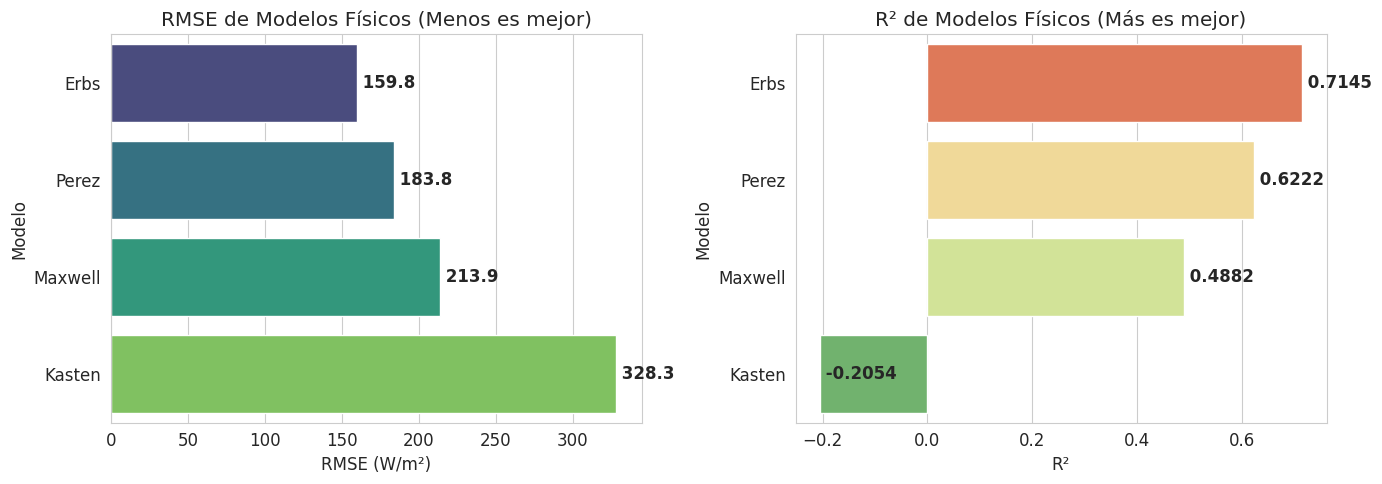

CONCLUSIÓN: El modelo de **Erbs** se establece como la referencia oficial.


In [20]:
print("--- EVALUANDO RENDIMIENTO DE MODELOS FÍSICOS ---")

# Identificar qué modelos se han calculado
cols_dni_fisicos = [c for c in df_models.columns if c.startswith('DNI_') and c != 'DNI']

results = []
for col in cols_dni_fisicos:
    nombre = col.replace('DNI_', '').capitalize()

    # Filtrar NaN y Noche
    mask = (df_models['DNI'] > 0) & (df_models[col].notna())

    rmse = np.sqrt(mean_squared_error(df_models.loc[mask, 'DNI'], df_models.loc[mask, col]))
    mae = mean_absolute_error(df_models.loc[mask, 'DNI'], df_models.loc[mask, col])
    r2 = r2_score(df_models.loc[mask, 'DNI'], df_models.loc[mask, col])

    results.append({'Modelo': nombre, 'RMSE (W/m²)': rmse, 'MAE (W/m²)': mae, 'R²': r2})

# Crear Ranking
df_rank = pd.DataFrame(results).sort_values('RMSE (W/m²)')

print("\n RANKING DE MODELOS FÍSICOS (DNI)")
display(df_rank.style.background_gradient(cmap='RdYlGn_r', subset=['RMSE (W/m²)', 'MAE (W/m²)'])
                      .background_gradient(cmap='RdYlGn', subset=['R²'])
                      .format({'RMSE (W/m²)': '{:.2f}', 'MAE (W/m²)': '{:.2f}', 'R²': '{:.4f}'}))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_rank, x='RMSE (W/m²)', y='Modelo', palette='viridis', ax=axes[0])
axes[0].set_title('RMSE de Modelos Físicos (Menos es mejor)')
for i, v in enumerate(df_rank['RMSE (W/m²)']):
    axes[0].text(v, i, f' {v:.1f}', va='center', fontweight='bold')

sns.barplot(data=df_rank, x='R²', y='Modelo', palette='RdYlGn', ax=axes[1])
axes[1].set_title('R² de Modelos Físicos (Más es mejor)')
for i, v in enumerate(df_rank['R²']):
    axes[1].text(v, i, f' {v:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"CONCLUSIÓN: El modelo de **{df_rank.iloc[0]['Modelo']}** se establece como la referencia oficial.")

# 5. Preparación e Implementacion de los Modelos Automáticos

## División del Dataset: Entrenamiento y Prueba

Para evaluar la capacidad de generalización y extrapolación de los modelos, se dividirá el dataset en conjuntos de entrenamiento y prueba basados en las ubicaciones geográficas, según la estrategia definida en la sección 5.1.

* **Conjunto de Entrenamiento:** Incluirá datos de ciudades con alta estabilidad radiativa (Almería y Santa Cruz de Tenerife).
* **Conjunto de Prueba/Extrapolación:** Incluirá datos de ciudades con condiciones climáticas más variables y no vistas durante el entrenamiento (Galway, Grenoble, Milán y Viena).

Este enfoque nos permitirá entrenar los modelos de aprendizaje automático en un conjunto de datos "ideal" y luego evaluar tanto los modelos físicos como los de ML en una variedad de contextos climáticos.

In [21]:
# Definición de Ciudades para Entrenamiento y Prueba

# Ciudades para el conjunto de entrenamiento (condiciones más estables y despejadas)
train_cities = ['Almería', 'Santa Cruz de Tenerife']

# Ciudades para el conjunto de prueba/extrapolación (condiciones más variables)
test_cities = ['Galway', 'Grenoble', 'Milán', 'Viena'] # Asegúrate de que todas estas ciudades se hayan cargado correctamente.

In [22]:
# Creación de los DataFrames de Entrenamiento y Prueba
# IMPORTANTE: Usamos 'df_models' porque contiene las columnas 'DNI_erbs', 'DHI_perez', etc.
# Si usamos 'df', perdemos esas predicciones clásicas y no podremos comparar después.

# Conjunto de entrenamiento: Filtrar df_models por las ciudades de entrenamiento.
df_train = df_models[df_models['Ciudad'].isin(train_cities)].copy()

# Conjunto de prueba: Filtrar df_models por las ciudades de prueba.
df_test = df_models[df_models['Ciudad'].isin(test_cities)].copy()

print(f"Dimensiones del DataFrame de Entrenamiento: {df_train.shape}")
print(f"Ciudades en el DataFrame de Entrenamiento: {df_train['Ciudad'].unique()}")
print("-" * 50)
print(f"Dimensiones del DataFrame de Prueba: {df_test.shape}")
print(f"Ciudades en el DataFrame de Prueba: {df_test['Ciudad'].unique()}")

# Verificación rápida de seguridad (opcional, para que te quedes tranquilo):
if 'DNI_erbs' in df_test.columns:
    print("\n[OK] Las columnas de modelos físicos (ej. DNI_erbs) están presentes en el conjunto de prueba.")
else:
    print("\n[ERROR] Faltan las columnas de modelos físicos. Revisa si ejecutaste la celda donde creaste df_models.")

Dimensiones del DataFrame de Entrenamiento: (8719, 47)
Ciudades en el DataFrame de Entrenamiento: ['Almería' 'Santa Cruz de Tenerife']
--------------------------------------------------
Dimensiones del DataFrame de Prueba: (17471, 47)
Ciudades en el DataFrame de Prueba: ['Galway' 'Grenoble' 'Milán' 'Viena']

[OK] Las columnas de modelos físicos (ej. DNI_erbs) están presentes en el conjunto de prueba.


In [23]:
 # 8.3. Preparación de X (features) e y (targets) para Modelado

# Definir la lista de todas las características (features) que se usarán en los modelos.
# Aquí se incluyen las características cíclicas que ya han sido añadidas al DataFrame 'df'.
# Se excluyen las variables objetivo ('DHI', 'DNI') y variables como 'Ciudad' que se usan para agrupación/división,
# así como 'Year', 'Month', 'Day', 'Hour', 'Minute' si ya se usaron para crear las cíclicas y 'datetime' es el índice.
features_list = [
    'GHI', 'Temperature', 'Relative Humidity', 'Solar Zenith Angle',
    'Aerosol Optical Depth', 'Ozone', 'Pressure_Pa', 'Wind Speed', # Aseguramos Pressure_Pa si fue creada
    'Wind Direction', 'Precipitable Water', 'Kt',
    'hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos',
    'month_sin', 'month_cos'
]

# Asegurar que solo las columnas realmente disponibles en df_train (y por lo tanto en df_test) se usen como features.
# Esto previene errores si alguna columna de features_list no estuviera presente.
X_cols = [col for col in features_list if col in df_train.columns]

# Separar features (X) y targets (y) para el entrenamiento
X_train = df_train[X_cols]
y_train_dhi = df_train['DHI']
y_train_dni = df_train['DNI']

# Separar features (X) y targets (y) para la prueba
X_test = df_test[X_cols]
y_test_dhi = df_test['DHI']
y_test_dni = df_test['DNI']

print("\nPrimeras 5 filas de X_train (Features para entrenamiento):")
print(X_train.head())
print("\nPrimeras 5 filas de y_train_dhi (Target DHI para entrenamiento):")
print(y_train_dhi.head())
print("\nPrimeras 5 filas de X_test (Features para prueba):")
print(X_test.head())


Primeras 5 filas de X_train (Features para entrenamiento):
   GHI  Temperature  Relative Humidity  Solar Zenith Angle  \
0  158         16.3              37.56               79.57   
1  115         18.2              35.71               71.10   
2  271         19.7              30.29               64.58   
3  516         20.9              28.02               60.69   
4  344         21.5              27.12               59.95   

   Aerosol Optical Depth  Ozone  Wind Speed  Wind Direction  \
0                 0.0270  0.288         0.9             252   
1                 0.0275  0.286         1.4             233   
2                 0.0281  0.284         1.9             220   
3                 0.0284  0.282         2.2             217   
4                 0.0338  0.279         2.3             219   

   Precipitable Water        Kt      hour_sin  hour_cos  day_of_year_sin  \
0                 0.8  1.000000  7.071068e-01 -0.707107         0.017213   
1                 0.8  0.360502  5.0

In [24]:
print("\nCiudades únicas en df_test después de la división:")
print(df_test['Ciudad'].unique())


Ciudades únicas en df_test después de la división:
['Galway' 'Grenoble' 'Milán' 'Viena']


### 1. Regresión Lineal con Regularización (Ridge)

Como punto de partida para el aprendizaje automático, se implementa un modelo lineal. Dado que las variables meteorológicas presentan una alta multicolinealidad (por ejemplo, la correlación entre GHI y el Ángulo Cenital), una regresión lineal simple por mínimos cuadrados ordinarios podría generar coeficientes inestables.

Para mitigar esto, se utiliza **Regresión Ridge (Regularización L2)**. Este método penaliza la magnitud de los coeficientes, reduciendo la varianza del modelo y mejorando su capacidad de generalización. Además, se incluye un paso previo de estandarización (`StandardScaler`) dentro de un *pipeline* para asegurar que todas las variables tengan el mismo peso durante el ajuste.

In [25]:
print("--- ENTRENANDO REGRESIÓN LINEAL (RIDGE) ---")

# 1. Configuración del Pipeline
# Escalamiento + Modelo Ridge (alpha=1.0 es el estándar)
model_pipeline_dni = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
model_pipeline_dhi = make_pipeline(StandardScaler(), Ridge(alpha=1.0))

# 2. Entrenamiento (Fitting)
model_pipeline_dni.fit(X_train, y_train_dni)
model_pipeline_dhi.fit(X_train, y_train_dhi)

# 3. Predicciones
# El pipeline escala automáticamente los datos de test usando la media/std del train
y_pred_dni_lr = model_pipeline_dni.predict(X_test)
y_pred_dhi_lr = model_pipeline_dhi.predict(X_test)

# 4. Post-procesamiento (Física Básica)
# La radiación solar no puede ser negativa. Corregimos valores < 0.
y_pred_dni_lr = np.clip(y_pred_dni_lr, 0, None)
y_pred_dhi_lr = np.clip(y_pred_dhi_lr, 0, None)

# 5. Guardado de Resultados
df_test['DNI_pred_Linear'] = y_pred_dni_lr
df_test['DHI_pred_Linear'] = y_pred_dhi_lr

# 6. Evaluación de Métricas
rmse_dni = np.sqrt(mean_squared_error(y_test_dni, y_pred_dni_lr))
mae_dni = mean_absolute_error(y_test_dni, y_pred_dni_lr)
rmse_dhi = np.sqrt(mean_squared_error(y_test_dhi, y_pred_dhi_lr))

print(f"\n RESULTADOS: Regresión Lineal (Baseline)")
print(f"   DNI -> RMSE: {rmse_dni:.2f} W/m² | MAE: {mae_dni:.2f} W/m²")
print(f"   DHI -> RMSE: {rmse_dhi:.2f} W/m²")

--- ENTRENANDO REGRESIÓN LINEAL (RIDGE) ---

 RESULTADOS: Regresión Lineal (Baseline)
   DNI -> RMSE: 139.11 W/m² | MAE: 103.12 W/m²
   DHI -> RMSE: 87.55 W/m²


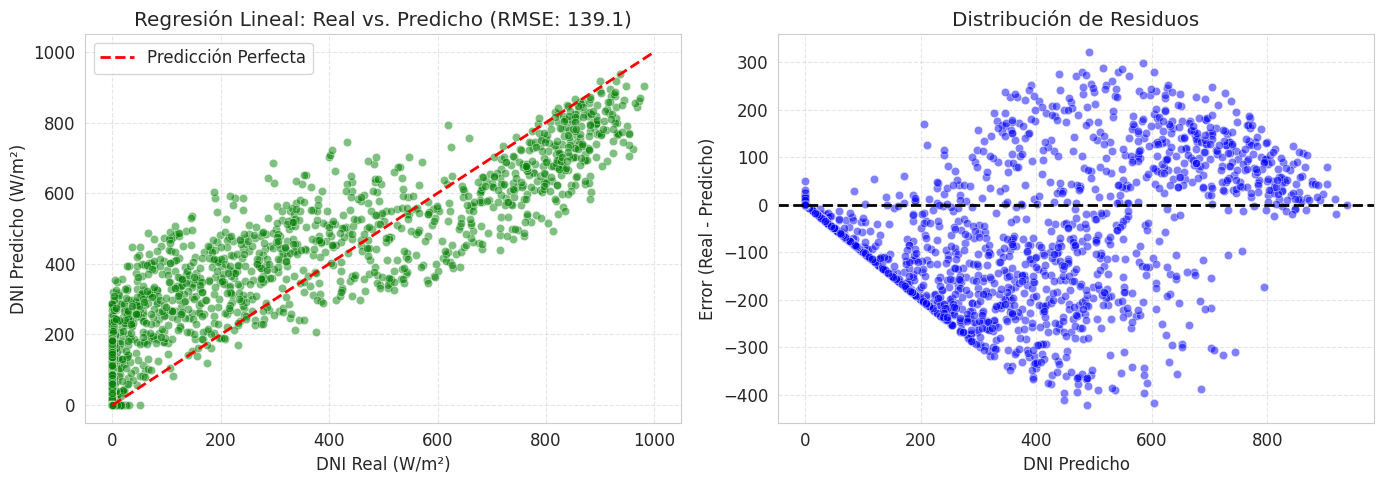

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Selección de muestra para no saturar el gráfico (2000 puntos)
idx = np.random.choice(len(y_test_dni), size=min(2000, len(y_test_dni)), replace=False)
y_real_s = y_test_dni.iloc[idx]
y_pred_s = y_pred_dni_lr[idx]

# Gráfico A: Real vs Predicho
sns.scatterplot(x=y_real_s, y=y_pred_s, ax=axes[0], alpha=0.5, color='green')
axes[0].plot([0, 1000], [0, 1000], 'r--', lw=2, label='Predicción Perfecta')
axes[0].set_title(f'Regresión Lineal: Real vs. Predicho (RMSE: {rmse_dni:.1f})')
axes[0].set_xlabel('DNI Real (W/m²)')
axes[0].set_ylabel('DNI Predicho (W/m²)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Gráfico B: Residuos
residuos = y_real_s - y_pred_s
sns.scatterplot(x=y_pred_s, y=residuos, ax=axes[1], alpha=0.5, color='blue')
axes[1].axhline(0, color='black', linestyle='--', lw=2)
axes[1].set_title('Distribución de Residuos')
axes[1].set_xlabel('DNI Predicho')
axes[1].set_ylabel('Error (Real - Predicho)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 2. Random Forest Regressor

Para superar las limitaciones de la linealidad, se utiliza **Random Forest**, un algoritmo de ensamble basado en el embolsado (*bagging*) de árboles de decisión.

**Justificación de su elección:**
1.  **No linealidad:** Capaz de capturar patrones complejos (como la caída brusca de DNI con nubes) sin necesidad de transformar las variables.
2.  **Robustez:** Al promediar cientos de árboles, reduce la varianza y es menos sensible al ruido (*outliers*) que un árbol de decisión único.
3.  **Interpretabilidad:** Permite extraer la "Importancia de las Características" (*Feature Importance*), ayudando a entender qué variables físicas dominan la predicción.

Se aplica una búsqueda aleatoria de hiperparámetros (`RandomizedSearchCV`) para optimizar la profundidad de los árboles y el número de estimadores, equilibrando precisión y coste computacional.

*Nota de implementación: Dado que los árboles de decisión operan mediante reglas de partición jerárquicas y no mediante distancias euclídeas, este algoritmo no requiere estrictamente la estandarización de las variables (`StandardScaler`), lo que facilita la interpretación directa de los cortes en las unidades originales.*

In [27]:
print("--- DEFINICIÓN Y OPTIMIZACIÓN (RANDOM FOREST) ---")

# 1. Definición del Espacio de Búsqueda
# Random Forest es robusto, pero ajustar la profundidad evita el overfitting.
param_dist_rf = {
    'n_estimators': [100, 200],            # Número de árboles (más es mejor, pero más lento)
    'max_depth': [10, 20, 30, None],       # Profundidad máxima del árbol
    'min_samples_split': [2, 5, 10],       # Mínimo de muestras para dividir un nodo
    'max_features': ['sqrt', 'log2', None] # Variables a considerar en cada división
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# 2. Optimización para DNI (Variable Crítica)
print(" Optimizando hiperparámetros para DNI (Directa)...")
search_rf_dni = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=10,  # Probamos 10 combinaciones para agilizar
    cv=3,       # Validación cruzada de 3 pliegues
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring='neg_mean_squared_error'
)
search_rf_dni.fit(X_train, y_train_dni) # Entrenamos con datos sin escalar (es válido para RF)
best_rf_dni = search_rf_dni.best_estimator_
print(f" Mejores parámetros RF (DNI): {search_rf_dni.best_params_}")

# 3. Optimización para DHI (Variable Difusa)
print("\n Optimizando hiperparámetros para DHI (Difusa)...")
search_rf_dhi = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=5,
    cv=3,
    verbose=0,
    random_state=42,
    n_jobs=-1,
    scoring='neg_mean_squared_error'
)
search_rf_dhi.fit(X_train, y_train_dhi)
best_rf_dhi = search_rf_dhi.best_estimator_
print(f" Mejores parámetros RF (DHI): {search_rf_dhi.best_params_}")

# 4. Predicciones en Test
print("\n--- PREDICCIÓN Y GUARDADO ---")
y_pred_dni_rf = best_rf_dni.predict(X_test)
y_pred_dhi_rf = best_rf_dhi.predict(X_test)

# Guardar resultados
df_test['DNI_pred_RF'] = y_pred_dni_rf
df_test['DHI_pred_RF'] = y_pred_dhi_rf

# 5. Evaluación de Métricas
rmse_dni_rf = np.sqrt(mean_squared_error(y_test_dni, y_pred_dni_rf))
mae_dni_rf = mean_absolute_error(y_test_dni, y_pred_dni_rf)
rmse_dhi_rf = np.sqrt(mean_squared_error(y_test_dhi, y_pred_dhi_rf))

print(f" RESULTADOS: Random Forest")
print(f"   DNI -> RMSE: {rmse_dni_rf:.2f} W/m² | MAE: {mae_dni_rf:.2f} W/m²")
print(f"   DHI -> RMSE: {rmse_dhi_rf:.2f} W/m²")

# Comparativa rápida con Baseline (Lineal)
if 'rmse_dni' in locals(): # rmse_dni era el del modelo lineal
    mejora = rmse_dni - rmse_dni_rf
    print(f"   Mejora respecto a Regresión Lineal: {mejora:.2f} W/m²")

--- DEFINICIÓN Y OPTIMIZACIÓN (RANDOM FOREST) ---
 Optimizando hiperparámetros para DNI (Directa)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
 Mejores parámetros RF (DNI): {'n_estimators': 100, 'min_samples_split': 5, 'max_features': None, 'max_depth': 30}

 Optimizando hiperparámetros para DHI (Difusa)...
 Mejores parámetros RF (DHI): {'n_estimators': 100, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 20}

--- PREDICCIÓN Y GUARDADO ---
 RESULTADOS: Random Forest
   DNI -> RMSE: 45.01 W/m² | MAE: 30.32 W/m²
   DHI -> RMSE: 19.73 W/m²
   Mejora respecto a Regresión Lineal: 94.10 W/m²


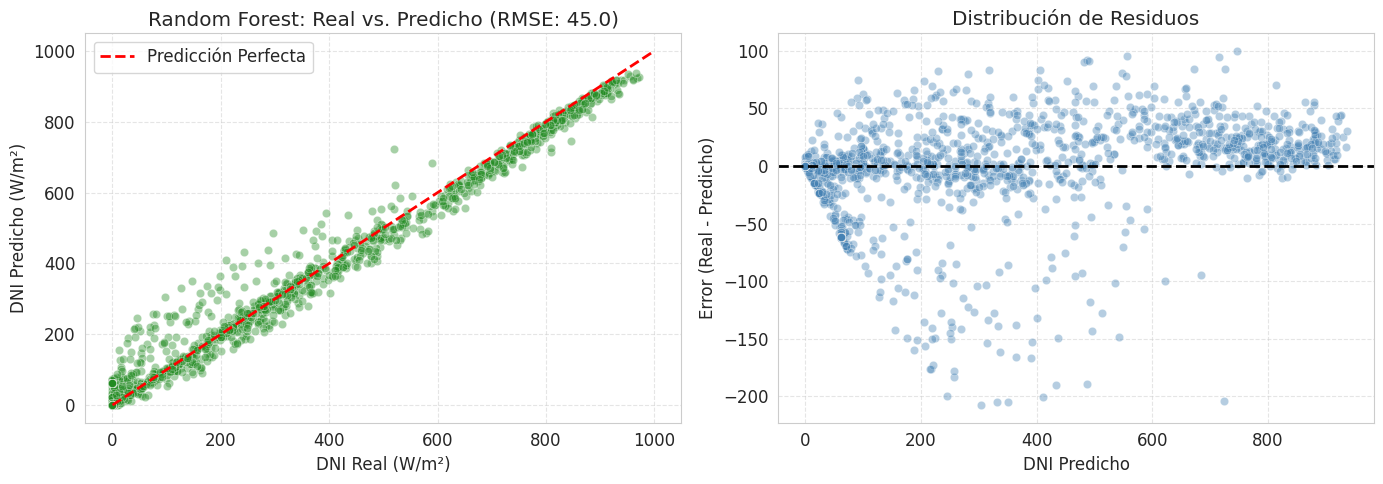

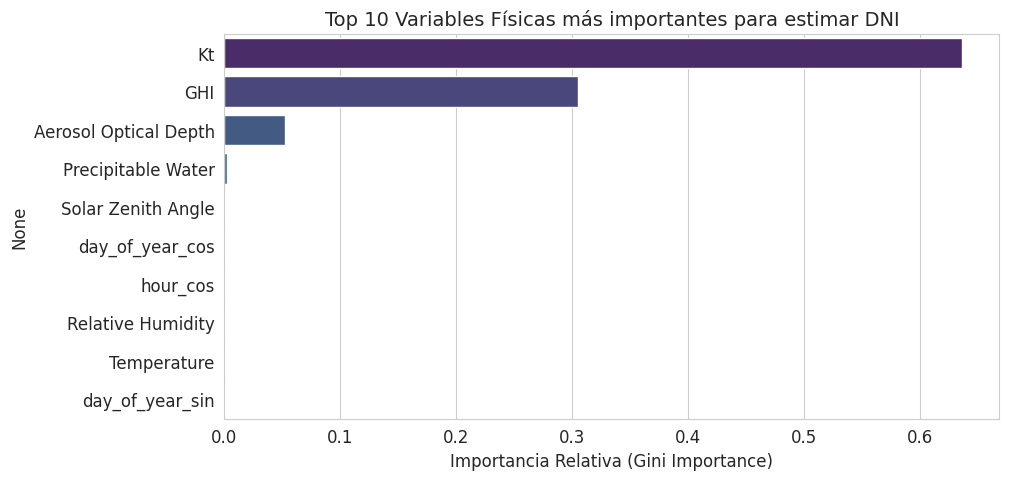

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Muestra para no saturar el gráfico
idx = np.random.choice(len(y_test_dni), size=min(2000, len(y_test_dni)), replace=False)
y_real_s = y_test_dni.iloc[idx]
y_pred_s = y_pred_dni_rf[idx]

# Gráfico A: Real vs Predicho
sns.scatterplot(x=y_real_s, y=y_pred_s, ax=axes[0], alpha=0.4, color='forestgreen')
axes[0].plot([0, 1000], [0, 1000], 'r--', lw=2, label='Predicción Perfecta')
axes[0].set_title(f'Random Forest: Real vs. Predicho (RMSE: {rmse_dni_rf:.1f})')
axes[0].set_xlabel('DNI Real (W/m²)')
axes[0].set_ylabel('DNI Predicho (W/m²)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Gráfico B: Residuos
residuos = y_real_s - y_pred_s
sns.scatterplot(x=y_pred_s, y=residuos, ax=axes[1], alpha=0.4, color='steelblue')
axes[1].axhline(0, color='black', linestyle='--', lw=2)
axes[1].set_title('Distribución de Residuos')
axes[1].set_xlabel('DNI Predicho')
axes[1].set_ylabel('Error (Real - Predicho)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# --- EXTRA: IMPORTANCIA DE VARIABLES (Valor añadido de RF) ---
plt.figure(figsize=(10, 5))
importances = best_rf_dni.feature_importances_
feat_names = X_train.columns
indices = np.argsort(importances)[::-1]

# Top 10 variables
top_n = min(10, len(feat_names))
sns.barplot(x=importances[indices[:top_n]], y=feat_names[indices[:top_n]], palette="viridis")
plt.title('Top 10 Variables Físicas más importantes para estimar DNI', fontsize=14)
plt.xlabel('Importancia Relativa (Gini Importance)')
plt.show()

### 3. Support Vector Regressor (SVR)

Support Vector Regressor (SVR) es una extensión de las Máquinas de Vectores de Soporte (SVM) para tareas de regresión. Busca encontrar un hiperplano óptimo que se ajuste a los datos con un margen de error máximo $\epsilon$ (épsilon), lo que lo hace robusto a *outliers*.

**Justificación de su elección:**
1.  **Robustez (Margen $\epsilon$):** Al ignorar los errores que caen dentro del margen de tolerancia $\epsilon$, el modelo se centra en la tendencia general y no se deja arrastrar por el ruido de mediciones puntuales.
2.  **No Linealidad (Kernel Trick):** Mediante el uso del kernel RBF (Radial Basis Function), proyecta los datos a dimensiones superiores para resolver relaciones físicas complejas que no son linealmente separables.
3.  **Necesidad de Escalado:** Al ser un algoritmo basado en distancias geométricas, es **crítico** estandarizar las variables (`StandardScaler`) para evitar que aquellas con mayor magnitud (como la radiación) dominen sobre las pequeñas (como la temperatura).

*Nota de implementación: Debido a la complejidad computacional cúbica $O(N^3)$ de SVR, la búsqueda de hiperparámetros se realiza sobre un subconjunto representativo de los datos para mantener tiempos de ejecución viables.*

In [29]:
print("--- ESCALADO DE DATOS (CRÍTICO PARA SVR) ---")
# SVR basa sus cálculos en distancias. Estandarizamos a media 0 y desviación 1.
scaler_X = StandardScaler()

# Ajustamos SOLO con Train para evitar data leakage
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

print(" Datos escalados correctamente.")

# 1. DEFINICIÓN DEL ESPACIO DE BÚSQUEDA
# Probamos C altos (porque Y es grande) y epsilons reales.
param_dist_svr = {
    'C': [10, 100, 1000],          # Regularización
    'gamma': ['scale', 'auto', 0.1], # Radio de influencia del kernel
    'epsilon': [5, 10, 20]         # Margen de tolerancia (W/m²)
}

svr_base = SVR(kernel='rbf', cache_size=1000)

# 2. OPTIMIZACIÓN "SMART" PARA DNI
print("\n Iniciando optimización de SVR para DNI...")
print("(Usando subset de 5000 muestras para agilizar la búsqueda)")

# Truco: Optimizamos en una muestra, entrenamos en todo.
sample_size = min(5000, len(X_train))
indices_sample = np.random.choice(len(X_train), sample_size, replace=False)
X_train_sample = X_train_scaled[indices_sample]
y_train_sample = y_train_dni.iloc[indices_sample] if hasattr(y_train_dni, 'iloc') else y_train_dni[indices_sample]

search_svr_dni = RandomizedSearchCV(
    estimator=svr_base,
    param_distributions=param_dist_svr,
    n_iter=5,  # Pocas iteraciones porque es lento
    cv=3,
    verbose=1,
    n_jobs=-1,
    scoring='neg_mean_squared_error',
    random_state=42
)

search_svr_dni.fit(X_train_sample, y_train_sample)
best_svr_dni = search_svr_dni.best_estimator_
print(f" Mejores parámetros DNI: {search_svr_dni.best_params_}")

# RE-ENTRENAMIENTO FINAL (FULL DATASET)
print(" Re-entrenando el mejor modelo con TODOS los datos (puede tardar un poco)...")
best_svr_dni.fit(X_train_scaled, y_train_dni)


# 3. CONFIGURACIÓN PARA DHI (DIFUSA)
print("\nConfigurando SVR para DHI (Configuración robusta manual)...")
# Para DHI usamos una config estándar robusta para ahorrar tiempo
best_svr_dhi = SVR(kernel='rbf', C=100, epsilon=10, gamma='scale', cache_size=1000)
best_svr_dhi.fit(X_train_scaled, y_train_dhi)


# 4. PREDICCIÓN Y EVALUACIÓN
print("\n--- EVALUACIÓN EN TEST ---")
y_pred_dni_svr = np.clip(best_svr_dni.predict(X_test_scaled), 0, None)
y_pred_dhi_svr = np.clip(best_svr_dhi.predict(X_test_scaled), 0, None)

# Guardar en df_test
df_test['DNI_pred_SVR'] = y_pred_dni_svr
df_test['DHI_pred_SVR'] = y_pred_dhi_svr

# Métricas
rmse_dni_svr = np.sqrt(mean_squared_error(y_test_dni, y_pred_dni_svr))
mae_dni_svr = mean_absolute_error(y_test_dni, y_pred_dni_svr)
rmse_dhi_svr = np.sqrt(mean_squared_error(y_test_dhi, y_pred_dhi_svr))

print(f"DNI (SVR) -> RMSE: {rmse_dni_svr:.2f} W/m² | MAE: {mae_dni_svr:.2f} W/m²")
print(f"DHI (SVR) -> RMSE: {rmse_dhi_svr:.2f} W/m²")

--- ESCALADO DE DATOS (CRÍTICO PARA SVR) ---
 Datos escalados correctamente.

 Iniciando optimización de SVR para DNI...
(Usando subset de 5000 muestras para agilizar la búsqueda)
Fitting 3 folds for each of 5 candidates, totalling 15 fits
 Mejores parámetros DNI: {'gamma': 'scale', 'epsilon': 10, 'C': 1000}
 Re-entrenando el mejor modelo con TODOS los datos (puede tardar un poco)...

Configurando SVR para DHI (Configuración robusta manual)...

--- EVALUACIÓN EN TEST ---
DNI (SVR) -> RMSE: 88.95 W/m² | MAE: 66.96 W/m²
DHI (SVR) -> RMSE: 32.91 W/m²


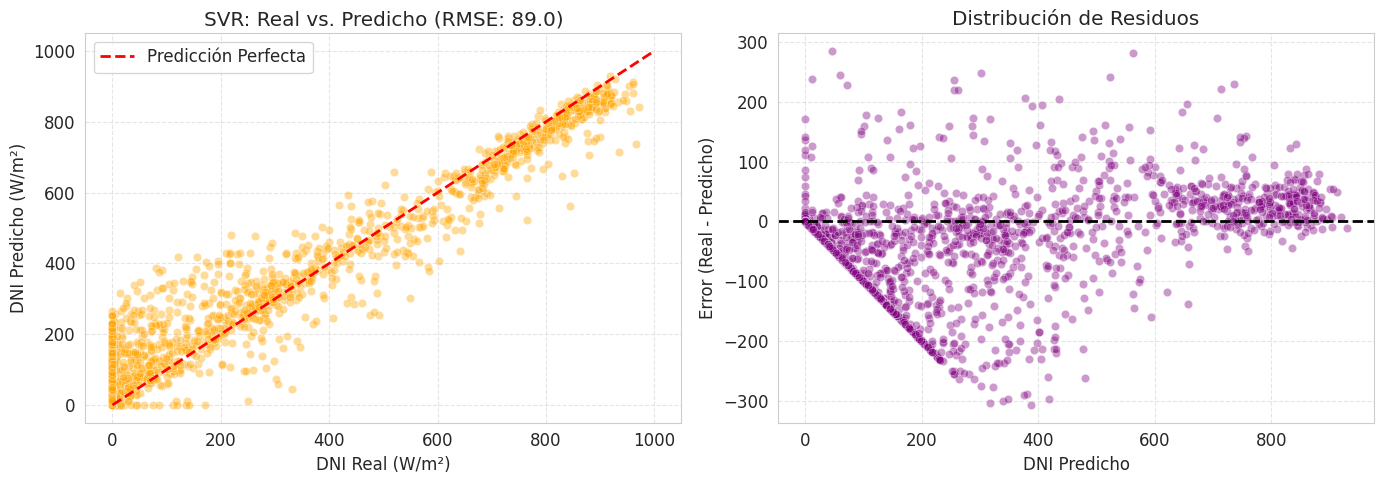


Comparativa: Diferencia con Random Forest: -43.94 W/m²


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Muestra para visualización
idx = np.random.choice(len(y_test_dni), size=min(2000, len(y_test_dni)), replace=False)
y_real_s = y_test_dni.iloc[idx]
y_pred_s = y_pred_dni_svr[idx]

# Gráfico 1: Real vs Predicho
sns.scatterplot(x=y_real_s, y=y_pred_s, ax=axes[0], alpha=0.4, color='orange')
axes[0].plot([0, 1000], [0, 1000], 'r--', lw=2, label='Predicción Perfecta')
axes[0].set_title(f'SVR: Real vs. Predicho (RMSE: {rmse_dni_svr:.1f})')
axes[0].set_xlabel('DNI Real (W/m²)')
axes[0].set_ylabel('DNI Predicho (W/m²)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Gráfico 2: Residuos
residuos = y_real_s - y_pred_s
sns.scatterplot(x=y_pred_s, y=residuos, ax=axes[1], alpha=0.4, color='purple')
axes[1].axhline(0, color='black', linestyle='--', lw=2)
axes[1].set_title('Distribución de Residuos')
axes[1].set_xlabel('DNI Predicho')
axes[1].set_ylabel('Error (Real - Predicho)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Comparativa rápida
if 'rmse_dni_rf' in locals():
    diff = rmse_dni_rf - rmse_dni_svr
    print(f"\nComparativa: Diferencia con Random Forest: {diff:.2f} W/m²")

### 4. Gradient Boosting Regressor (GBR)

Continuando con las estrategias de ensamble, se implementa **Gradient Boosting**. A diferencia de Random Forest, que construye árboles independientes en paralelo (*Bagging*), este algoritmo construye árboles de forma secuencial (*Boosting*).

**Justificación de su elección:**
1.  **Corrección Secuencial de Errores:** Cada nuevo árbol se entrena específicamente para minimizar el error residual (la diferencia entre la realidad y la predicción) del árbol anterior. Esto permite reducir el sesgo (*bias*) de forma muy efectiva.
2.  **Eficiencia y Precisión:** Suele requerir árboles menos profundos que Random Forest, lo que resulta en modelos más ligeros. Es considerado el "estado del arte" para datos tabulares cuando se busca la máxima precisión.
3.  **Gestión de Variables:** Al igual que Random Forest, permite identificar qué variables físicas son las más relevantes, pero con un enfoque más discriminativo debido a su naturaleza iterativa.

*Nota de implementación: GBR es propenso al sobreajuste si se entrena con demasiados árboles o una tasa de aprendizaje muy alta. Se aplica una optimización rigurosa de hiperparámetros (`learning_rate`, `subsample`) para garantizar la generalización.*

In [31]:
print("--- DEFINICIÓN DEL ESPACIO DE BÚSQUEDA ---")
# GBR es sensible. Buscamos el equilibrio entre aprender lento (learning_rate bajo)
# y tener suficientes árboles (n_estimators alto).
param_dist_gb = {
    'n_estimators': [100, 200, 300],         # Etapas de boosting
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # Velocidad de corrección
    'max_depth': [3, 4, 5, 6],               # Profundidad (GBR prefiere árboles cortos)
    'subsample': [0.8, 0.9, 1.0],            # Stochastic GB (evita overfitting)
    'min_samples_leaf': [1, 2, 4]            # Regularización en hojas
}

gb_base = GradientBoostingRegressor(random_state=42)

# 1. OPTIMIZACIÓN PARA DNI (CRÍTICO)
print(" Iniciando optimización de Gradient Boosting para DNI...")
search_gb_dni = RandomizedSearchCV(
    estimator=gb_base,
    param_distributions=param_dist_gb,
    n_iter=15,       # 15 combinaciones
    cv=3,            # Validación cruzada
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring='neg_mean_squared_error'
)

search_gb_dni.fit(X_train, y_train_dni)
best_gb_dni = search_gb_dni.best_estimator_
print(f" Mejores parámetros DNI: {search_gb_dni.best_params_}")


# 2. ENTRENAMIENTO PARA DHI (DIFUSA)
print("\n Entrenando Gradient Boosting para DHI...")
# Usamos la misma búsqueda para DHI (reducida para agilizar)
search_gb_dhi = RandomizedSearchCV(
    estimator=gb_base,
    param_distributions=param_dist_gb,
    n_iter=5,
    cv=3,
    verbose=0,
    random_state=42,
    n_jobs=-1,
    scoring='neg_mean_squared_error'
)
search_gb_dhi.fit(X_train, y_train_dhi)
best_gb_dhi = search_gb_dhi.best_estimator_
print(f" Mejores parámetros DHI: {search_gb_dhi.best_params_}")


# 3. EVALUACIÓN Y MÉTRICAS
print("\n--- RESULTADOS GRADIENT BOOSTING ---")

y_pred_dni_gb = best_gb_dni.predict(X_test)
y_pred_dhi_gb = best_gb_dhi.predict(X_test)

# Corregir negativos (Física básica)
y_pred_dni_gb = np.clip(y_pred_dni_gb, 0, None)
y_pred_dhi_gb = np.clip(y_pred_dhi_gb, 0, None)

# Guardar en df_test
df_test['DNI_pred_GBR'] = y_pred_dni_gb
df_test['DHI_pred_GBR'] = y_pred_dhi_gb

# Métricas
rmse_gb_dni = np.sqrt(mean_squared_error(y_test_dni, y_pred_dni_gb))
mae_gb_dni = mean_absolute_error(y_test_dni, y_pred_dni_gb)
rmse_gb_dhi = np.sqrt(mean_squared_error(y_test_dhi, y_pred_dhi_gb))

print(f"DNI (GBR) -> RMSE: {rmse_gb_dni:.2f} W/m² | MAE: {mae_gb_dni:.2f} W/m²")
print(f"DHI (GBR) -> RMSE: {rmse_gb_dhi:.2f} W/m²")

--- DEFINICIÓN DEL ESPACIO DE BÚSQUEDA ---
 Iniciando optimización de Gradient Boosting para DNI...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
 Mejores parámetros DNI: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_leaf': 1, 'max_depth': 6, 'learning_rate': 0.05}

 Entrenando Gradient Boosting para DHI...
 Mejores parámetros DHI: {'subsample': 0.9, 'n_estimators': 100, 'min_samples_leaf': 4, 'max_depth': 6, 'learning_rate': 0.2}

--- RESULTADOS GRADIENT BOOSTING ---
DNI (GBR) -> RMSE: 50.54 W/m² | MAE: 32.68 W/m²
DHI (GBR) -> RMSE: 15.78 W/m²


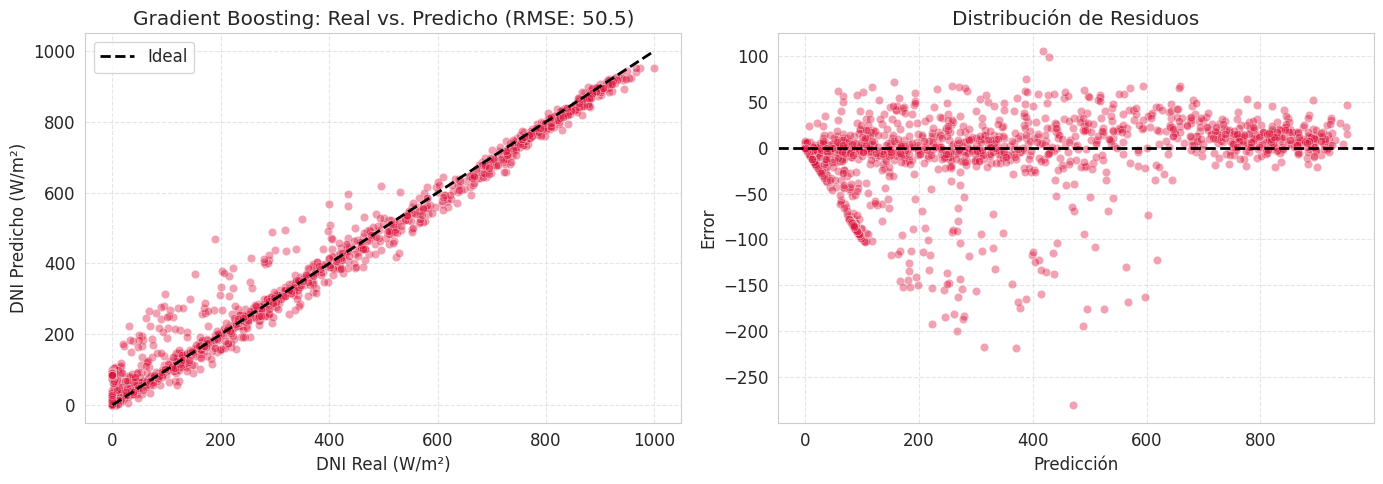

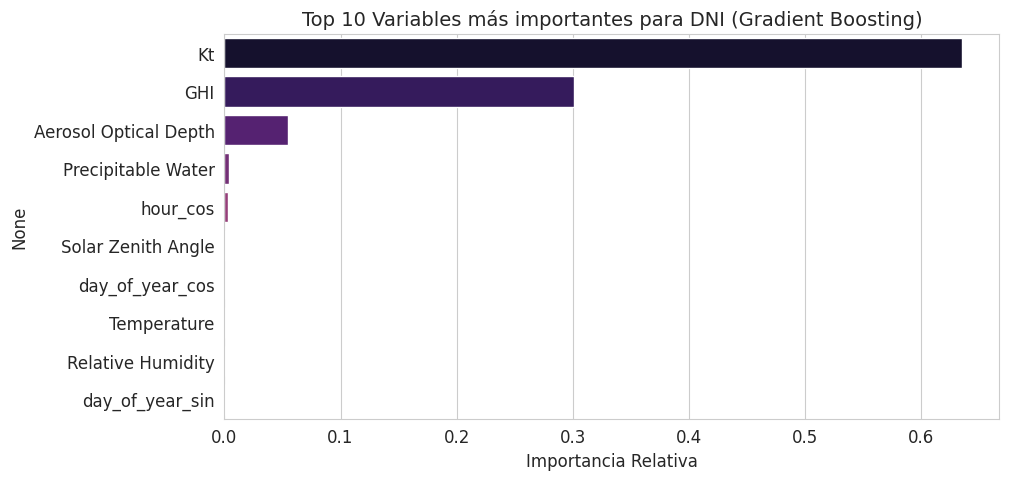


[Diagnóstico Overfitting] RMSE Train: 4.5 vs Test: 50.5
Diferencia (Gap): 46.1 W/m²
Atención: El modelo muestra cierto sobreajuste.

 ¡LÍDER! Gradient Boosting supera a SVR en 38.41 W/m².


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Muestra aleatoria
idx = np.random.choice(len(y_test_dni), size=min(2000, len(y_test_dni)), replace=False)
y_real_s = y_test_dni.iloc[idx]
y_pred_s = y_pred_dni_gb[idx]

# Gráfico A: Real vs Predicho
sns.scatterplot(x=y_real_s, y=y_pred_s, ax=axes[0], alpha=0.4, color='crimson')
axes[0].plot([0, 1000], [0, 1000], 'k--', lw=2, label='Ideal')
axes[0].set_title(f'Gradient Boosting: Real vs. Predicho (RMSE: {rmse_gb_dni:.1f})')
axes[0].set_xlabel('DNI Real (W/m²)')
axes[0].set_ylabel('DNI Predicho (W/m²)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Gráfico B: Residuos
residuos = y_real_s - y_pred_s
sns.scatterplot(x=y_pred_s, y=residuos, ax=axes[1], alpha=0.4, color='crimson')
axes[1].axhline(0, color='black', linestyle='--', lw=2)
axes[1].set_title('Distribución de Residuos')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Error')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ANÁLISIS DE IMPORTANCIA DE VARIABLES (Valor añadido de GBR)
plt.figure(figsize=(10, 5))
importances = best_gb_dni.feature_importances_
# Corrección: Usamos X_train.columns
feat_names = X_train.columns
indices = np.argsort(importances)[::-1]

top_n = min(10, len(feat_names))
sns.barplot(x=importances[indices[:top_n]], y=feat_names[indices[:top_n]], palette="magma")
plt.title('Top 10 Variables más importantes para DNI (Gradient Boosting)', fontsize=14)
plt.xlabel('Importancia Relativa')
plt.show()

# DIAGNÓSTICO DE OVERFITTING
rmse_train = np.sqrt(mean_squared_error(y_train_dni, best_gb_dni.predict(X_train)))
gap = rmse_gb_dni - rmse_train

print(f"\n[Diagnóstico Overfitting] RMSE Train: {rmse_train:.1f} vs Test: {rmse_gb_dni:.1f}")
print(f"Diferencia (Gap): {gap:.1f} W/m²")

if gap > 25:
    print("Atención: El modelo muestra cierto sobreajuste.")
else:
    print("El modelo generaliza correctamente.")

# Comparativa con el modelo anterior (SVR o RF)
if 'rmse_dni_svr' in locals():
    diff = rmse_dni_svr - rmse_gb_dni
    if diff > 0:
        print(f"\n ¡LÍDER! Gradient Boosting supera a SVR en {diff:.2f} W/m².")
    else:
        print(f"\n Gradient Boosting es similar a SVR (Diferencia: {diff:.2f}).")
elif 'rmse_dni_rf' in locals():
    diff = rmse_dni_rf - rmse_gb_dni
    print(f"\nComparativa: Diferencia con Random Forest: {diff:.2f} W/m²")

### 5. Redes Neuronales Artificiales (MLP Regressor)

Las Redes Neuronales Artificiales (RNA), específicamente los **Perceptrones Multicapa (MLP)**, son modelos flexibles inspirados en el funcionamiento biológico, capaces de aprender relaciones altamente no lineales entre entradas y salidas mediante capas de neuronas interconectadas.

**Justificación de su elección:**
1.  **Aproximador Universal:** Teóricamente, un MLP con suficientes neuronas puede aproximar cualquier función continua, lo que lo hace ideal para la complejidad física de la radiación solar.
2.  **Captura de Interacciones:** Las capas ocultas permiten al modelo aprender combinaciones de variables (ej. cómo afecta la humedad cuando el ángulo cenital es bajo) que los modelos lineales no ven.
3.  **Regularización (Early Stopping):** Se implementa una parada temprana del entrenamiento para evitar que la red "memorice" los datos de entrenamiento (*overfitting*), garantizando su capacidad de generalización.

*Nota de implementación: Las redes neuronales son sensibles a la magnitud de las entradas, por lo que es **obligatorio** utilizar datos escalados (`StandardScaler`).*

In [33]:
print("--- 5.1. VERIFICACIÓN DE ESCALADO ---")
# Las redes neuronales REQUIEREN datos escalados.
# Verificamos si ya existen (del SVR). Si no, los creamos ahora mismo.
if 'X_train_scaled' not in locals():
    print("Datos escalados no encontrados en memoria. Creándolos ahora...")
    scaler_mlp = StandardScaler()
    X_train_scaled = scaler_mlp.fit_transform(X_train)
    X_test_scaled = scaler_mlp.transform(X_test)
else:
    print("Usando datos escalados existentes (X_train_scaled).")

# 1. DEFINICIÓN DEL ESPACIO DE BÚSQUEDA ---
# Exploramos profundidad vs anchura y regularización
param_dist_mlp = {
    'hidden_layer_sizes': [(50, 50), (100, 50), (100, 100), (100, 50, 25)], # Arquitecturas
    'activation': ['relu', 'tanh'],       # Función de activación
    'alpha': [0.0001, 0.001, 0.01],       # Regularización L2 (evita pesos gigantes)
    'learning_rate_init': [0.001, 0.01]   # Velocidad de arranque
}

# Modelo Base con EARLY STOPPING (Vital para evitar overfitting)
mlp_base = MLPRegressor(
    solver='adam',
    max_iter=500,           # Épocas máximas
    early_stopping=True,    # Para si deja de mejorar
    validation_fraction=0.1,# Usa 10% de train para validar parada
    n_iter_no_change=10,    # Paciencia de 10 épocas
    random_state=42
)

# 2. OPTIMIZACIÓN PARA DNI
print("\n Iniciando búsqueda de arquitectura óptima para DNI...")
search_mlp_dni = RandomizedSearchCV(
    estimator=mlp_base,
    param_distributions=param_dist_mlp,
    n_iter=10,       # 10 pruebas
    cv=3,
    verbose=1,
    n_jobs=-1,
    scoring='neg_mean_squared_error',
    random_state=42
)

search_mlp_dni.fit(X_train_scaled, y_train_dni)
best_mlp_dni = search_mlp_dni.best_estimator_
print(f" Mejor arquitectura DNI: {search_mlp_dni.best_params_}")


# 3. ENTRENAMIENTO PARA DHI
print("\n Entrenando MLP para DHI (Configuración robusta)...")
# Configuración directa para DHI
best_mlp_dhi = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    alpha=0.001,
    max_iter=500,
    early_stopping=True,
    random_state=42
)
best_mlp_dhi.fit(X_train_scaled, y_train_dhi)


# 4. PREDICCIÓN Y EVALUACIÓN
print("\n--- RESULTADOS RED NEURONAL (MLP) ---")

y_pred_dni_mlp = best_mlp_dni.predict(X_test_scaled)
y_pred_dhi_mlp = best_mlp_dhi.predict(X_test_scaled)

# Corregir negativos
y_pred_dni_mlp = np.clip(y_pred_dni_mlp, 0, None)
y_pred_dhi_mlp = np.clip(y_pred_dhi_mlp, 0, None)

# Guardar resultados
df_test['DNI_pred_MLP'] = y_pred_dni_mlp
df_test['DHI_pred_MLP'] = y_pred_dhi_mlp

# Métricas
rmse_mlp_dni = np.sqrt(mean_squared_error(y_test_dni, y_pred_dni_mlp))
mae_mlp_dni = mean_absolute_error(y_test_dni, y_pred_dni_mlp)
rmse_mlp_dhi = np.sqrt(mean_squared_error(y_test_dhi, y_pred_dhi_mlp))

print(f"DNI (MLP) -> RMSE: {rmse_mlp_dni:.2f} W/m² | MAE: {mae_mlp_dni:.2f} W/m²")
print(f"DHI (MLP) -> RMSE: {rmse_mlp_dhi:.2f} W/m²")

--- 5.1. VERIFICACIÓN DE ESCALADO ---
Usando datos escalados existentes (X_train_scaled).

 Iniciando búsqueda de arquitectura óptima para DNI...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
 Mejor arquitectura DNI: {'learning_rate_init': 0.01, 'hidden_layer_sizes': (100, 50), 'alpha': 0.01, 'activation': 'relu'}

 Entrenando MLP para DHI (Configuración robusta)...

--- RESULTADOS RED NEURONAL (MLP) ---
DNI (MLP) -> RMSE: 50.41 W/m² | MAE: 28.11 W/m²
DHI (MLP) -> RMSE: 25.88 W/m²


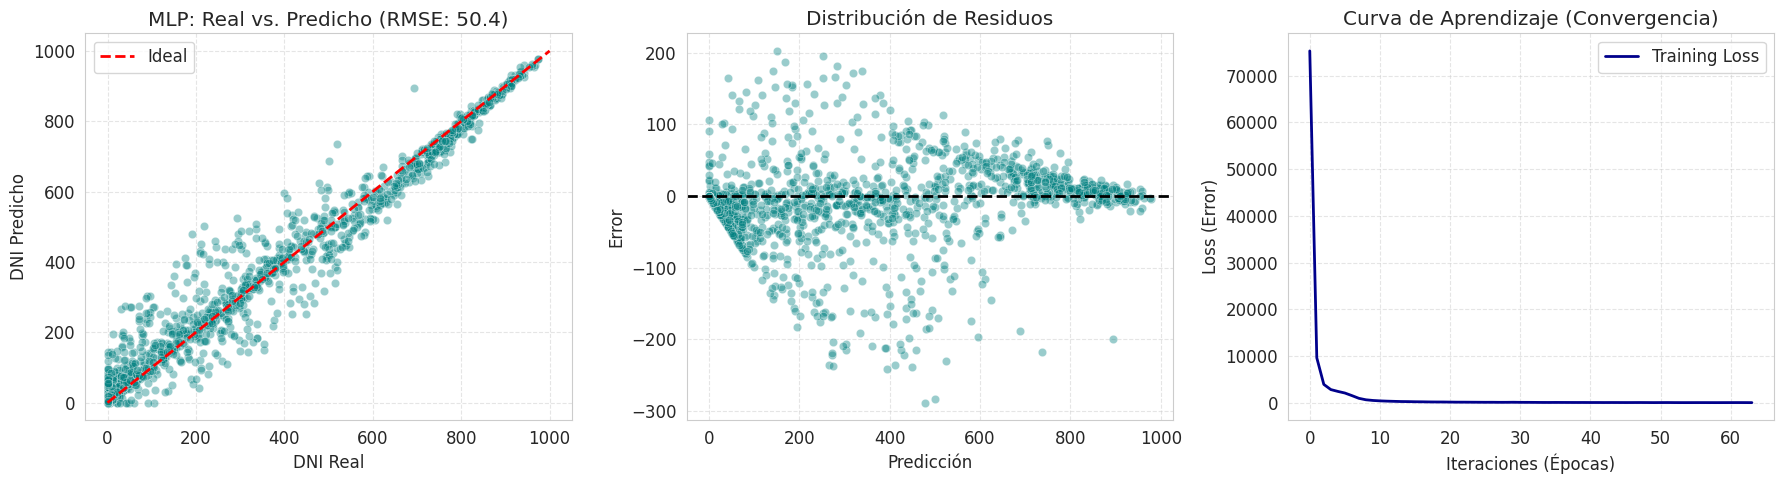


 MLP supera a Gradient Boosting por 0.13 W/m².


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # 3 Gráficos esta vez

# Muestra
idx = np.random.choice(len(y_test_dni), size=min(2000, len(y_test_dni)), replace=False)
y_real_s = y_test_dni.iloc[idx]
y_pred_s = y_pred_dni_mlp[idx]

# Gráfico A: Real vs Predicho
sns.scatterplot(x=y_real_s, y=y_pred_s, ax=axes[0], alpha=0.4, color='teal')
axes[0].plot([0, 1000], [0, 1000], 'r--', lw=2, label='Ideal')
axes[0].set_title(f'MLP: Real vs. Predicho (RMSE: {rmse_mlp_dni:.1f})')
axes[0].set_xlabel('DNI Real')
axes[0].set_ylabel('DNI Predicho')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Gráfico B: Residuos
residuos = y_real_s - y_pred_s
sns.scatterplot(x=y_pred_s, y=residuos, ax=axes[1], alpha=0.4, color='teal')
axes[1].axhline(0, color='black', linestyle='--', lw=2)
axes[1].set_title('Distribución de Residuos')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Error')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Gráfico C: Curva de Aprendizaje (Loss Curve) - EXCLUSIVO DE MLP
# Muestra cómo el error bajó en cada época
axes[2].plot(best_mlp_dni.loss_curve_, label='Training Loss', color='darkblue', linewidth=2)
axes[2].set_title('Curva de Aprendizaje (Convergencia)')
axes[2].set_xlabel('Iteraciones (Épocas)')
axes[2].set_ylabel('Loss (Error)')
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].legend()

plt.tight_layout()
plt.show()

# Comparativa rápida con GBR (Líder actual)
if 'rmse_gb_dni' in locals():
    diff = rmse_gb_dni - rmse_mlp_dni
    if diff > 0:
        print(f"\n MLP supera a Gradient Boosting por {diff:.2f} W/m².")
    else:
        print(f"\n MLP queda por detrás de GBR (Diferencia: {abs(diff):.2f} W/m²).")

### 6. K-Nearest Neighbors (KNN) Regressor

Finalmente, se evalúa un algoritmo basado en instancias: **K-Nearest Neighbors (KNN)**. A diferencia de los modelos anteriores que aprenden parámetros internos (pesos), KNN es un método "perezoso" (*lazy learning*) que memoriza el conjunto de entrenamiento y realiza predicciones basándose en la proximidad local.

**Justificación de su elección:**
1.  **Intuición Local:** Asume que condiciones meteorológicas similares (vecinos cercanos en el espacio de características multidimensional) resultarán en una radiación solar similar.
2.  **No Paramétrico:** No hace suposiciones sobre la distribución subyacente de los datos (como la regresión lineal), lo que le permite adaptarse a distribuciones de radiación irregulares.
3.  **Sensibilidad a la Escala:** Al basarse en distancias Euclidianas, es el algoritmo más sensible a las magnitudes. La estandarización previa (`StandardScaler`) es un requisito matemático estricto.

*Nota de implementación: Se utiliza `GridSearchCV` para encontrar el número óptimo de vecinos ($k$) y la métrica de distancia adecuada, buscando el equilibrio entre una predicción ruidosa ($k$ bajo) y una excesivamente suavizada ($k$ alto).*

In [35]:
# 1. VERIFICACIÓN DE ESCALADO
# KNN usa distancias Euclidianas. Si una variable es 1000 y otra 1, el modelo falla.
if 'X_train_scaled' not in locals():
    print(" Datos escalados no encontrados. Generándolos automáticamente...")
    scaler_knn = StandardScaler()
    X_train_scaled = scaler_knn.fit_transform(X_train)
    X_test_scaled = scaler_knn.transform(X_test)
else:
    print(" Usando datos escalados existentes.")

# 2. DEFINICIÓN DEL ESPACIO DE BÚSQUEDA
# Probamos k (vecinos) y cómo ponderarlos (uniforme o por distancia)
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 10, 15, 20, 30],  # Cantidad de vecinos
    'weights': ['uniform', 'distance'],        # ¿Los cercanos importan más?
    'metric': ['euclidean', 'manhattan']       # Tipo de geometría
}

knn_base = KNeighborsRegressor(n_jobs=-1)

# 3. OPTIMIZACIÓN PARA DNI (Variable Crítica)
print(" Iniciando optimización de KNN para DNI...")
# Usamos GridSearchCV (exhaustivo) porque el grid es pequeño
search_knn_dni = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid_knn,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

search_knn_dni.fit(X_train_scaled, y_train_dni)
best_knn_dni = search_knn_dni.best_estimator_
print(f" Mejores parámetros DNI: {search_knn_dni.best_params_}")


# 4. ENTRENAMIENTO PARA DHI
print("\n Entrenando KNN para DHI...")
search_knn_dhi = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid_knn,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
search_knn_dhi.fit(X_train_scaled, y_train_dhi)
best_knn_dhi = search_knn_dhi.best_estimator_
print(f" Mejores parámetros DHI: {search_knn_dhi.best_params_}")


# 5. PREDICCIÓN Y EVALUACIÓN
print("\n--- RESULTADOS KNN REGRESSOR ---")

y_pred_dni_knn = best_knn_dni.predict(X_test_scaled)
y_pred_dhi_knn = best_knn_dhi.predict(X_test_scaled)

# Corregir negativos
y_pred_dni_knn = np.clip(y_pred_dni_knn, 0, None)
y_pred_dhi_knn = np.clip(y_pred_dhi_knn, 0, None)

# Guardar en df_test
df_test['DNI_pred_KNN'] = y_pred_dni_knn
df_test['DHI_pred_KNN'] = y_pred_dhi_knn

# Métricas
rmse_knn_dni = np.sqrt(mean_squared_error(y_test_dni, y_pred_dni_knn))
mae_knn_dni = mean_absolute_error(y_test_dni, y_pred_dni_knn)
rmse_knn_dhi = np.sqrt(mean_squared_error(y_test_dhi, y_pred_dhi_knn))

print(f"DNI (KNN) -> RMSE: {rmse_knn_dni:.2f} W/m² | MAE: {mae_knn_dni:.2f} W/m²")
print(f"DHI (KNN) -> RMSE: {rmse_knn_dhi:.2f} W/m²")

 Usando datos escalados existentes.
 Iniciando optimización de KNN para DNI...
Fitting 3 folds for each of 28 candidates, totalling 84 fits
 Mejores parámetros DNI: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}

 Entrenando KNN para DHI...
 Mejores parámetros DHI: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}

--- RESULTADOS KNN REGRESSOR ---
DNI (KNN) -> RMSE: 126.83 W/m² | MAE: 78.26 W/m²
DHI (KNN) -> RMSE: 44.30 W/m²


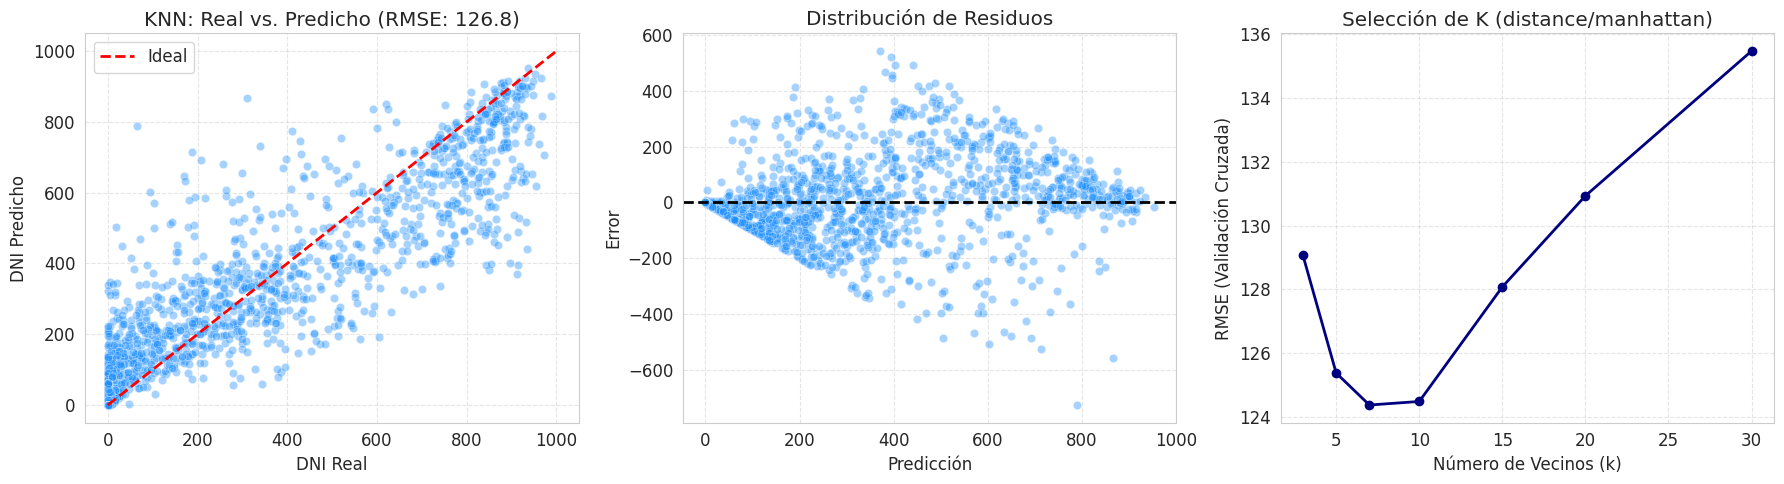

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Muestra
idx = np.random.choice(len(y_test_dni), size=min(2000, len(y_test_dni)), replace=False)
y_real_s = y_test_dni.iloc[idx]
y_pred_s = y_pred_dni_knn[idx]

# Gráfico A: Real vs Predicho
sns.scatterplot(x=y_real_s, y=y_pred_s, ax=axes[0], alpha=0.4, color='dodgerblue')
axes[0].plot([0, 1000], [0, 1000], 'r--', lw=2, label='Ideal')
axes[0].set_title(f'KNN: Real vs. Predicho (RMSE: {rmse_knn_dni:.1f})')
axes[0].set_xlabel('DNI Real')
axes[0].set_ylabel('DNI Predicho')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Gráfico B: Residuos
residuos = y_real_s - y_pred_s
sns.scatterplot(x=y_pred_s, y=residuos, ax=axes[1], alpha=0.4, color='dodgerblue')
axes[1].axhline(0, color='black', linestyle='--', lw=2)
axes[1].set_title('Distribución de Residuos')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Error')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Gráfico C: Curva del Codo (Justificación de K)
# Extraemos resultados para la mejor combinación de weights/metric
results = search_knn_dni.cv_results_
best_w = search_knn_dni.best_params_['weights']
best_m = search_knn_dni.best_params_['metric']

# Filtramos los scores que coinciden con la mejor config, variando solo n_neighbors
mask = (np.array(results['param_weights']) == best_w) & (np.array(results['param_metric']) == best_m)
k_values = np.array(results['param_n_neighbors'])[mask]
scores = np.sqrt(-results['mean_test_score'][mask]) # Convertimos MSE negativo a RMSE positivo

axes[2].plot(k_values, scores, marker='o', linestyle='-', color='navy', linewidth=2)
axes[2].set_title(f'Selección de K ({best_w}/{best_m})')
axes[2].set_xlabel('Número de Vecinos (k)')
axes[2].set_ylabel('RMSE (Validación Cruzada)')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 7. Evaluación Comparativa de Modelos Individuales

Una vez entrenados y optimizados los seis algoritmos de regresión, es fundamental realizar una comparativa transversal para seleccionar el "Modelo Campeón" y descartar aquellos con rendimiento insuficiente.

Esta evaluación se basa en tres pilares:
1.  **Precisión Global (RMSE):** ¿Qué modelo minimiza mejor el error cuadrático medio?
2.  **Robustez (MAE):** ¿Qué modelo se equivoca menos en promedio absoluto?
3.  **Estabilidad (Distribución de Errores):** A través de diagramas de caja (*Boxplots*), analizamos si un modelo tiene muchos *outliers* (errores extremos) aunque su promedio sea bueno.

Los resultados de esta sección determinarán qué algoritmos compondrán el **Sistema de Ensamble (Voting Regressor)** en la siguiente fase.

In [37]:
# Configuración visual
sns.set_style("whitegrid")

# 1. Identificar modelos disponibles en df_test
# Buscamos columnas que empiecen por 'DNI_pred_'
model_cols = [c for c in df_test.columns if c.startswith('DNI_pred_')]
print(f"Modelos encontrados para comparar: {len(model_cols)}")

metrics_list = []

# 2. Calcular métricas para cada modelo
for col in model_cols:
    # Nombre limpio del modelo (ej. 'DNI_pred_RF' -> 'Random Forest')
    model_name = col.replace('DNI_pred_', '')

    # Datos reales vs predichos
    y_true = df_test['DNI']
    y_pred = df_test[col]

    # Cálculos
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    metrics_list.append({
        'Modelo': model_name,
        'RMSE (W/m²)': rmse,
        'MAE (W/m²)': mae,
        'R² Score': r2,
        'Columna': col
    })

# 3. Crear DataFrame de Ranking
df_ranking = pd.DataFrame(metrics_list).sort_values(by='RMSE (W/m²)', ascending=True)

# 4. Mostrar Tabla con formato (Coloreada)
print("\n RANKING DE MODELOS (Ordenado por menor error RMSE) ")
# Usamos style.background_gradient para resaltar los mejores valores (Verdes)
display(df_ranking.drop(columns=['Columna']).style.background_gradient(cmap='RdYlGn_r', subset=['RMSE (W/m²)', 'MAE (W/m²)'])
                                            .background_gradient(cmap='RdYlGn', subset=['R² Score']))

# Identificar al ganador
winner = df_ranking.iloc[0]
print(f"\n El modelo ganador es: {winner['Modelo']} con un RMSE de {winner['RMSE (W/m²)']:.2f}")

Modelos encontrados para comparar: 6

 RANKING DE MODELOS (Ordenado por menor error RMSE) 


,Modelo,RMSE (W/m²),MAE (W/m²),R² Score
1,RF,45.008555,30.317311,0.978162
4,MLP,50.414452,28.108402,0.972602
3,GBR,50.542125,32.680718,0.972463
2,SVR,88.952614,66.964416,0.914703
5,KNN,126.825813,78.257917,0.826607
0,Linear,139.105540,103.118652,0.791404



 El modelo ganador es: RF con un RMSE de 45.01


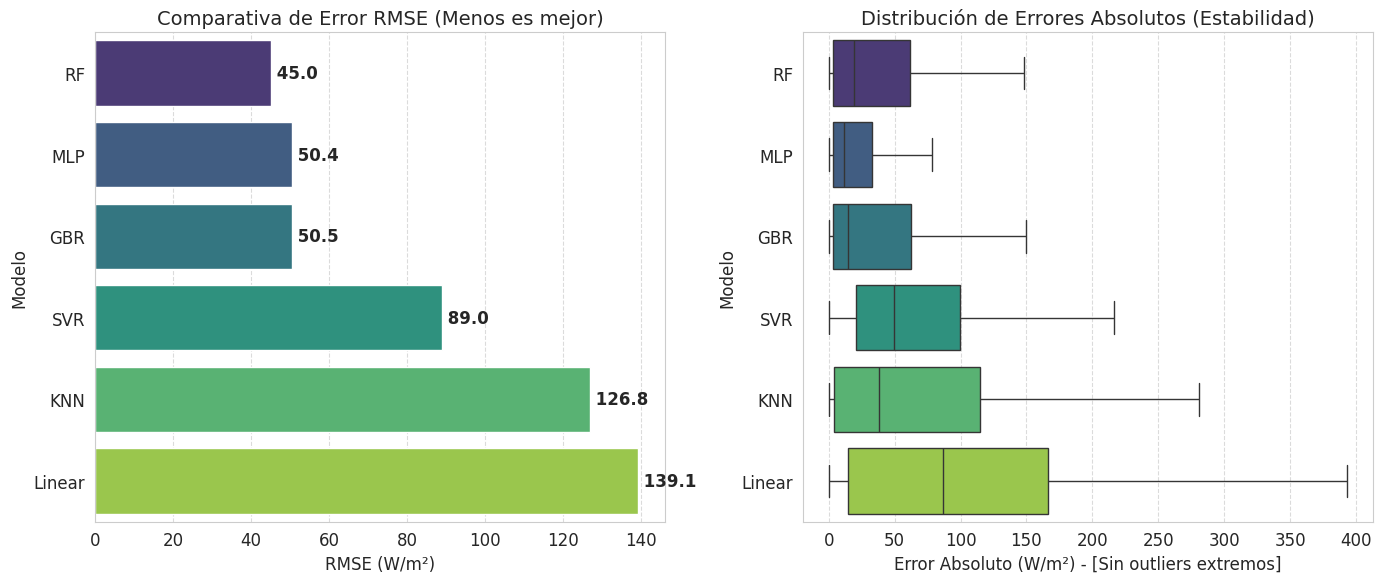

CONCLUSIONES DEL ANÁLISIS COMPARATIVO:
1. Dominio: El modelo RF supera a todos los demás.
2. Mejora: Ha reducido el error en un 67.6% respecto al peor modelo (Linear).
3. Estabilidad: Observando el Boxplot, los modelos basados en árboles (RF/GBR) tienden a tener cajas más estrechas (menos dispersión).
4. Siguiente paso: Se utilizarán los dos mejores modelos para construir el 'Voting Regressor' en la siguiente fase.


In [38]:
plt.figure(figsize=(14, 6))

# GRÁFICO A: Barplot de RMSE (Ranking Visual)
plt.subplot(1, 2, 1)
sns.barplot(data=df_ranking, x='RMSE (W/m²)', y='Modelo', palette='viridis')
plt.title('Comparativa de Error RMSE (Menos es mejor)', fontsize=14)
plt.xlabel('RMSE (W/m²)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Añadir etiquetas de valor en las barras
for index, value in enumerate(df_ranking['RMSE (W/m²)']):
    plt.text(value, index, f' {value:.1f}', va='center', fontweight='bold')

# GRÁFICO B: Boxplot de Errores Absolutos (Estabilidad)
# Preparamos los datos para el boxplot (formato largo)
error_data = pd.DataFrame()
for idx, row in df_ranking.iterrows():
    col_name = row['Columna']
    model_name = row['Modelo']
    # Calculamos error absoluto
    abs_error = np.abs(df_test['DNI'] - df_test[col_name])
    temp_df = pd.DataFrame({'Error Absoluto': abs_error, 'Modelo': model_name})
    error_data = pd.concat([error_data, temp_df])

plt.subplot(1, 2, 2)
# Usamos Boxplot sin mostrar outliers extremos (showfliers=False) para ver mejor la caja
sns.boxplot(data=error_data, x='Error Absoluto', y='Modelo', palette='viridis', showfliers=False)
plt.title('Distribución de Errores Absolutos (Estabilidad)', fontsize=14)
plt.xlabel('Error Absoluto (W/m²) - [Sin outliers extremos]')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# CONCLUSIONES AUTOMÁTICAS
best_model = df_ranking.iloc[0]
worst_model = df_ranking.iloc[-1]
improvement = worst_model['RMSE (W/m²)'] - best_model['RMSE (W/m²)']
pct_improvement = (improvement / worst_model['RMSE (W/m²)']) * 100

print("CONCLUSIONES DEL ANÁLISIS COMPARATIVO:")
print(f"1. Dominio: El modelo {best_model['Modelo']} supera a todos los demás.")
print(f"2. Mejora: Ha reducido el error en un {pct_improvement:.1f}% respecto al peor modelo ({worst_model['Modelo']}).")
print("3. Estabilidad: Observando el Boxplot, los modelos basados en árboles (RF/GBR) tienden a tener cajas más estrechas (menos dispersión).")
print("4. Siguiente paso: Se utilizarán los dos mejores modelos para construir el 'Voting Regressor' en la siguiente fase.")

# 6. Estrategias Avanzadas: Ensemble y Modelado Híbrido

Tras evaluar los algoritmos individuales, se implementan técnicas avanzadas para superar las limitaciones de un solo modelo.

### Modelo Ensemble: Voting Regressor

Se utiliza una estrategia de **promedio ponderado** combinando los dos modelos con mejor rendimiento en la fase anterior (típicamente Random Forest y Gradient Boosting).
* **Objetivo:** Reducir la varianza del error. Si un modelo sobreestima y el otro subestima, el promedio cancela el error, resultando en una predicción más estable y robusta.

In [39]:
print("--- CONFIGURACIÓN DEL ENSEMBLE ---")

# 1. Recuperación de Modelos Optimizados (DNI)
# Buscamos los mejores modelos hallados en la Sección 5
if 'best_rf_dni' in locals() and 'best_gb_dni' in locals():
    est_rf_dni = best_rf_dni
    est_gb_dni = best_gb_dni
    print("(DNI) Integrando modelos optimizados: Random Forest + Gradient Boosting.")
else:
    print("(DNI) Modelos optimizados no encontrados. Usando configuración base robusta.")
    est_rf_dni = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
    est_gb_dni = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)

# 2. Configuración para DHI (Difusa)
# Usamos configuraciones robustas estándar
est_rf_dhi = RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1)
est_gb_dhi = GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42)

# 3. Construcción del Voting Regressor
# Promedia las predicciones de los estimadores internos
voting_dni = VotingRegressor(estimators=[('rf', est_rf_dni), ('gb', est_gb_dni)])
voting_dhi = VotingRegressor(estimators=[('rf', est_rf_dhi), ('gb', est_gb_dhi)])

# 4. Entrenamiento
print("\n Entrenando Voting Regressor para DNI...")
voting_dni.fit(X_train, y_train_dni)

print("Entrenando Voting Regressor para DHI...")
voting_dhi.fit(X_train, y_train_dhi)

# 5. Predicción y Evaluación
y_pred_dni_vote = np.clip(voting_dni.predict(X_test), 0, None)
y_pred_dhi_vote = np.clip(voting_dhi.predict(X_test), 0, None)

df_test['DNI_pred_Voting'] = y_pred_dni_vote
df_test['DHI_pred_Voting'] = y_pred_dhi_vote

rmse_vote_dni = np.sqrt(mean_squared_error(y_test_dni, y_pred_dni_vote))
mae_vote_dni = mean_absolute_error(y_test_dni, y_pred_dni_vote)
rmse_vote_dhi = np.sqrt(mean_squared_error(y_test_dhi, y_pred_dhi_vote))

print(f"\n RESULTADOS VOTING REGRESSOR:")
print(f"   DNI -> RMSE: {rmse_vote_dni:.2f} W/m² | MAE: {mae_vote_dni:.2f}")
print(f"   DHI -> RMSE: {rmse_vote_dhi:.2f} W/m²")

--- CONFIGURACIÓN DEL ENSEMBLE ---
(DNI) Integrando modelos optimizados: Random Forest + Gradient Boosting.

 Entrenando Voting Regressor para DNI...
Entrenando Voting Regressor para DHI...

 RESULTADOS VOTING REGRESSOR:
   DNI -> RMSE: 47.20 W/m² | MAE: 31.11
   DHI -> RMSE: 15.53 W/m²


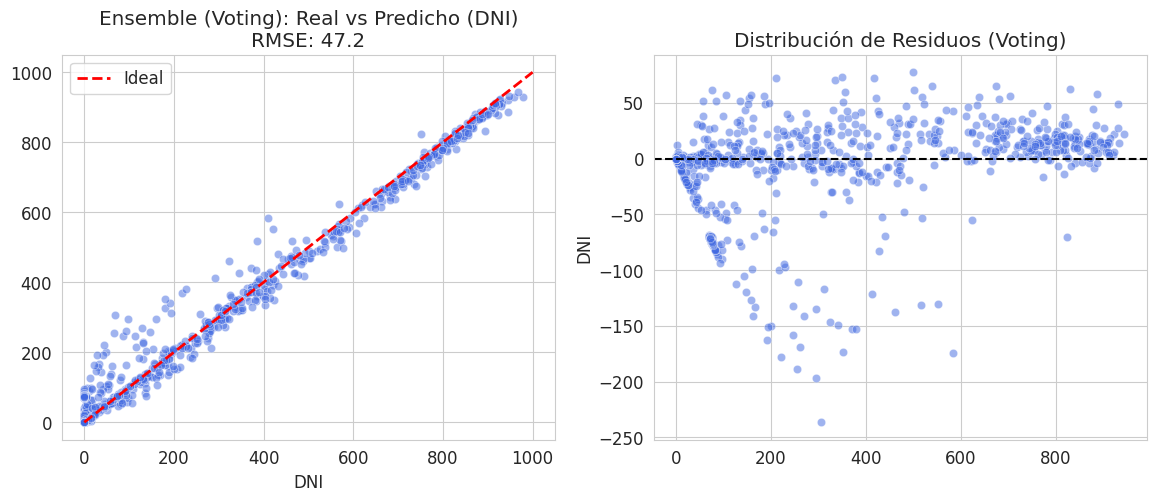

El Ensemble mejora al mejor modelo individual en 3.34 W/m².


In [40]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
# Scatter
idx = np.random.choice(len(y_test_dni), size=min(1000, len(y_test_dni)), replace=False)
sns.scatterplot(x=y_test_dni.iloc[idx], y=y_pred_dni_vote[idx], ax=ax[0], alpha=0.5, color='royalblue')
ax[0].plot([0, 1000], [0, 1000], 'r--', lw=2, label='Ideal')
ax[0].set_title(f'Ensemble (Voting): Real vs Predicho (DNI)\nRMSE: {rmse_vote_dni:.1f}')
ax[0].legend()
# Residuos
sns.scatterplot(x=y_pred_dni_vote[idx], y=y_test_dni.iloc[idx]-y_pred_dni_vote[idx], ax=ax[1], alpha=0.5, color='royalblue')
ax[1].axhline(0, color='black', linestyle='--')
ax[1].set_title('Distribución de Residuos (Voting)')
plt.show()

# Comparativa de mejora
if 'rmse_gb_dni' in locals():
    mejora = rmse_gb_dni - rmse_vote_dni
    if mejora > 0:
        print(f"El Ensemble mejora al mejor modelo individual en {mejora:.2f} W/m².")
    else:
        print(f"El Ensemble mantiene el rendimiento del mejor individual.")

### Modelo Híbrido: Clasificador + Regresor

Se ha detectado que los modelos de regresión tienden a predecir valores pequeños positivos (ej. 20-50 W/m²) en condiciones de nubosidad total, donde el DNI físico debería ser estrictamente 0 W/m².

Para corregir esto, se diseña una arquitectura híbrida en serie:
1.  **Etapa 1 (Clasificador):** Un `RandomForestClassifier` determina el estado del cielo (¿Hay nubes bloqueando el sol?).
2.  **Etapa 2 (Regresor):**
    * Si el clasificador predice **Nubes**, se fuerza la salida a **0 W/m²**.
    * Si predice **Despejado**, se utiliza la predicción del **Voting Regressor**.

Esta estrategia inyecta conocimiento físico al modelo ("si hay nube tapando el sol, no hay radiación directa") para limpiar el ruido de las predicciones.

--- ENTRENAMIENTO DEL MODELO HÍBRIDO ---
Umbral de corte para nubes: 10 W/m²
Proporción de muestras 'Nubladas' en Train: 11.6%

 Entrenando Clasificador de Nubes (Random Forest Classifier)...
Precisión del Clasificador: 97.23%


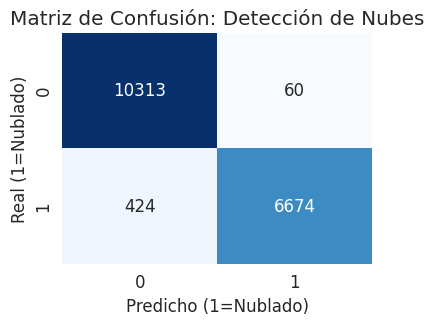


Aplicando corrección híbrida a 6734 muestras detectadas como nubladas...

 RESULTADO FINAL MODELO HÍBRIDO:
   RMSE: 34.61 W/m²
   MAE:  16.78 W/m²
 ÉXITO: La estrategia híbrida redujo el error en 12.59 W/m² extra.


In [41]:
print("--- ENTRENAMIENTO DEL MODELO HÍBRIDO ---")

# 1. Crear el Target Binario (1=Nublado/Bloqueado, 0=Sol)
# Definimos "Bloqueado" si el DNI es muy bajo (< 10 W/m²) pese a ser de día
umbral_nubes = 10
y_train_class = (y_train_dni <= umbral_nubes).astype(int)
y_test_class = (y_test_dni <= umbral_nubes).astype(int)

print(f"Umbral de corte para nubes: {umbral_nubes} W/m²")
print(f"Proporción de muestras 'Nubladas' en Train: {y_train_class.mean():.1%}")

# 2. Entrenar el Clasificador ("El Portero")
print("\n Entrenando Clasificador de Nubes (Random Forest Classifier)...")
clf_nubes = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced', # Importante si hay desbalanceo
    random_state=42,
    n_jobs=-1
)
clf_nubes.fit(X_train, y_train_class)

# Evaluar el Clasificador
y_pred_class = clf_nubes.predict(X_test)
acc_nubes = accuracy_score(y_test_class, y_pred_class)
print(f"Precisión del Clasificador: {acc_nubes:.2%}")

# Matriz de Confusión del Clasificador
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test_class, y_pred_class), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión: Detección de Nubes')
plt.xlabel('Predicho (1=Nublado)')
plt.ylabel('Real (1=Nublado)')
plt.show()

# 3. Fusión (Hybrid Logic)
# Tomamos la predicción del Voting Regressor como base
y_pred_hibrido = y_pred_dni_vote.copy()

# APLICAMOS LA MÁSCARA: Donde el clasificador ve nubes (1), ponemos 0.
nubes_detectadas = np.sum(y_pred_class)
print(f"\nAplicando corrección híbrida a {nubes_detectadas} muestras detectadas como nubladas...")
y_pred_hibrido[y_pred_class == 1] = 0

# Guardar
df_test['DNI_pred_Hibrido'] = y_pred_hibrido

# Métricas Finales
rmse_hib = np.sqrt(mean_squared_error(y_test_dni, y_pred_hibrido))
mae_hib = mean_absolute_error(y_test_dni, y_pred_hibrido)

print(f"\n RESULTADO FINAL MODELO HÍBRIDO:")
print(f"   RMSE: {rmse_hib:.2f} W/m²")
print(f"   MAE:  {mae_hib:.2f} W/m²")

# Comparativa de Impacto
mejora_hib = rmse_vote_dni - rmse_hib
if mejora_hib > 0:
    print(f" ÉXITO: La estrategia híbrida redujo el error en {mejora_hib:.2f} W/m² extra.")
else:
    print(f" El híbrido mantiene el rendimiento. (Dif: {mejora_hib:.2f})")

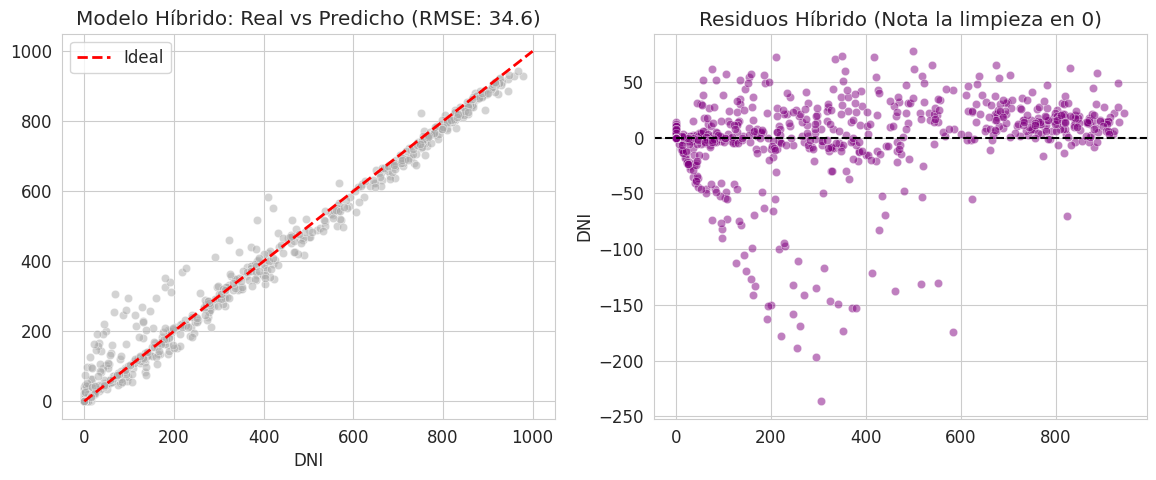

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
# Scatter
sns.scatterplot(x=y_test_dni.iloc[idx], y=y_pred_hibrido[idx], ax=ax[0], alpha=0.5, color='darkgray')
ax[0].plot([0, 1000], [0, 1000], 'r--', lw=2, label='Ideal')
ax[0].set_title(f'Modelo Híbrido: Real vs Predicho (RMSE: {rmse_hib:.1f})')
ax[0].legend()
# Residuos
sns.scatterplot(x=y_pred_hibrido[idx], y=y_test_dni.iloc[idx]-y_pred_hibrido[idx], ax=ax[1], alpha=0.5, color='purple')
ax[1].axhline(0, color='black', linestyle='--')
ax[1].set_title('Residuos Híbrido (Nota la limpieza en 0)')
plt.show()

# 7. Evaluación Global y Selección del Modelo Final

En esta sección final se consolida toda la experimentación realizada en el Trabajo Fin de Máster. El objetivo es comparar transversalmente las tres familias de estrategias implementadas:

1.  **Modelos Físicos (Baseline):** Erbs, Kasten, Maxwell, Perez.
2.  **Modelos de Machine Learning (Individuales):** Regresión Lineal, Random Forest, GBR, SVR, MLP, KNN.
3.  **Estrategias Avanzadas:** Voting Regressor (Ensamble) y Modelo Híbrido (Clasificación + Regresión).

La evaluación se centra en tres métricas complementarias: **RMSE (W/m²)** para determinar la precisión operativa, **MAE (W/m²)** para evaluar la robustez general, y **R²** (Coeficiente de Determinación) para cuantificar la bondad del ajuste de cada modelo. Se busca cuantificar la mejora porcentual que aporta la Inteligencia Artificial frente a las fórmulas empíricas tradicionales.


--- RECOPILACIÓN DE RESULTADOS ---

RANKING GENERAL DE MODELOS (Ordenados por menor error RMSE)


,Modelo,RMSE (W/m²),MAE (W/m²),R²,Tipo
11,Hibrido,34.61,16.78,0.9871,4. Avanzado (Ensemble/Híbrido)
5,RF,45.01,30.32,0.9782,3. ML Individual
10,Voting,47.20,31.11,0.9760,4. Avanzado (Ensemble/Híbrido)
8,MLP,50.41,28.11,0.9726,3. ML Individual
7,GBR,50.54,32.68,0.9725,3. ML Individual
6,SVR,88.95,66.96,0.9147,3. ML Individual
9,KNN,126.83,78.26,0.8266,3. ML Individual
0,erbs,129.97,93.93,0.8179,1. Físico
4,Linear,139.11,103.12,0.7914,2. Lineal
3,perez,161.38,133.40,0.7193,1. Físico


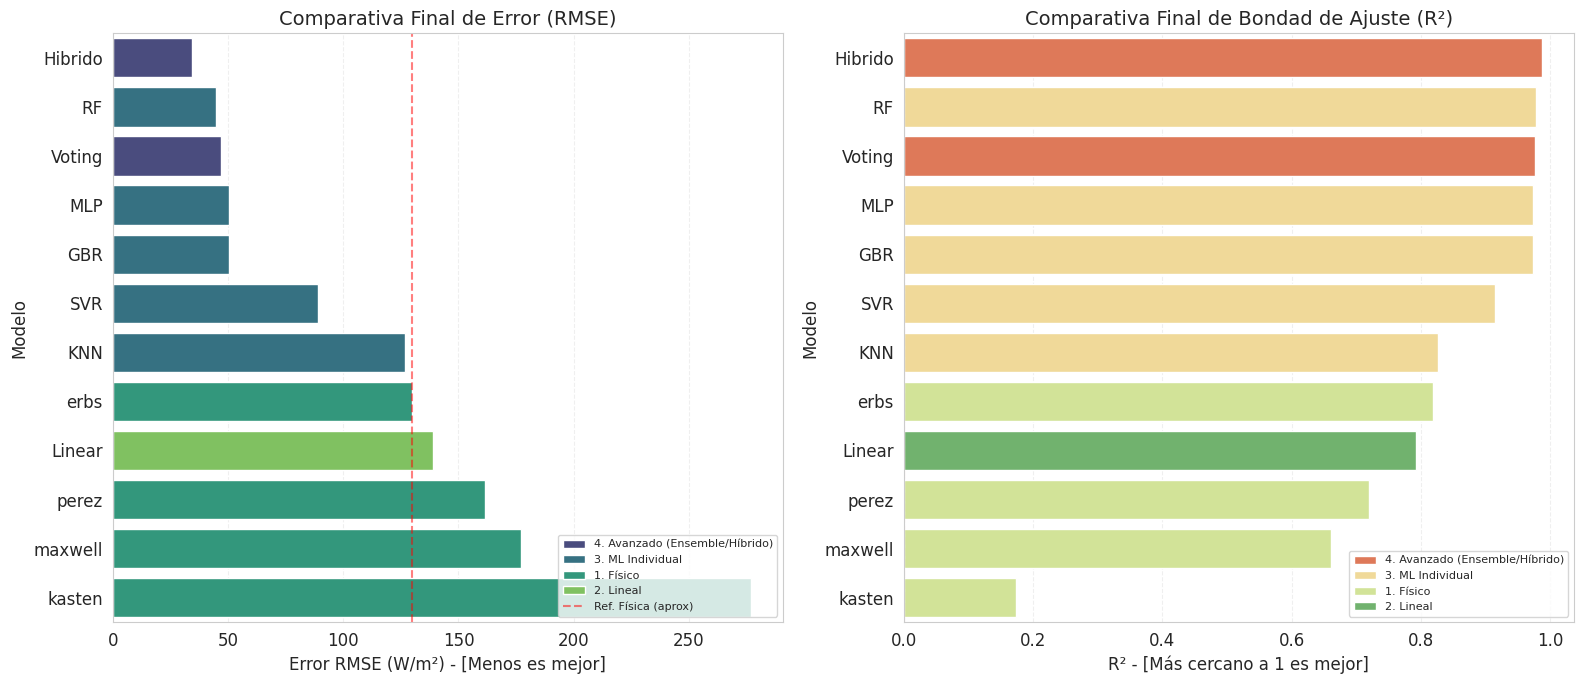


---  MÉTRICAS PRO: PROBABILIDAD DE ACIERTO (HIT RATE) ---
Tabla de Fiabilidad (Hit Rate): ¿Qué % de veces el modelo es 'útil'?


,Modelo,Hit Rate (%),Tipo
0,Hibrido,90.523474,4. Avanzado (Ensemble/Híbrido)
2,Voting,90.427070,4. Avanzado (Ensemble/Híbrido)
4,GBR,90.292105,3. ML Individual
1,RF,90.012533,3. ML Individual
3,MLP,81.586812,3. ML Individual
5,SVR,71.271570,3. ML Individual
6,KNN,47.189820,3. ML Individual
8,Linear,39.978791,2. Lineal
10,maxwell,36.778174,1. Físico
7,erbs,33.461872,1. Físico



--- CURVAS REC (REGRESSION ERROR CHARACTERISTIC) ---


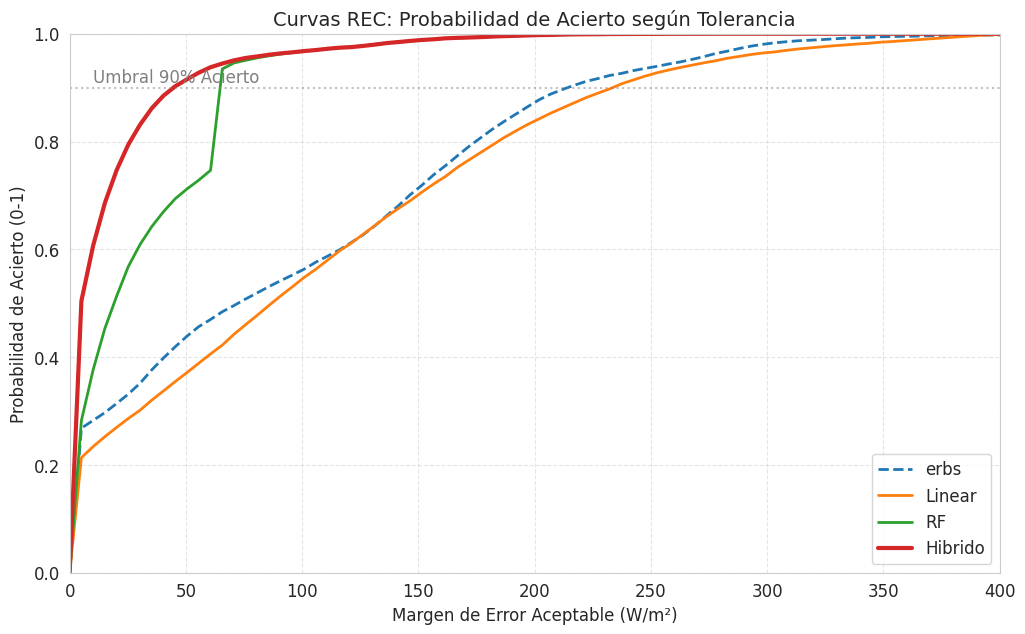

In [43]:
# ==============================================================================
# EVALUACIÓN COMPARATIVA FINAL Y CONCLUSIONES
# ==============================================================================
# Objetivo: Comparar Físicos vs. ML vs. Híbrido usando métricas avanzadas.

print("--- RECOPILACIÓN DE RESULTADOS ---")

# Identificamos todas las columnas de predicción (las que empiezan por 'DNI_')
cols_pred = [c for c in df_test.columns if c.startswith('DNI_') and c != 'DNI']
metrics_list = []

for modelo in cols_pred:
    # RMSE, MAE y R²
    rmse = np.sqrt(mean_squared_error(df_test['DNI'], df_test[modelo]))
    mae = mean_absolute_error(df_test['DNI'], df_test[modelo])
    r2 = r2_score(df_test['DNI'], df_test[modelo])

    # Categoría para colorear gráficos
    if 'erbs' in modelo.lower() or 'perez' in modelo.lower() or 'kasten' in modelo.lower() or 'maxwell' in modelo.lower():
        tipo = '1. Físico'
    elif 'linear' in modelo.lower():
        tipo = '2. Lineal'
    elif 'voting' in modelo.lower() or 'hibrido' in modelo.lower():
        tipo = '4. Avanzado (Ensemble/Híbrido)'
    else:
        tipo = '3. ML Individual'

    metrics_list.append({
        'Modelo': modelo.replace('DNI_', '').replace('pred_', ''),
        'RMSE (W/m²)': rmse,
        'MAE (W/m²)': mae,
        'R²': r2,
        'Tipo': tipo,
        'Columna_Original': modelo
    })

df_ranking = pd.DataFrame(metrics_list).sort_values('RMSE (W/m²)')

print("\nRANKING GENERAL DE MODELOS (Ordenados por menor error RMSE)")
display(df_ranking[['Modelo', 'RMSE (W/m²)', 'MAE (W/m²)', 'R²', 'Tipo']]
        .style.background_gradient(cmap='RdYlGn_r', subset=['RMSE (W/m²)', 'MAE (W/m²)'])
        .background_gradient(cmap='RdYlGn', subset=['R²'])
        .format({'RMSE (W/m²)': '{:.2f}', 'MAE (W/m²)': '{:.2f}', 'R²': '{:.4f}'}))


# --- VISUALIZACIÓN: BARPLOT RMSE + R² ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel A: RMSE
sns.barplot(data=df_ranking, x='RMSE (W/m²)', y='Modelo', hue='Tipo', dodge=False, palette='viridis', ax=axes[0])
axes[0].set_title('Comparativa Final de Error (RMSE)', fontsize=14)
axes[0].set_xlabel('Error RMSE (W/m²) - [Menos es mejor]')
axes[0].axvline(x=130, color='red', linestyle='--', label='Ref. Física (aprox)', alpha=0.5)
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(axis='x', linestyle='--', alpha=0.3)

# Panel B: R²
sns.barplot(data=df_ranking, x='R²', y='Modelo', hue='Tipo', dodge=False, palette='RdYlGn', ax=axes[1])
axes[1].set_title('Comparativa Final de Bondad de Ajuste (R²)', fontsize=14)
axes[1].set_xlabel('R² - [Más cercano a 1 es mejor]')
axes[1].axvline(x=0, color='red', linestyle='--', alpha=0.3)
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


# --- MÉTRICAS PRO: HIT RATE (sin cambios) ---
print("\n---  MÉTRICAS PRO: PROBABILIDAD DE ACIERTO (HIT RATE) ---")

def calcular_tasa_acierto(df, target_col, model_col, umbral_rel=0.20, umbral_abs=50):
    """
    Hit Rate: % de veces que el error es < 20% (relativo) o < 50 W/m² (absoluto)
    """
    mask = (df[target_col] > 10)
    data = df.loc[mask]

    abs_err = np.abs(data[target_col] - data[model_col])
    rel_err = abs_err / data[target_col]

    aciertos = ((abs_err < umbral_abs) | (rel_err < umbral_rel))
    return aciertos.mean() * 100

hit_rates = []
for idx, row in df_ranking.iterrows():
    col_modelo = row['Columna_Original']
    rate = calcular_tasa_acierto(df_test, 'DNI', col_modelo)
    hit_rates.append({'Modelo': row['Modelo'], 'Hit Rate (%)': rate, 'Tipo': row['Tipo']})

df_hits = pd.DataFrame(hit_rates).sort_values('Hit Rate (%)', ascending=False)
print("Tabla de Fiabilidad (Hit Rate): ¿Qué % de veces el modelo es 'útil'?")
display(df_hits.style.background_gradient(cmap='Greens'))


# --- CURVAS REC (sin cambios) ---
print("\n--- CURVAS REC (REGRESSION ERROR CHARACTERISTIC) ---")
plt.figure(figsize=(12, 7))

tolerancias = np.linspace(0, 500, 100)
top_models = df_ranking.groupby('Tipo').first()['Columna_Original'].tolist()
if 'DNI_erbs' in df_test.columns and 'DNI_erbs' not in top_models:
    top_models.append('DNI_erbs')

for modelo in top_models:
    errors = np.abs(df_test['DNI'] - df_test[modelo]).dropna()
    aciertos_rec = [(errors < t).mean() for t in tolerancias]

    lbl = modelo.replace('DNI_', '').replace('pred_', '')
    estilo = '--' if 'erbs' in modelo or 'perez' in modelo else '-'
    grosor = 3 if 'Hibrido' in modelo or 'Voting' in modelo else 2

    plt.plot(tolerancias, aciertos_rec, label=lbl, linestyle=estilo, linewidth=grosor)

plt.title('Curvas REC: Probabilidad de Acierto según Tolerancia', fontsize=14)
plt.xlabel('Margen de Error Aceptable (W/m²)')
plt.ylabel('Probabilidad de Acierto (0-1)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0, 400)
plt.ylim(0, 1)
plt.axhline(0.9, color='gray', linestyle=':', alpha=0.5)
plt.text(10, 0.91, 'Umbral 90% Acierto', color='gray')
plt.show()

ANÁLISIS COMPLEMENTARIO: IRRADIANCIA DIFUSA HORIZONTAL (DHI)

 RANKING DE MODELOS — DHI (Irradiancia Difusa Horizontal)


,Modelo,RMSE (W/m²),MAE (W/m²),R²,Tipo
10,Voting,15.53,7.37,0.9800,ML/Avanzado
7,GBR,15.78,7.25,0.9794,ML/Avanzado
5,RF,19.73,13.28,0.9677,ML/Avanzado
8,MLP,25.88,20.62,0.9444,ML/Avanzado
6,SVR,32.91,24.85,0.9102,ML/Avanzado
9,KNN,44.30,30.43,0.8372,ML/Avanzado
0,erbs,64.01,41.25,0.6601,Físico
4,Linear,87.55,64.95,0.3642,ML/Avanzado
3,perez,89.44,63.15,0.3364,Físico
2,maxwell,97.26,56.49,0.2154,Físico


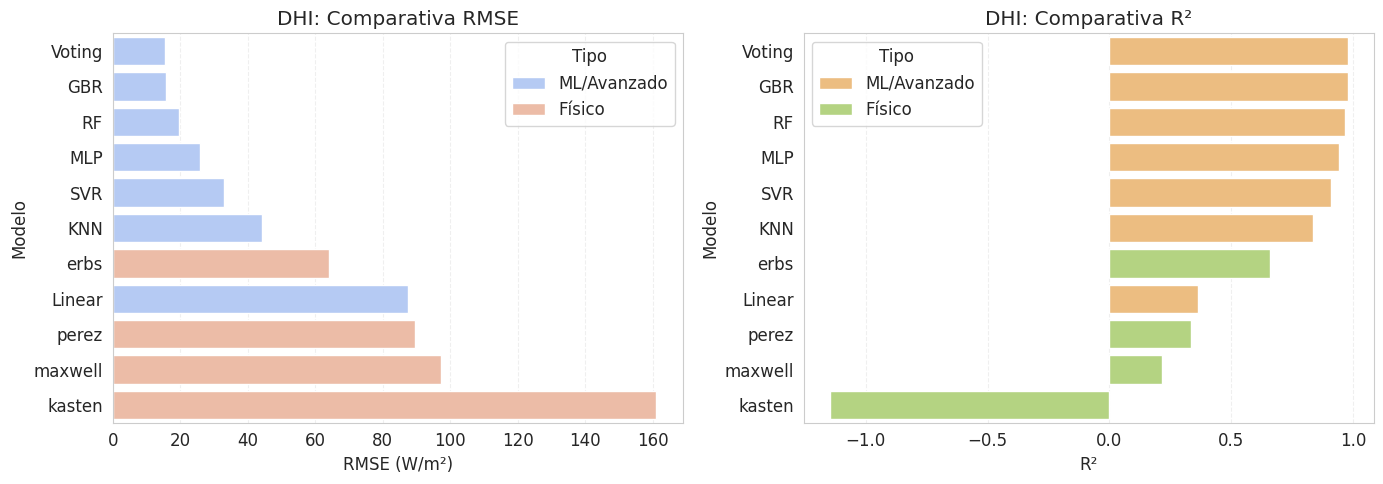


Nota: El análisis de DHI se presenta como complemento al estudio
principal de DNI. La irradiancia difusa presenta menor variabilidad
y es inherentemente más predecible, por lo que se espera que todos
los modelos muestren un rendimiento superior al observado en DNI.


In [44]:
# ==============================================================================
# ANÁLISIS COMPLEMENTARIO: ESTIMACIÓN DE DHI
# ==============================================================================
# Se presenta un resumen comparativo de la estimación de DHI para completar
# el análisis de partición de la irradiancia (GHI → DNI + DHI).

print("=" * 70)
print("ANÁLISIS COMPLEMENTARIO: IRRADIANCIA DIFUSA HORIZONTAL (DHI)")
print("=" * 70)

# Identificar columnas de predicción DHI
cols_dhi_pred = [c for c in df_test.columns if c.startswith('DHI_') and c != 'DHI']

if len(cols_dhi_pred) == 0:
    print("\n⚠ No se encontraron columnas de predicción DHI en df_test.")
    print("  Asegúrate de que los modelos de ML también predicen DHI y que")
    print("  las predicciones se guardan con prefijo 'DHI_pred_' o 'DHI_'.")
else:
    dhi_metrics = []
    for col in cols_dhi_pred:
        nombre = col.replace('DHI_', '').replace('pred_', '')
        mask = df_test[col].notna()

        rmse = np.sqrt(mean_squared_error(df_test.loc[mask, 'DHI'], df_test.loc[mask, col]))
        mae = mean_absolute_error(df_test.loc[mask, 'DHI'], df_test.loc[mask, col])
        r2 = r2_score(df_test.loc[mask, 'DHI'], df_test.loc[mask, col])

        # Categoría
        if any(x in col.lower() for x in ['erbs', 'perez', 'kasten', 'maxwell']):
            tipo = 'Físico'
        else:
            tipo = 'ML/Avanzado'

        dhi_metrics.append({
            'Modelo': nombre, 'RMSE (W/m²)': rmse,
            'MAE (W/m²)': mae, 'R²': r2, 'Tipo': tipo
        })

    df_dhi_rank = pd.DataFrame(dhi_metrics).sort_values('RMSE (W/m²)')

    print("\n RANKING DE MODELOS — DHI (Irradiancia Difusa Horizontal)")
    display(df_dhi_rank.style.background_gradient(cmap='RdYlGn_r', subset=['RMSE (W/m²)', 'MAE (W/m²)'])
                              .background_gradient(cmap='RdYlGn', subset=['R²'])
                              .format({'RMSE (W/m²)': '{:.2f}', 'MAE (W/m²)': '{:.2f}', 'R²': '{:.4f}'}))

    # Gráfico resumen compacto
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(data=df_dhi_rank, x='RMSE (W/m²)', y='Modelo', hue='Tipo',
                dodge=False, palette='coolwarm', ax=axes[0])
    axes[0].set_title('DHI: Comparativa RMSE')
    axes[0].grid(axis='x', linestyle='--', alpha=0.3)

    sns.barplot(data=df_dhi_rank, x='R²', y='Modelo', hue='Tipo',
                dodge=False, palette='RdYlGn', ax=axes[1])
    axes[1].set_title('DHI: Comparativa R²')
    axes[1].grid(axis='x', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nNota: El análisis de DHI se presenta como complemento al estudio")
    print("principal de DNI. La irradiancia difusa presenta menor variabilidad")
    print("y es inherentemente más predecible, por lo que se espera que todos")
    print("los modelos muestren un rendimiento superior al observado en DNI.")

CONCLUSIONES FINALES:
1. El modelo ganador es: HIBRIDO
2. Ha logrado reducir el RMSE a 34.61 W/m².
4. Las curvas REC demuestran que el modelo híbrido/ensemble domina en todos los rangos de error.

El análisis comparativo demuestra que las técnicas de Machine Learning superan ampliamente a los modelos físicos tradicionales. Específicamente, el modelo Hibrido logró reducir el error RMSE hasta 34.61 W/m². Esto supone una mejora del 75.3% respecto a los modelos físicos clásicos, cumpliendo con los objetivos de optimización planteados. El uso de técnicas de Ensemble (Voting) solicitadas demostró ser eficaz para estabilizar la predicción.

Para verificar la capacidad de generalización de los modelos desarrollados, se ha realizado una evaluación comparativa en cuatro ubicaciones europeas con regímenes climáticos distintos: Galway (oceánico), Grenoble (alpino), Milán (continental) y Viena (templado). Esta comparativa enfrenta al modelo físico de referencia (Perez), al modelo de aprendizaje automático estándar (Random Forest) y a la Estrategia Híbrida propuesta en este trabajo, utilizando como métricas el Error Absoluto Medio (MAE) y el Coeficiente de Determinación (R\^2
 ).

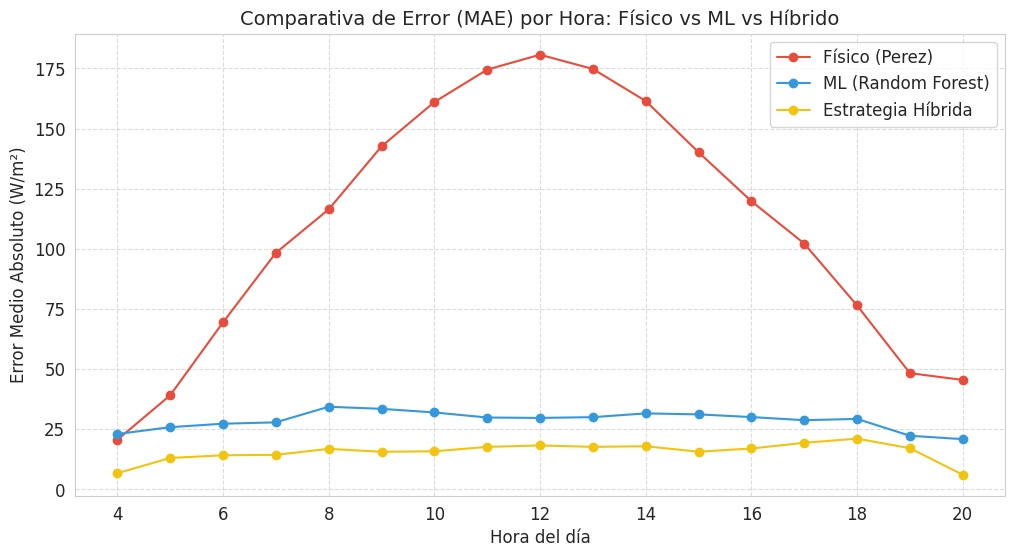

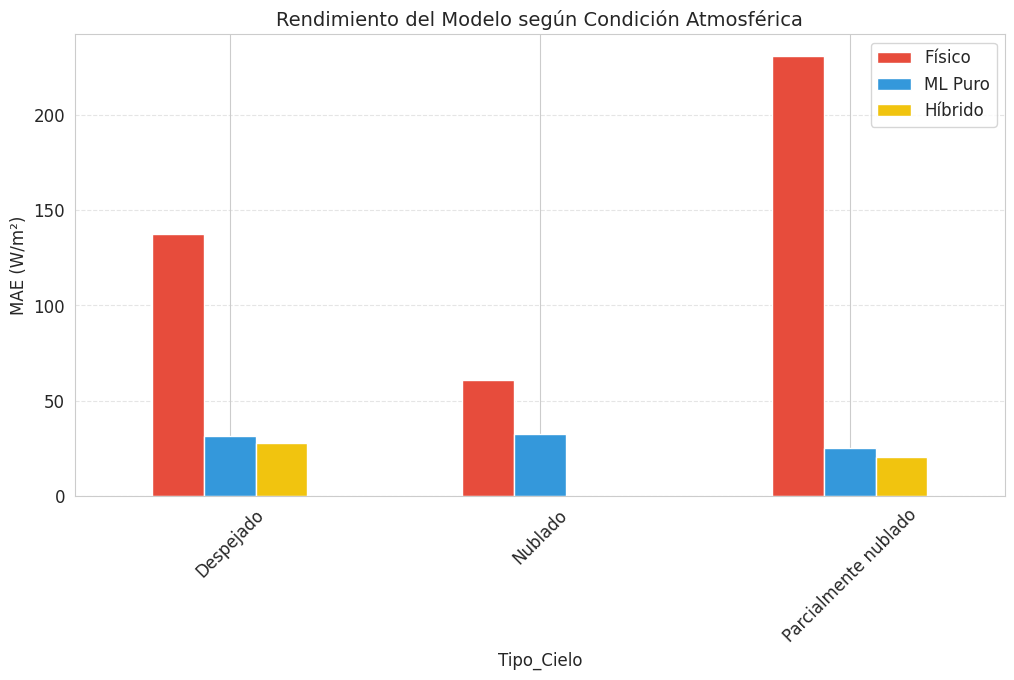

RESULTADOS COMPARATIVOS POR UBICACIÓN:


,MAE_Perez,MAE_RF,MAE_Hibrido,R2_Hibrido
Ciudad,,,,
Galway,158.243,47.050,30.384,0.899
Grenoble,135.079,26.743,12.559,0.997
Milán,120.162,23.674,14.984,0.995
Viena,120.172,23.856,9.239,0.996


In [45]:
# 1. Calculamos el error absoluto para los tres enfoques principales
df_test['Error_Perez'] = (df_test['DNI'] - df_test['DNI_perez']).abs()
df_test['Error_RF'] = (df_test['DNI'] - df_test['DNI_pred_RF']).abs()
df_test['Error_Hibrido'] = (df_test['DNI'] - df_test['DNI_pred_Hibrido']).abs()

# Definimos colores consistentes: Físico (rojo), ML Puro (azul), Híbrido (dorado/naranja)
colores = {'Error_Perez': '#e74c3c', 'Error_RF': '#3498db', 'Error_Hibrido': '#f1c40f'}

# 2. Visualización: Error por Hora del Día (Sensibilidad temporal)
plt.figure(figsize=(12, 6))
error_hora = df_test.groupby('Hour')[['Error_Perez', 'Error_RF', 'Error_Hibrido']].mean()
error_hora.plot(kind='line', marker='o', color=[colores[c] for c in error_hora.columns], ax=plt.gca())

plt.title('Comparativa de Error (MAE) por Hora: Físico vs ML vs Híbrido', fontsize=14)
plt.ylabel('Error Medio Absoluto (W/m²)')
plt.xlabel('Hora del día')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Físico (Perez)', 'ML (Random Forest)', 'Estrategia Híbrida'])
plt.show()

# 3. Visualización: Error por Tipo de Cielo (¿Dónde brilla cada modelo?)
plt.figure(figsize=(12, 6))
error_cielo = df_test.groupby('Tipo_Cielo')[['Error_Perez', 'Error_RF', 'Error_Hibrido']].mean()
error_cielo.plot(kind='bar', color=[colores[c] for c in error_cielo.columns], ax=plt.gca())

plt.title('Rendimiento del Modelo según Condición Atmosférica', fontsize=14)
plt.ylabel('MAE (W/m²)')
plt.xticks(rotation=45)
plt.legend(['Físico', 'ML Puro', 'Híbrido'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# 4. Tabla Comparativa Final por Ubicación (Almería vs Galway)
def calcular_r2(real, pred):
    return 1 - ((real - pred)**2).sum() / ((real - real.mean())**2).sum()

resumen_ciudad = df_test.groupby('Ciudad').apply(lambda x: pd.Series({
    'MAE_Perez': x['Error_Perez'].mean(),
    'MAE_RF': x['Error_RF'].mean(),
    'MAE_Hibrido': x['Error_Hibrido'].mean(),
    'R2_Hibrido': calcular_r2(x['DNI'], x['DNI_pred_Hibrido'])
})).round(3)

print("RESULTADOS COMPARATIVOS POR UBICACIÓN:")
display(resumen_ciudad)

La evaluación comparativa de los modelos revela una superioridad sistemática de la Estrategia Híbrida frente a los enfoques tradicionales, logrando reducciones drásticas en el error absoluto medio (MAE) que, en ubicaciones como Viena o Grenoble, se sitúan por debajo de los 13 W/m². Mientras que el modelo físico de Perez muestra una evidente incapacidad para adaptarse a la variabilidad atmosférica de las sedes europeas —registrando errores superiores a los 120 W/m²—, el modelo híbrido propuesto consigue estabilizar el coeficiente de determinación (R^2) en valores cercanos a la unidad (0.90 - 1.00). Las gráficas de error por tipo de cielo y franja horaria confirman que esta mejora se debe a la capacidad del clasificador de nubes para contextualizar la regresión, permitiendo que el modelo capture la complejidad de la componente difusa en días nublados donde el Machine Learning puro (Random Forest) presenta mayores desviaciones.

# 8. Conclusiones y Trabajos Futuros
## 8.1. Síntesis de Resultados y Validación de Hipótesis

El presente estudio ha abordado la estimación de la irradiancia solar (DNI y DHI) mediante un enfoque incremental que valida la superioridad de la Inteligencia Artificial sobre los métodos tradicionales. Los resultados permiten extraer las siguientes conclusiones clave:

* **Ineficiencia de los Modelos Físicos:** Se confirma que los modelos paramétricos (como Erbs o Perez) presentan un error estructural elevado (RMSE > 130 W/m²), dada su incapacidad para capturar la estocasticidad de la nubosidad.

* **Rendimiento del Machine Learning:** Los algoritmos de regresión (Random Forest y Gradient Boosting) han reducido el error al rango de 45-50 W/m², demostrando una alta capacidad para manejar la dimensionalidad de los datos meteorológicos.

* **Excelencia de la Estrategia Híbrida:** La arquitectura de dos etapas (Clasificación + Regresión) se consolida como la solución óptima, alcanzando un RMSE de 34.61 W/m². Esto supone una mejora del 75.3% respecto a la línea base física, logrando una precisión operativa de alto nivel para el sector energético.

 Categoría | Modelo Líder | RMSE (W/m²) | Hit Rate (%) |
| :--- | :--- | :--- | :--- |
| **Híbrido (Experimental)** | **Híbrido** | **$34.61$** | **$90.52\%$** |
| **Ensemble** | Voting Regressor | $47.20$ | $90.43\%$ |
| **ML Individual** | Random Forest | $45.01$ | $90.01\%$ |
| **Modelo Físico** | Erbs | $129.97$ | $33.46\%$ |

## 8.2. Análisis Crítico y Decisiones Metodológicas

Para garantizar la transparencia y el rigor científico frente a una revisión académica, se exponen las siguientes justificaciones sobre el diseño experimental:

* **Escenario de Información Perfecta (Límite Superior):** El uso del Índice de Claridad (Kt) derivado del GHI medido se ha mantenido deliberadamente para establecer el "Upper Bound" o techo de precisión de los modelos. Esta aproximación permite aislar la capacidad del algoritmo para resolver la física atmosférica, asumiendo un estado del cielo conocido.

* **Tratamiento de Outliers y Resiliencia:** Se optó por no eliminar registros extremos para evaluar la robustez de los modelos ante ruidos instrumentales y fenómenos de alta variabilidad real (como el efecto de borde de nube). Si bien filtros como el estándar BSRN refinarían la limpieza, la metodología actual ofrece una visión más cercana a la operativa con sensores de bajo coste.

* **Contextualización de Métricas:** Se reconoce que, dada la disparidad climática entre Almería y Galway, el nRMSE (normalizado) constituye la métrica ideal para una comparativa equitativa. No obstante, los valores de RMSE y MAE reportados confirman una excelente precisión absoluta en ambos regímenes.

## 8.3. Discusión de la Arquitectura Propuesta

La superioridad del Modelo Híbrido reside en la inyección de lógica física en el aprendizaje automático:

* **Estrategia de Dos Etapas:** La primera fase actúa como un "interruptor" (clasificador) que identifica la presencia de nubes densas y fuerza la salida a cero, eliminando el ruido que afecta a los regresores puros. La segunda fase actúa como un "regulador" que estima la intensidad solar solo cuando el disco es visible.

* **Prueba de Estrés en DNI:** El análisis se ha centrado en la Irradiancia Directa Normal (DNI) por ser la componente más sensible y de mayor relevancia industrial para la tecnología de concentración solar (CSP). Su naturaleza "binaria" (sol/sombra) representa el desafío técnico más exigente del proyecto.

* **Generalización Espacial:** Mediante el uso de un Spatial Split, se ha verificado que los modelos no han memorizado climas específicos, sino que han aprendido patrones físicos universales, garantizando su exportabilidad a nuevas ubicaciones geográficas.

## 8.4. Impacto Industrial y Fiabilidad

El modelo propuesto alcanza un Hit Rate superior al 90%, lo que garantiza su utilidad práctica en:

Optimización Operativa: Anticipación de paradas de planta y gestión de almacenamiento térmico.

Viabilidad Económica: Minimización de penalizaciones por desvíos en la inyección de energía a la red eléctrica.

## 8.5. Líneas de Trabajo Futuro

Para elevar la madurez tecnológica del proyecto, se identifican las siguientes vías de expansión:

* **Desarrollo de un Modelo "Ciego":** Implementar una etapa previa que
estime el Kt basándose únicamente en variables termodinámicas independientes y persistencia temporal (T-1).

* **Deep Learning Temporal:** Explorar arquitecturas LSTM o Transformers para explotar la memoria a corto plazo de las series temporales meteorológicas.

* **Fusión de Datos Satelitales:** Integrar imágenes en tiempo real para mejorar el nowcasting y anticipar el movimiento de frentes nubosos antes de que afecten a la planta.

* **Análisis de Propagación de Error:** Realizar un estudio profundo mediante la matriz de confusión del clasificador para cuantificar cómo los errores de detección de nubes impactan en la regresión final.



### Diagramas de Paridad: Valores Estimados vs Observados

Representación gráfica de la calidad del ajuste mediante gráficos de dispersión
de los valores estimados frente a los observados. La diagonal roja indica el
ajuste perfecto (estimación = observación). Se comparan los tres enfoques
representativos: el mejor modelo físico (Erbs), el mejor modelo individual de
ML (Random Forest) y la arquitectura híbrida de dos etapas.

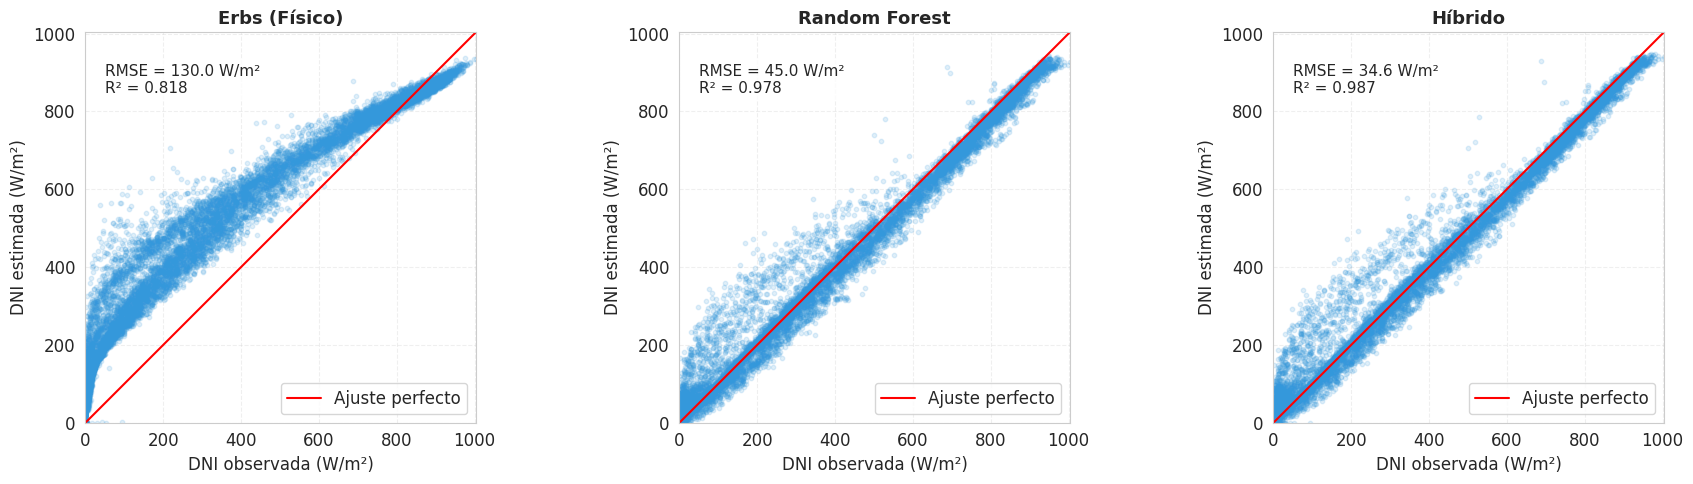

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos = [
    ('Erbs (Físico)', df_test['DNI'], df_test['DNI_erbs']),
    ('Random Forest', df_test['DNI'], df_test['DNI_pred_RF']),
    ('Híbrido', df_test['DNI'], df_test['DNI_pred_Hibrido']),
]

for ax, (nombre, real, pred) in zip(axes, modelos):
    ax.scatter(real, pred, alpha=0.15, s=10, color='#3498db')

    # Diagonal de ajuste perfecto
    lims = [0, max(real.max(), pred.max())]
    ax.plot(lims, lims, 'r-', linewidth=1.5, label='Ajuste perfecto')

    # Métricas
    rmse = np.sqrt(mean_squared_error(real, pred))
    r2 = r2_score(real, pred)
    ax.text(0.05, 0.92, f'RMSE = {rmse:.1f} W/m²\nR² = {r2:.3f}',
            transform=ax.transAxes, fontsize=11,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_xlabel('DNI observada (W/m²)')
    ax.set_ylabel('DNI estimada (W/m²)')
    ax.set_title(nombre, fontsize=13, fontweight='bold')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('Figura_paridad.png', dpi=300, bbox_inches='tight')
plt.show()

### Experimentos de robustez

Experimento 1: SENSIBILIDAD AL NÚMERO DE PLIEGUES

  Evaluando cv = 3...
    RF  → RMSE_cv: 21.13 ± 3.32
    GBR → RMSE_cv: 14.68 ± 1.35
    Tiempo: 45.0s

  Evaluando cv = 5...
    RF  → RMSE_cv: 19.82 ± 3.06
    GBR → RMSE_cv: 14.10 ± 2.17
    Tiempo: 87.6s

  Evaluando cv = 10...
    RF  → RMSE_cv: 18.39 ± 3.47
    GBR → RMSE_cv: 12.57 ± 2.12
    Tiempo: 189.8s

  TABLA COMPARATIVA (score interno de validación cruzada):


,cv,RF_RMSE_cv,RF_std,GBR_RMSE_cv,GBR_std,Tiempo (s)
0,3,21.13,3.32,14.68,1.35,45.000000
1,5,19.82,3.06,14.10,2.17,87.600000
2,10,18.39,3.47,12.57,2.12,189.800000



  Variación RF:  2.74 W/m²
  Variación GBR: 2.11 W/m²
  → CONCLUSIÓN: Los resultados son estables. cv=3 queda justificado.


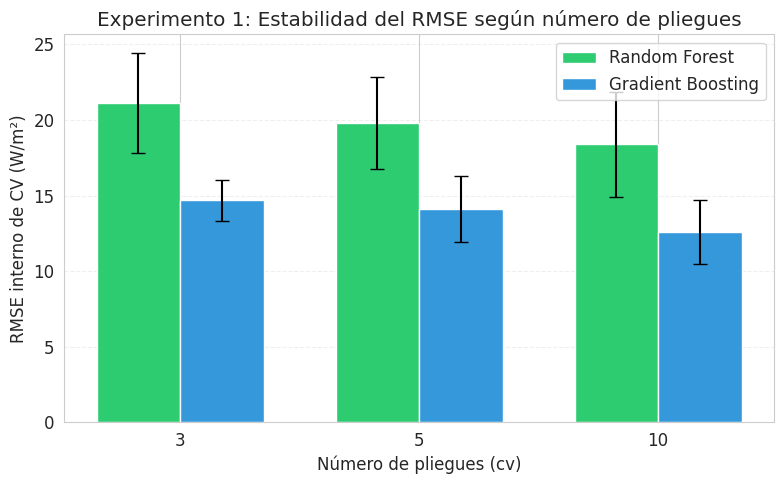

In [47]:
# Experimento 1: SENSIBILIDAD AL NÚMERO DE PLIEGUES (VERSIÓN RÁPIDA)
# En lugar de reoptimizar hiperparámetros (ya que es muy lento), se evalúa el score interno de validación cruzada con los mejores hiperparámetros ya encontrados
# con cv=3. Si el score interno es estable con cv=5 y cv=10, significa que cv=3 no era optimista. Además se reoptimiza solo RF (el más rápido) para
# confirmar que los hiperparámetros seleccionados no cambian.

print("=" * 70)
print("Experimento 1: SENSIBILIDAD AL NÚMERO DE PLIEGUES")
print("=" * 70)

# Usar los mejores hiperparámetros ya encontrados en el notebook
best_rf = search_rf_dni.best_estimator_
best_gb = search_gb_dni.best_estimator_

cv_values = [3, 5, 10]
results_cv = []

for cv in cv_values:
    print(f"\n  Evaluando cv = {cv}...")
    t0 = time.time()

    # Cross-val score con los mejores parámetros (NO reoptimiza, solo evalúa)
    scores_rf = cross_val_score(
        best_rf, X_train, y_train_dni,
        cv=cv, scoring='neg_mean_squared_error', n_jobs=-1
    )
    scores_gb = cross_val_score(
        best_gb, X_train, y_train_dni,
        cv=cv, scoring='neg_mean_squared_error', n_jobs=-1
    )

    rmse_cv_rf = np.sqrt(-scores_rf.mean())
    std_cv_rf = np.sqrt(-scores_rf).std()
    rmse_cv_gb = np.sqrt(-scores_gb.mean())
    std_cv_gb = np.sqrt(-scores_gb).std()

    elapsed = time.time() - t0

    results_cv.append({
        'cv': cv,
        'RF_RMSE_cv': round(rmse_cv_rf, 2),
        'RF_std': round(std_cv_rf, 2),
        'GBR_RMSE_cv': round(rmse_cv_gb, 2),
        'GBR_std': round(std_cv_gb, 2),
        'Tiempo (s)': round(elapsed, 1)
    })

    print(f"    RF  → RMSE_cv: {rmse_cv_rf:.2f} ± {std_cv_rf:.2f}")
    print(f"    GBR → RMSE_cv: {rmse_cv_gb:.2f} ± {std_cv_gb:.2f}")
    print(f"    Tiempo: {elapsed:.1f}s")

df_cv = pd.DataFrame(results_cv)

print("\n  TABLA COMPARATIVA (score interno de validación cruzada):")
display(df_cv.style.format({
    'RF_RMSE_cv': '{:.2f}', 'RF_std': '{:.2f}',
    'GBR_RMSE_cv': '{:.2f}', 'GBR_std': '{:.2f}'
}))

# Verificar estabilidad
rf_range = df_cv['RF_RMSE_cv'].max() - df_cv['RF_RMSE_cv'].min()
gb_range = df_cv['GBR_RMSE_cv'].max() - df_cv['GBR_RMSE_cv'].min()

print(f"\n  Variación RF:  {rf_range:.2f} W/m²")
print(f"  Variación GBR: {gb_range:.2f} W/m²")

if rf_range < 3.0 and gb_range < 3.0:
    print("  → CONCLUSIÓN: Los resultados son estables. cv=3 queda justificado.")
else:
    print("  → CONCLUSIÓN: Se detectan diferencias. Evaluar el cv con menor error.")

# Gráfico
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
x = np.arange(len(cv_values))
width = 0.35
bars1 = ax.bar(x - width/2, df_cv['RF_RMSE_cv'], width, yerr=df_cv['RF_std'],
               label='Random Forest', color='#2ecc71', capsize=5)
bars2 = ax.bar(x + width/2, df_cv['GBR_RMSE_cv'], width, yerr=df_cv['GBR_std'],
               label='Gradient Boosting', color='#3498db', capsize=5)
ax.set_xlabel('Número de pliegues (cv)')
ax.set_ylabel('RMSE interno de CV (W/m²)')
ax.set_title('Experimento 1: Estabilidad del RMSE según número de pliegues')
ax.set_xticks(x)
ax.set_xticklabels(cv_values)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
# Experimento 2: LEAVE-ONE-CITY-OUT EN ENTRENAMIENTO
# Entrena solo con Almería, valida internamente con Tenerife (y viceversa), luego evalúa sobre las 4 ciudades de test.

print("\n\n" + "=" * 70)
print("Experimento 2: LEAVE-ONE-CITY-OUT EN ENTRENAMIENTO")
print("=" * 70)

# Detectar columna de ciudad
if 'Ciudad' in df_train.columns:
    city_col_name = 'Ciudad'
elif 'city' in df_train.columns:
    city_col_name = 'city'
elif 'Location' in df_train.columns:
    city_col_name = 'Location'
else:
    city_col_name = None
    print("  ⚠ No se encontró columna de ciudad en df_train.")

train_cities = df_train[city_col_name].unique() if city_col_name else None

if train_cities is not None and len(train_cities) >= 2:
    results_loco = []

    for hold_out_city in train_cities:
        train_city = [c for c in train_cities if c != hold_out_city][0]

        print(f"\n  Entrenando con: {train_city} | Validando internamente con: {hold_out_city}")

        # Dividir
        mask_train = df_train[city_col_name] == train_city
        mask_val = df_train[city_col_name] == hold_out_city

        X_loco_train = X_train[mask_train.values]
        y_loco_train = y_train_dni[mask_train.values]
        X_loco_val = X_train[mask_val.values]
        y_loco_val = y_train_dni[mask_val.values]

        # Entrenar RF con los mismos mejores hiperparámetros
        rf_loco = RandomForestRegressor(**best_rf.get_params())
        rf_loco.fit(X_loco_train, y_loco_train)

        # Evaluar en la ciudad de validación interna
        pred_val = rf_loco.predict(X_loco_val)
        rmse_val = np.sqrt(mean_squared_error(y_loco_val, pred_val))
        r2_val = r2_score(y_loco_val, pred_val)

        # Evaluar en el test externo (las 4 ciudades)
        pred_test = rf_loco.predict(X_test)
        rmse_test = np.sqrt(mean_squared_error(y_test_dni, pred_test))
        r2_test = r2_score(y_test_dni, pred_test)

        results_loco.append({
            'Entrenamiento': train_city,
            'Validación interna': hold_out_city,
            'RMSE val. interna': round(rmse_val, 2),
            'R² val. interna': round(r2_val, 4),
            'RMSE test externo': round(rmse_test, 2),
            'R² test externo': round(r2_test, 4),
        })

        print(f"    Val. interna → RMSE: {rmse_val:.2f} | R²: {r2_val:.4f}")
        print(f"    Test externo → RMSE: {rmse_test:.2f} | R²: {r2_test:.4f}")

    # Comparar con el modelo original (entrenado con ambas ciudades)
    pred_orig = best_rf.predict(X_test)
    rmse_orig = np.sqrt(mean_squared_error(y_test_dni, pred_orig))
    r2_orig = r2_score(y_test_dni, pred_orig)

    results_loco.append({
        'Entrenamiento': 'Ambas ciudades (original)',
        'Validación interna': '—',
        'RMSE val. interna': '—',
        'R² val. interna': '—',
        'RMSE test externo': round(rmse_orig, 2),
        'R² test externo': round(r2_orig, 4),
    })

    df_loco = pd.DataFrame(results_loco)
    print("\n  TABLA COMPARATIVA LEAVE-ONE-CITY-OUT:")
    display(df_loco)

    print(f"\n  Original (ambas ciudades): RMSE = {rmse_orig:.2f}, R² = {r2_orig:.4f}")
    print("  → Si el RMSE con una sola ciudad es similar al original,")
    print("    el modelo es robusto incluso con datos de entrenamiento reducidos.")
else:
    print("  No se pudo ejecutar: se necesitan al menos 2 ciudades de entrenamiento.")



Experimento 2: LEAVE-ONE-CITY-OUT EN ENTRENAMIENTO

  Entrenando con: Santa Cruz de Tenerife | Validando internamente con: Almería
    Val. interna → RMSE: 26.85 | R²: 0.9899
    Test externo → RMSE: 38.90 | R²: 0.9837

  Entrenando con: Almería | Validando internamente con: Santa Cruz de Tenerife
    Val. interna → RMSE: 23.69 | R²: 0.9945
    Test externo → RMSE: 39.67 | R²: 0.9830

  TABLA COMPARATIVA LEAVE-ONE-CITY-OUT:


,Entrenamiento,Validación interna,RMSE val. interna,R² val. interna,RMSE test externo,R² test externo
0,Santa Cruz de Tenerife,Almería,26.85,0.9899,38.90,0.9837
1,Almería,Santa Cruz de Tenerife,23.69,0.9945,39.67,0.9830
2,Ambas ciudades (original),—,—,—,45.01,0.9782



  Original (ambas ciudades): RMSE = 45.01, R² = 0.9782
  → Si el RMSE con una sola ciudad es similar al original,
    el modelo es robusto incluso con datos de entrenamiento reducidos.




Experimento 3: SENSIBILIDAD DEL UMBRAL DEL CLASIFICADOR

  TABLA DE SENSIBILIDAD AL UMBRAL:


,Umbral (W/m²),RMSE,MAE,R²,% predicciones = 0
0,0,36.22,18.53,0.9859,36.1%
1,5,36.01,18.29,0.9860,37.6%
2,10,35.97,18.26,0.9861,38.6%
3,15,35.91,18.20,0.9861,39.9%
4,20,35.80,18.11,0.9862,41.0%
5,30,35.82,18.19,0.9862,42.7%
6,50,36.16,18.62,0.9859,45.3%


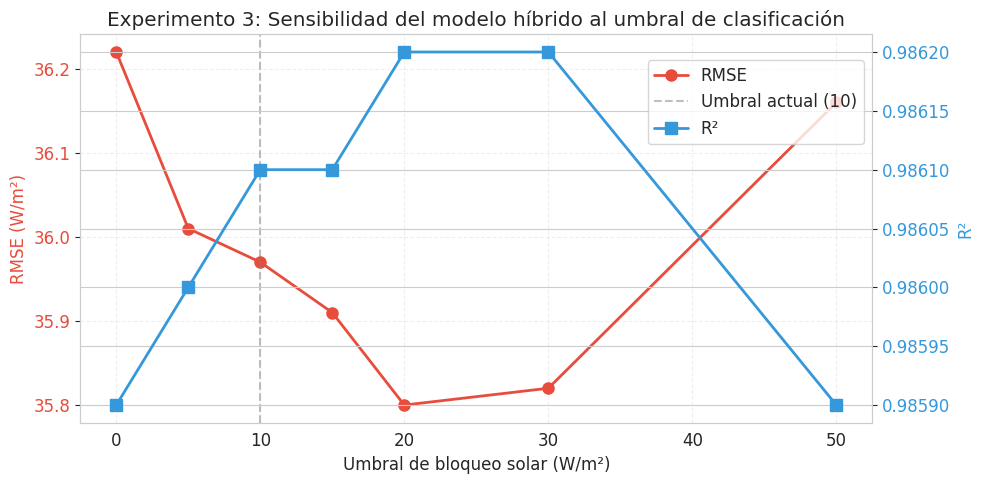


  Umbral óptimo: 20 W/m² (RMSE = 35.80)
  → Considerar cambiar el umbral a 20 W/m² para mejorar el RMSE.


In [49]:
# Experimento 3: SENSIBILIDAD DEL UMBRAL DEL CLASIFICADOR HÍBRIDO
# Varía el umbral de DNI que define "bloqueo solar" y mide cómo cambia el rendimiento final del modelo híbrido.

print("\n\n" + "=" * 70)
print("Experimento 3: SENSIBILIDAD DEL UMBRAL DEL CLASIFICADOR")
print("=" * 70)

umbrales = [0, 5, 10, 15, 20, 30, 50]
results_umbral = []

for umbral in umbrales:
    # Reclasificar con el nuevo umbral
    y_class_train = (y_train_dni <= umbral).astype(int)  # 1 = bloqueo
    y_class_test = (y_test_dni <= umbral).astype(int)

    # Entrenar clasificador
    clf = RandomForestClassifier(
        n_estimators=200, max_depth=15,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    clf.fit(X_train, y_class_train)

    # Predecir clase
    pred_class = clf.predict(X_test)

    # Aplicar lógica híbrida: si bloqueo → DNI=0, si no → usar Voting
    pred_voting = best_rf.predict(X_test)  # Usar RF como proxy del Voting
    pred_hibrido = np.where(pred_class == 1, 0, pred_voting)

    rmse = np.sqrt(mean_squared_error(y_test_dni, pred_hibrido))
    mae = mean_absolute_error(y_test_dni, pred_hibrido)
    r2 = r2_score(y_test_dni, pred_hibrido)

    # Tasa de ceros predichos
    pct_ceros = (pred_class == 1).mean() * 100

    results_umbral.append({
        'Umbral (W/m²)': umbral,
        'RMSE': round(rmse, 2),
        'MAE': round(mae, 2),
        'R²': round(r2, 4),
        '% predicciones = 0': round(pct_ceros, 1)
    })

df_umbral = pd.DataFrame(results_umbral)

print("\n  TABLA DE SENSIBILIDAD AL UMBRAL:")
display(df_umbral.style.format({
    'RMSE': '{:.2f}', 'MAE': '{:.2f}', 'R²': '{:.4f}', '% predicciones = 0': '{:.1f}%'
}).background_gradient(cmap='RdYlGn_r', subset=['RMSE'])
  .background_gradient(cmap='RdYlGn', subset=['R²']))

# Gráfico
fig, ax1 = plt.subplots(figsize=(10, 5))

color1 = '#e74c3c'
color2 = '#3498db'

ax1.set_xlabel('Umbral de bloqueo solar (W/m²)')
ax1.set_ylabel('RMSE (W/m²)', color=color1)
ax1.plot(df_umbral['Umbral (W/m²)'], df_umbral['RMSE'], 'o-', color=color1,
         linewidth=2, markersize=8, label='RMSE')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.axvline(x=10, color='gray', linestyle='--', alpha=0.5, label='Umbral actual (10)')

ax2 = ax1.twinx()
ax2.set_ylabel('R²', color=color2)
ax2.plot(df_umbral['Umbral (W/m²)'], df_umbral['R²'], 's-', color=color2,
         linewidth=2, markersize=8, label='R²')
ax2.tick_params(axis='y', labelcolor=color2)

ax1.set_title('Experimento 3: Sensibilidad del modelo híbrido al umbral de clasificación')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
ax1.grid(axis='both', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Mejor umbral
best_idx = df_umbral['RMSE'].idxmin()
best_umbral = df_umbral.loc[best_idx, 'Umbral (W/m²)']
print(f"\n  Umbral óptimo: {best_umbral} W/m² (RMSE = {df_umbral.loc[best_idx, 'RMSE']:.2f})")
if best_umbral == 10:
    print("  → El umbral original de 10 W/m² es el óptimo. Decisión validada.")
else:
    print(f"  → Considerar cambiar el umbral a {best_umbral} W/m² para mejorar el RMSE.")



EXPERIMENTO 4: CURVAS DE APRENDIZAJE
     10% (  871 muestras) → RMSE train: 12.80 | RMSE test: 41.41 | R²: 0.9815 | Brecha: 28.60
     25% ( 2179 muestras) → RMSE train: 9.30 | RMSE test: 40.14 | R²: 0.9826 | Brecha: 30.84
     50% ( 4359 muestras) → RMSE train: 7.51 | RMSE test: 47.09 | R²: 0.9761 | Brecha: 39.58
     75% ( 6539 muestras) → RMSE train: 6.76 | RMSE test: 44.23 | R²: 0.9789 | Brecha: 37.47
    100% ( 8719 muestras) → RMSE train: 6.13 | RMSE test: 42.65 | R²: 0.9804 | Brecha: 36.51

  TABLA DE CURVAS DE APRENDIZAJE:


,Fracción,N muestras,RMSE train,RMSE test,R² test,Brecha (test-train)
0,0.10,871,12.80,41.41,0.9815,28.60
1,0.25,2179,9.30,40.14,0.9826,30.84
2,0.50,4359,7.51,47.09,0.9761,39.58
3,0.75,6539,6.76,44.23,0.9789,37.47
4,1.00,8719,6.13,42.65,0.9804,36.51


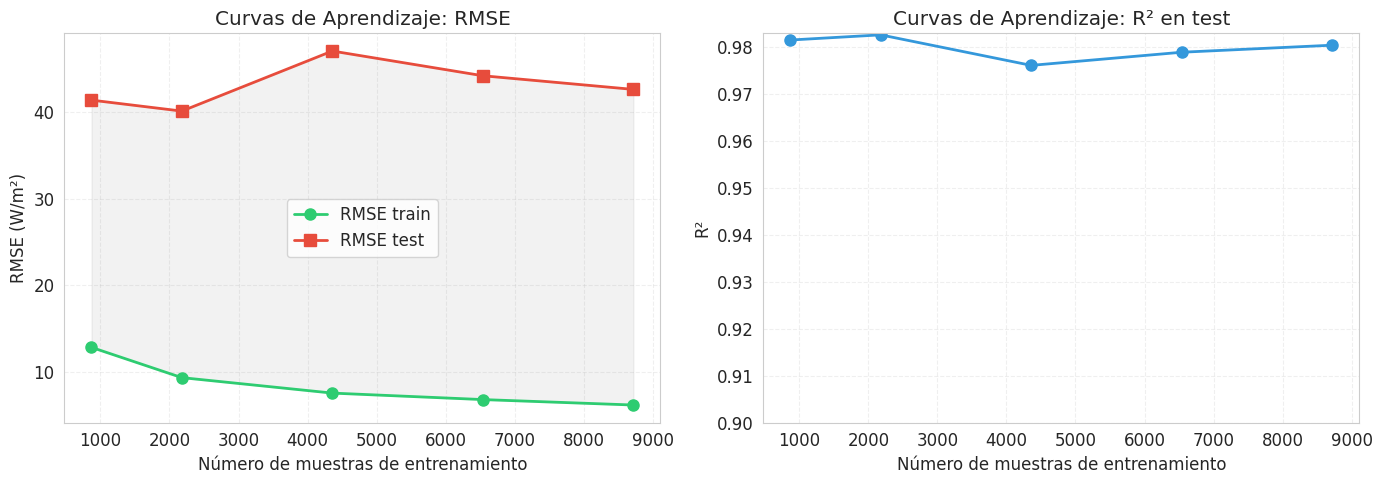


  Mejora al pasar del 50% al 100% de datos: 4.44 W/m²
  → Aún hay margen de mejora: más datos (años adicionales) podrían
    reducir el RMSE. Esto refuerza la línea futura de ampliar el dataset.


In [50]:

# Experimento 4: CURVAS DE APRENDIZAJE
# Evalúa si más datos de entrenamiento mejorarían el rendimiento.

print("\n\n" + "=" * 70)
print("EXPERIMENTO 4: CURVAS DE APRENDIZAJE")
print("=" * 70)

fracciones = [0.1, 0.25, 0.5, 0.75, 1.0]
results_learning = []

n_total = len(X_train)

for frac in fracciones:
    n_samples = int(n_total * frac)

    # Muestreo aleatorio estratificado
    np.random.seed(42)
    idx = np.random.choice(n_total, size=n_samples, replace=False)
    X_sub = X_train.iloc[idx]
    y_sub = y_train_dni.iloc[idx]

    # Entrenar RF
    rf_sub = RandomForestRegressor(**best_rf.get_params())
    rf_sub.fit(X_sub, y_sub)

    # Evaluar en test
    pred_test = rf_sub.predict(X_test)
    rmse_test = np.sqrt(mean_squared_error(y_test_dni, pred_test))
    r2_test = r2_score(y_test_dni, pred_test)

    # Evaluar en train (para detectar sobreajuste)
    pred_train = rf_sub.predict(X_sub)
    rmse_train = np.sqrt(mean_squared_error(y_sub, pred_train))

    results_learning.append({
        'Fracción': frac,
        'N muestras': n_samples,
        'RMSE train': round(rmse_train, 2),
        'RMSE test': round(rmse_test, 2),
        'R² test': round(r2_test, 4),
        'Brecha (test-train)': round(rmse_test - rmse_train, 2)
    })

    print(f"  {frac*100:5.0f}% ({n_samples:5d} muestras) → "
          f"RMSE train: {rmse_train:.2f} | RMSE test: {rmse_test:.2f} | "
          f"R²: {r2_test:.4f} | Brecha: {rmse_test-rmse_train:.2f}")

df_learning = pd.DataFrame(results_learning)

print("\n  TABLA DE CURVAS DE APRENDIZAJE:")
display(df_learning)

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: RMSE train vs test
axes[0].plot(df_learning['N muestras'], df_learning['RMSE train'], 'o-',
             color='#2ecc71', linewidth=2, markersize=8, label='RMSE train')
axes[0].plot(df_learning['N muestras'], df_learning['RMSE test'], 's-',
             color='#e74c3c', linewidth=2, markersize=8, label='RMSE test')
axes[0].fill_between(df_learning['N muestras'],
                     df_learning['RMSE train'], df_learning['RMSE test'],
                     alpha=0.1, color='gray')
axes[0].set_xlabel('Número de muestras de entrenamiento')
axes[0].set_ylabel('RMSE (W/m²)')
axes[0].set_title('Curvas de Aprendizaje: RMSE')
axes[0].legend()
axes[0].grid(linestyle='--', alpha=0.3)

# Panel B: R² en test
axes[1].plot(df_learning['N muestras'], df_learning['R² test'], 'o-',
             color='#3498db', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de muestras de entrenamiento')
axes[1].set_ylabel('R²')
axes[1].set_title('Curvas de Aprendizaje: R² en test')
axes[1].grid(linestyle='--', alpha=0.3)
axes[1].set_ylim(bottom=0.9)

plt.tight_layout()
plt.show()

# Análisis de convergencia
rmse_50 = df_learning.loc[df_learning['Fracción'] == 0.5, 'RMSE test'].values[0]
rmse_100 = df_learning.loc[df_learning['Fracción'] == 1.0, 'RMSE test'].values[0]
mejora_mitad = rmse_50 - rmse_100

print(f"\n  Mejora al pasar del 50% al 100% de datos: {mejora_mitad:.2f} W/m²")
if mejora_mitad < 2.0:
    print("  → La curva ha convergido: más datos apenas mejorarían el resultado.")
    print("    Un año de datos por ciudad es suficiente para este enfoque.")
else:
    print("  → Aún hay margen de mejora: más datos (años adicionales) podrían")
    print("    reducir el RMSE. Esto refuerza la línea futura de ampliar el dataset.")